CHECKING INPUT FILES
✓ Found: new_fraud_expanded_2.csv
✓ Found: still_unpatterned_fraud.csv

LOADING DATA
Expanded fraud transactions : 5,417
Unpatterned transactions    : 11

Expanded columns:
['timestamp', 'from_account', 'to_account', 'amount_paid', 'payment_mode', 'is_laundering', 'from_district', 'to_district', 'from_indian_bank', 'to_indian_bank', 'original_transaction_id', 'is_synthetic_bridge', 'synthetic_source_tx1', 'synthetic_source_tx2', 'synthetic_similarity_score', 'synthetic_time_gap_minutes', 'synthetic_bank_match', 'synthetic_district_match', 'synthetic_amount_ratio', 'from_district_canonical', 'to_district_canonical', 'second_stage_generation', 'target_account_original_frequency', 'target_account_profile_frequency', 'target_district_distance_km', 'target_selection_score', 'synthetic_delay_minutes']

Unpatterned columns:
['timestamp', 'from_account', 'to_account', 'amount_paid', 'payment_mode', 'is_laundering', 'from_district', 'to_district', 'from_indian_bank', 'to_in

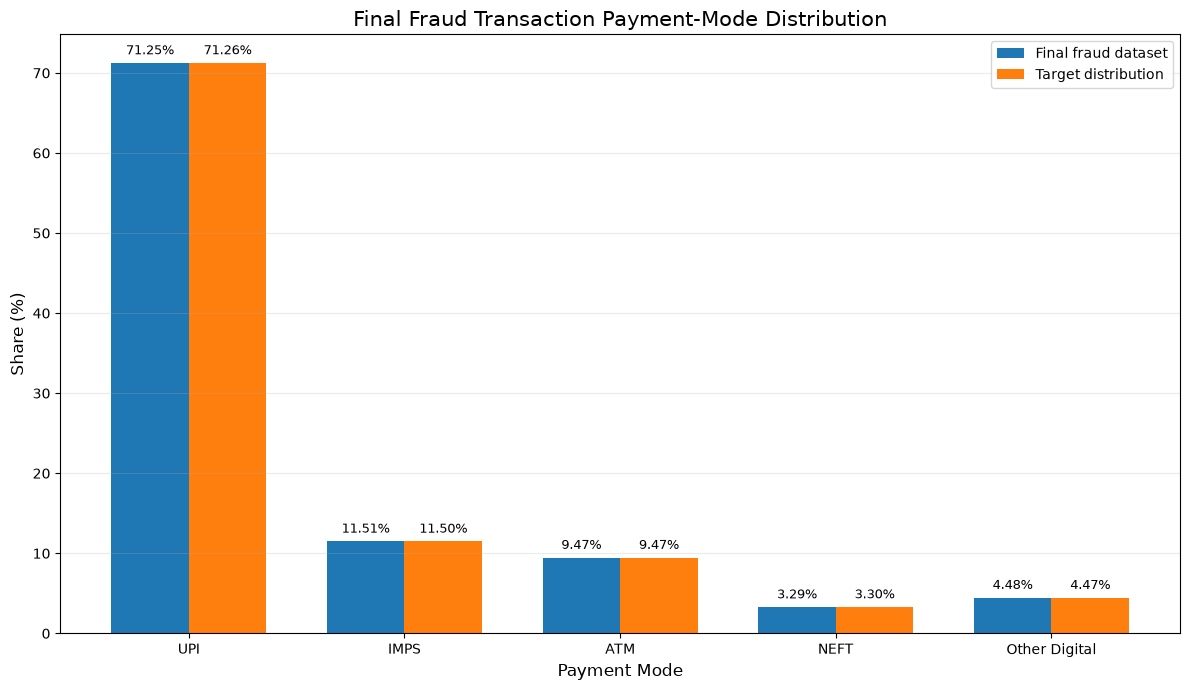

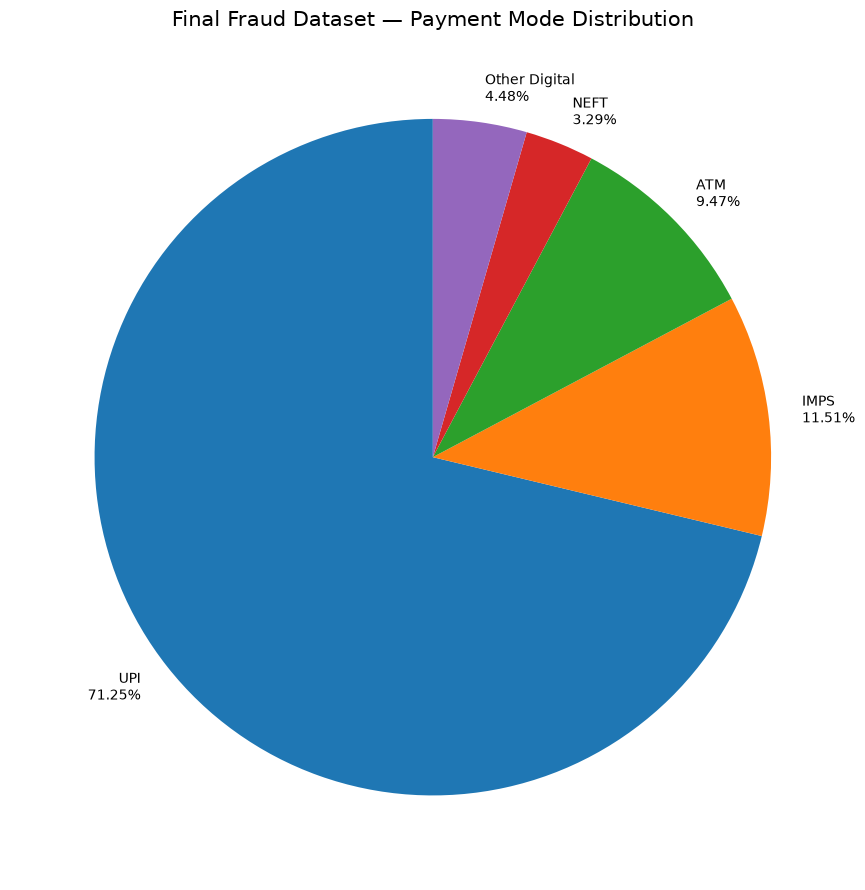


FINAL SUMMARY


,payment_mode,count_before_remapping,share_before_remapping,target_count,target_share,final_count,final_share,difference_from_target
0,UPI,754,0.1395,3852,0.7126,3852,0.7125,-0.0001
1,IMPS,4287,0.7930,622,0.1150,622,0.1151,0.0001
2,ATM,127,0.0235,512,0.0947,512,0.0947,0.0000
3,NEFT,0,0.0000,178,0.0330,178,0.0329,-0.0001
4,Other Digital,238,0.0440,242,0.0447,242,0.0448,0.0001



FILES GENERATED
✓ new_frauds.csv
✓ final_payment_mode_distribution.csv

Processing complete.


In [4]:
# ============================================================
# SIH 2026 - FINAL FRAUD DATASET GENERATION
# ============================================================
#
# INPUT:
#   new_fraud_expanded_2.csv
#   still_unpatterned_fraud.csv
#
# OUTPUT:
#   new_frauds.csv
#   final_payment_mode_distribution.csv
#
# PROCESS:
#   1. Load expanded fraud dataset
#   2. Remove still-unpatterned fraud transactions
#   3. Canonicalize payment modes
#   4. Redistribute excess IMPS transactions
#   5. Validate final distribution
#   6. Visualize final payment-mode distribution
#
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------
# 1. CONFIGURATION
# ------------------------------------------------------------

EXPANDED_FILE = "new_fraud_expanded_2.csv"
UNPATTERNED_FILE = "still_unpatterned_fraud.csv"

OUTPUT_FILE = "new_frauds.csv"
DISTRIBUTION_FILE = "final_payment_mode_distribution.csv"

RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)

# Target distribution requested
TARGET_DISTRIBUTION = {
    "UPI": 0.7126,
    "IMPS": 0.1150,
    "ATM": 0.0947,
    "NEFT": 0.0330,
    "Other Digital": 0.0447
}

# ------------------------------------------------------------
# 2. CHECK FILES
# ------------------------------------------------------------

print("=" * 70)
print("CHECKING INPUT FILES")
print("=" * 70)

if not Path(EXPANDED_FILE).exists():
    raise FileNotFoundError(
        f"Could not find {EXPANDED_FILE}. "
        "Upload it to the Colab working directory."
    )

if not Path(UNPATTERNED_FILE).exists():
    raise FileNotFoundError(
        f"Could not find {UNPATTERNED_FILE}. "
        "Upload it to the Colab working directory."
    )

print(f"✓ Found: {EXPANDED_FILE}")
print(f"✓ Found: {UNPATTERNED_FILE}")


# ------------------------------------------------------------
# 3. LOAD DATA
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("LOADING DATA")
print("=" * 70)

fraud = pd.read_csv(EXPANDED_FILE)
unpatterned = pd.read_csv(UNPATTERNED_FILE)

print(f"Expanded fraud transactions : {len(fraud):,}")
print(f"Unpatterned transactions    : {len(unpatterned):,}")

print("\nExpanded columns:")
print(fraud.columns.tolist())

print("\nUnpatterned columns:")
print(unpatterned.columns.tolist())


# ------------------------------------------------------------
# 4. CLEAN COLUMN NAMES
# ------------------------------------------------------------

fraud.columns = (
    fraud.columns
    .str.strip()
    .str.replace("**", "", regex=False)
)

unpatterned.columns = (
    unpatterned.columns
    .str.strip()
    .str.replace("**", "", regex=False)
)

print("\nCleaned columns:")
print(fraud.columns.tolist())


# ------------------------------------------------------------
# 5. IDENTIFY TRANSACTION ID COLUMN
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("IDENTIFYING TRANSACTION ID")
print("=" * 70)

# new_fraud_expanded_2 does not have transaction_id according
# to the supplied schema.
#
# Therefore, original_transaction_id is the safest common
# identifier between the two datasets.

if "original_transaction_id" not in fraud.columns:
    raise ValueError(
        "new_fraud_expanded_2.csv does not contain "
        "'original_transaction_id'. Cannot safely remove "
        "the unpatterned transactions."
    )

if "original_transaction_id" not in unpatterned.columns:
    raise ValueError(
        "still_unpatterned_fraud.csv does not contain "
        "'original_transaction_id'."
    )

print("Using: original_transaction_id")


# ------------------------------------------------------------
# 6. NORMALIZE IDS
# ------------------------------------------------------------

def normalize_id(x):
    """
    Prevent problems such as:
        787
        787.0
        '787'
    being treated as different IDs.
    """

    if pd.isna(x):
        return None

    s = str(x).strip()

    # Convert values such as 787.0 -> 787
    try:
        f = float(s)

        if f.is_integer():
            return str(int(f))
    except:
        pass

    return s


fraud["_match_original_id"] = (
    fraud["original_transaction_id"]
    .apply(normalize_id)
)

unpatterned["_match_original_id"] = (
    unpatterned["original_transaction_id"]
    .apply(normalize_id)
)


# ------------------------------------------------------------
# 7. FIND UNPATTERNED TRANSACTIONS
# ------------------------------------------------------------

unpatterned_ids = set(
    unpatterned["_match_original_id"]
    .dropna()
)

print(f"\nUnique unpatterned IDs: {len(unpatterned_ids):,}")


# Check how many expanded transactions match
matched_mask = fraud["_match_original_id"].isin(unpatterned_ids)

matched_count = matched_mask.sum()

print(
    f"Transactions in expanded dataset "
    f"matching unpatterned IDs: {matched_count:,}"
)


# ------------------------------------------------------------
# 8. REMOVE UNPATTERNED FRAUDS
# ------------------------------------------------------------

fraud_clean = fraud.loc[
    ~matched_mask
].copy()

print("\n" + "=" * 70)
print("REMOVING UNPATTERNED FRAUDS")
print("=" * 70)

print(f"Before removal : {len(fraud):,}")
print(f"Removed        : {matched_count:,}")
print(f"After removal  : {len(fraud_clean):,}")


# ------------------------------------------------------------
# 9. VALIDATION - NO UNPATTERNED IDS SHOULD REMAIN
# ------------------------------------------------------------

remaining_unpatterned_matches = fraud_clean[
    fraud_clean["_match_original_id"].isin(unpatterned_ids)
]

print(
    f"\nRemaining unpatterned matches: "
    f"{len(remaining_unpatterned_matches):,}"
)

if len(remaining_unpatterned_matches) != 0:
    raise RuntimeError(
        "Some unpatterned transactions are still present."
    )

print("✓ All identified unpatterned transactions removed.")


# ------------------------------------------------------------
# 10. PAYMENT MODE CANONICALIZATION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("PAYMENT MODE NORMALIZATION")
print("=" * 70)

if "payment_mode" not in fraud_clean.columns:
    raise ValueError(
        "payment_mode column not found."
    )

fraud_clean["payment_mode_original"] = (
    fraud_clean["payment_mode"]
    .astype(str)
    .str.strip()
    .str.upper()
)


def canonical_payment_mode(mode):

    mode = str(mode).strip().upper()

    # ATM variants
    if (
        "ATM" in mode
        or "CASH WITHDRAWAL" in mode
        or "CASH_WITHDRAWAL" in mode
    ):
        return "ATM"

    # UPI
    if "UPI" in mode:
        return "UPI"

    # IMPS
    if "IMPS" in mode:
        return "IMPS"

    # NEFT
    if "NEFT" in mode:
        return "NEFT"

    # Everything else
    return "Other Digital"


fraud_clean["payment_mode"] = (
    fraud_clean["payment_mode_original"]
    .apply(canonical_payment_mode)
)


print("\nOriginal payment modes:")
print(
    fraud_clean["payment_mode_original"]
    .value_counts()
)

print("\nCanonical payment modes:")
print(
    fraud_clean["payment_mode"]
    .value_counts()
)


# ------------------------------------------------------------
# 11. CALCULATE CURRENT DISTRIBUTION
# ------------------------------------------------------------

total_transactions = len(fraud_clean)

current_counts = (
    fraud_clean["payment_mode"]
    .value_counts()
)

modes = list(TARGET_DISTRIBUTION.keys())

current_counts_complete = {
    mode: int(current_counts.get(mode, 0))
    for mode in modes
}

current_distribution = {
    mode: current_counts_complete[mode] / total_transactions
    for mode in modes
}

print("\n" + "=" * 70)
print("CURRENT DISTRIBUTION AFTER REMOVING UNPATTERNED")
print("=" * 70)

for mode in modes:
    print(
        f"{mode:<15} "
        f"{current_counts_complete[mode]:>8,} "
        f"({current_distribution[mode] * 100:>7.2f}%) "
        f"Target: {TARGET_DISTRIBUTION[mode] * 100:>7.2f}%"
    )


# ------------------------------------------------------------
# 12. DETERMINE TARGET COUNTS
# ------------------------------------------------------------

# Because transactions are discrete, exact percentages are
# usually impossible.
#
# We use the largest-remainder method so that the target
# integer counts sum exactly to the total number of transactions.

raw_target_counts = {
    mode: TARGET_DISTRIBUTION[mode] * total_transactions
    for mode in modes
}

target_counts = {
    mode: int(np.floor(raw_target_counts[mode]))
    for mode in modes
}

remaining_slots = (
    total_transactions -
    sum(target_counts.values())
)

remainders = sorted(
    modes,
    key=lambda m: raw_target_counts[m] - target_counts[m],
    reverse=True
)

for mode in remainders[:remaining_slots]:
    target_counts[mode] += 1


print("\n" + "=" * 70)
print("INTEGER TARGET COUNTS")
print("=" * 70)

for mode in modes:
    print(
        f"{mode:<15} "
        f"{target_counts[mode]:>8,} "
        f"({target_counts[mode] / total_transactions * 100:>7.2f}%)"
    )

print(
    f"\nTotal target transactions: "
    f"{sum(target_counts.values()):,}"
)


# ------------------------------------------------------------
# 13. CALCULATE SURPLUS / DEFICIT
# ------------------------------------------------------------

surplus = {}
deficit = {}

for mode in modes:

    difference = (
        current_counts_complete[mode]
        - target_counts[mode]
    )

    if difference > 0:
        surplus[mode] = difference
    elif difference < 0:
        deficit[mode] = -difference


print("\n" + "=" * 70)
print("SURPLUS / DEFICIT")
print("=" * 70)

print("\nSurplus:")
if surplus:
    for mode, count in surplus.items():
        print(f"  {mode:<15}: +{count:,}")
else:
    print("  None")

print("\nDeficit:")
if deficit:
    for mode, count in deficit.items():
        print(f"  {mode:<15}: -{count:,}")
else:
    print("  None")


# ------------------------------------------------------------
# 14. REMAP EXCESS IMPS
# ------------------------------------------------------------
#
# IMPORTANT:
#
# We don't randomly modify all payment modes.
#
# We preferentially use EXCESS IMPS transactions.
#
# Example:
#
# Current:
#   UPI   60%
#   IMPS  25%
#   ATM   10%
#   NEFT   3%
#   Other  2%
#
# Target:
#   UPI   71.26%
#   IMPS  11.50%
#   ATM    9.47%
#   NEFT   3.30%
#   Other  4.47%
#
# We take the excess IMPS and move it primarily into
# categories with deficits.
#
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("REMAP PROCESS")
print("=" * 70)


# Work on dataframe indices
imps_indices = fraud_clean.index[
    fraud_clean["payment_mode"] == "IMPS"
].to_numpy(copy=True)

# Shuffle deterministically
rng = np.random.default_rng(RANDOM_SEED)
rng.shuffle(imps_indices)


# We want IMPS to end at target count.
current_imps = current_counts_complete["IMPS"]
target_imps = target_counts["IMPS"]

imps_to_remap = max(
    0,
    current_imps - target_imps
)

print(f"Current IMPS : {current_imps:,}")
print(f"Target IMPS  : {target_imps:,}")
print(f"IMPS to remap: {imps_to_remap:,}")


if imps_to_remap > len(imps_indices):
    raise RuntimeError(
        "Not enough IMPS transactions available "
        "for the required remapping."
    )


# Only modes below target receive remapped transactions.
destination_modes = []

for mode in modes:

    if mode == "IMPS":
        continue

    deficit_count = max(
        0,
        target_counts[mode]
        - current_counts_complete[mode]
    )

    if deficit_count > 0:
        destination_modes.append(
            (mode, deficit_count)
        )


print("\nDestination deficits:")

for mode, count in destination_modes:
    print(f"  {mode:<15}: {count:,}")


# ------------------------------------------------------------
# 15. DISTRIBUTE EXCESS IMPS INTO DEFICITS
# ------------------------------------------------------------

remap_plan = []

remaining_imps = imps_to_remap

for mode, deficit_count in destination_modes:

    amount = min(
        remaining_imps,
        deficit_count
    )

    if amount > 0:
        remap_plan.append(
            (mode, amount)
        )

        remaining_imps -= amount

    if remaining_imps == 0:
        break


# If excess IMPS still remains after filling deficits,
# the target distribution cannot be achieved by changing
# IMPS alone.
#
# In that situation, we do NOT silently alter UPI/ATM/NEFT.
#
# We report the issue.

if remaining_imps > 0:

    print(
        "\nWARNING:"
        "\nThere are more excess IMPS transactions than "
        "the deficits in the other modes."
    )

    print(
        f"Unallocated IMPS remaps: {remaining_imps:,}"
    )

    print(
        "\nThe program will remap only what is necessary "
        "to fill existing deficits."
    )


print("\nRemapping plan:")

for mode, count in remap_plan:
    print(
        f"  IMPS -> {mode:<15}: {count:,}"
    )


# ------------------------------------------------------------
# 16. APPLY REMAPPING
# ------------------------------------------------------------

cursor = 0

remap_records = []

for destination_mode, count in remap_plan:

    selected_indices = imps_indices[
        cursor:cursor + count
    ]

    for idx in selected_indices:

        old_mode = fraud_clean.at[
            idx,
            "payment_mode"
        ]

        fraud_clean.at[
            idx,
            "payment_mode"
        ] = destination_mode

        remap_records.append({
            "index": idx,
            "old_payment_mode": old_mode,
            "new_payment_mode": destination_mode
        })

    cursor += count


remap_df = pd.DataFrame(remap_records)


print(
    f"\nTotal transactions remapped: "
    f"{len(remap_df):,}"
)


# ------------------------------------------------------------
# 17. ADD REMAPPING METADATA
# ------------------------------------------------------------

# This is useful for auditability.
#
# We preserve the original payment mode in
# payment_mode_original.
#
# Therefore we can always prove that an IMPS transaction
# was synthetically remapped.

remap_lookup = dict(
    zip(
        remap_df["index"],
        remap_df["new_payment_mode"]
    )
)

fraud_clean["payment_mode_remapped"] = False

for idx in remap_lookup:
    fraud_clean.at[
        idx,
        "payment_mode_remapped"
    ] = True


# ------------------------------------------------------------
# 18. FINAL DISTRIBUTION
# ------------------------------------------------------------

final_counts = (
    fraud_clean["payment_mode"]
    .value_counts()
)

final_counts_complete = {
    mode: int(final_counts.get(mode, 0))
    for mode in modes
}

final_distribution = {
    mode:
    final_counts_complete[mode] / total_transactions
    for mode in modes
}


print("\n" + "=" * 70)
print("FINAL PAYMENT MODE DISTRIBUTION")
print("=" * 70)

for mode in modes:

    final_pct = (
        final_distribution[mode] * 100
    )

    target_pct = (
        TARGET_DISTRIBUTION[mode] * 100
    )

    difference = final_pct - target_pct

    print(
        f"{mode:<15} "
        f"{final_counts_complete[mode]:>8,} "
        f"{final_pct:>7.2f}% "
        f"Target: {target_pct:>7.2f}% "
        f"Diff: {difference:+7.2f}%"
    )


# ------------------------------------------------------------
# 19. CREATE DISTRIBUTION SUMMARY
# ------------------------------------------------------------

distribution_rows = []

for mode in modes:

    distribution_rows.append({
        "payment_mode": mode,

        "count_before_remapping":
            current_counts_complete[mode],

        "share_before_remapping":
            current_distribution[mode],

        "target_count":
            target_counts[mode],

        "target_share":
            TARGET_DISTRIBUTION[mode],

        "final_count":
            final_counts_complete[mode],

        "final_share":
            final_distribution[mode],

        "difference_from_target":
            final_distribution[mode]
            - TARGET_DISTRIBUTION[mode]
    })


distribution_df = pd.DataFrame(
    distribution_rows
)


# ------------------------------------------------------------
# 20. SAVE DISTRIBUTION SUMMARY
# ------------------------------------------------------------

distribution_df.to_csv(
    DISTRIBUTION_FILE,
    index=False
)

print(
    f"\n✓ Saved distribution summary: "
    f"{DISTRIBUTION_FILE}"
)


# ------------------------------------------------------------
# 21. REMOVE INTERNAL MATCHING COLUMN
# ------------------------------------------------------------

fraud_clean.drop(
    columns=["_match_original_id"],
    inplace=True,
    errors="ignore"
)


# ------------------------------------------------------------
# 22. SAVE FINAL FRAUD DATASET
# ------------------------------------------------------------

fraud_clean.to_csv(
    OUTPUT_FILE,
    index=False
)

print(
    f"✓ Saved final dataset: "
    f"{OUTPUT_FILE}"
)


# ------------------------------------------------------------
# 23. FINAL DATASET VALIDATION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL DATASET VALIDATION")
print("=" * 70)

final_df = pd.read_csv(
    OUTPUT_FILE
)

print(
    f"Final transaction count: "
    f"{len(final_df):,}"
)

print(
    f"Final columns: "
    f"{len(final_df.columns)}"
)

print(
    f"Missing payment modes: "
    f"{final_df['payment_mode'].isna().sum():,}"
)

print("\nFinal mode counts:")
print(
    final_df["payment_mode"]
    .value_counts()
)


# ------------------------------------------------------------
# 24. CHECK UNPATTERNED IDS AGAIN
# ------------------------------------------------------------

final_df["_check_id"] = (
    final_df["original_transaction_id"]
    .apply(normalize_id)
)

remaining_bad = final_df[
    final_df["_check_id"].isin(unpatterned_ids)
]

print(
    f"\nUnpatterned transactions remaining: "
    f"{len(remaining_bad):,}"
)

if len(remaining_bad) == 0:
    print("✓ No identified unpatterned transactions remain.")
else:
    print(
        "WARNING: Some unpatterned IDs are still present."
    )

final_df.drop(
    columns=["_check_id"],
    inplace=True
)


# ------------------------------------------------------------
# 25. VERIFY TARGET MODES ONLY
# ------------------------------------------------------------

unexpected_modes = set(
    final_df["payment_mode"].unique()
) - set(modes)

print(
    f"\nUnexpected payment modes: "
    f"{unexpected_modes}"
)

if len(unexpected_modes) == 0:
    print("✓ All payment modes belong to the required categories.")
else:
    print(
        "WARNING: Unexpected payment modes found."
    )


# ------------------------------------------------------------
# 26. VISUALIZATION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL PAYMENT MODE VISUALIZATION")
print("=" * 70)

plot_df = distribution_df.copy()

x = np.arange(len(modes))
width = 0.36

fig, ax = plt.subplots(
    figsize=(12, 7)
)

bars1 = ax.bar(
    x - width / 2,
    plot_df["final_share"] * 100,
    width,
    label="Final fraud dataset"
)

bars2 = ax.bar(
    x + width / 2,
    plot_df["target_share"] * 100,
    width,
    label="Target distribution"
)

ax.set_xlabel(
    "Payment Mode",
    fontsize=12
)

ax.set_ylabel(
    "Share (%)",
    fontsize=12
)

ax.set_title(
    "Final Fraud Transaction Payment-Mode Distribution",
    fontsize=15
)

ax.set_xticks(x)
ax.set_xticklabels(modes)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.25
)

# Add percentage labels
for bars in [bars1, bars2]:

    for bar in bars:

        height = bar.get_height()

        ax.text(
            bar.get_x()
            + bar.get_width() / 2,
            height + 0.7,
            f"{height:.2f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 27. FINAL PIE CHART
# ------------------------------------------------------------

plt.figure(
    figsize=(9, 9)
)

plt.pie(
    plot_df["final_share"] * 100,
    labels=[
        f"{m}\n"
        f"{plot_df.loc[plot_df['payment_mode'] == m, 'final_share'].iloc[0] * 100:.2f}%"
        for m in modes
    ],
    autopct=None,
    startangle=90
)

plt.title(
    "Final Fraud Dataset — Payment Mode Distribution",
    fontsize=15
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 28. PRINT FINAL SUMMARY TABLE
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL SUMMARY")
print("=" * 70)

display(
    distribution_df[
        [
            "payment_mode",
            "count_before_remapping",
            "share_before_remapping",
            "target_count",
            "target_share",
            "final_count",
            "final_share",
            "difference_from_target"
        ]
    ].round({
        "share_before_remapping": 4,
        "target_share": 4,
        "final_share": 4,
        "difference_from_target": 4
    })
)

print("\n" + "=" * 70)
print("FILES GENERATED")
print("=" * 70)

print(f"✓ {OUTPUT_FILE}")
print(f"✓ {DISTRIBUTION_FILE}")

print("\nProcessing complete.")

In [6]:
# ============================================================
# EXCLUSIVE UNKNOWN PATTERN DISCOVERY
# ============================================================
#
# IMPORTANT:
# A transaction can belong to ONLY ONE discovered pattern.
#
# Algorithm:
#
#   1. Sort fraud transactions chronologically
#   2. Pick earliest unused transaction
#   3. Try to construct a pattern starting from that transaction
#   4. If pattern found:
#        - save pattern
#        - mark ALL its transactions as used
#   5. If no pattern found:
#        - mark seed as processed/unpatterned
#   6. Move to next unused transaction
#
# ============================================================

import pandas as pd
import numpy as np
from collections import defaultdict
from pathlib import Path

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------

# INPUT_FILE = "remaining_fraud_transactions.csv"
INPUT_FILE = "new_frauds.csv"

OUTPUT_FILE = "unknown_patterns.txt"
SUMMARY_FILE = "unknown_pattern_summary.csv"
UNPATTERNED_FILE = "still_unpatterned_fraud.csv"

# Temporal constraints
FAN_WINDOW_MINUTES = 1200
CHAIN_WINDOW_MINUTES = 1200

# Structural constraints
MIN_FAN_DEGREE = 2

MIN_CHAIN_LENGTH = 2
MAX_CHAIN_LENGTH = 500

# Amount similarity for chaining
AMOUNT_TOLERANCE = 50.0


# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------

df = pd.read_csv(INPUT_FILE)

print("=" * 80)
print("LOADING FRAUD TRANSACTIONS")
print("=" * 80)

print(f"Input transactions: {len(df):,}")

# ------------------------------------------------------------
# NORMALIZE
# ------------------------------------------------------------

df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    errors="coerce"
)

df["from_account"] = (
    df["from_account"]
    .astype(str)
    .str.strip()
)

df["to_account"] = (
    df["to_account"]
    .astype(str)
    .str.strip()
)

df["amount_paid"] = pd.to_numeric(
    df["amount_paid"],
    errors="coerce"
)

df["payment_mode"] = (
    df["payment_mode"]
    .astype(str)
    .str.strip()
)

df["from_district"] = (
    df["from_district"]
    .astype(str)
    .str.strip()
)

df["to_district"] = (
    df["to_district"]
    .astype(str)
    .str.strip()
)

df["from_indian_bank"] = (
    df["from_indian_bank"]
    .astype(str)
    .str.strip()
)

df["to_indian_bank"] = (
    df["to_indian_bank"]
    .astype(str)
    .str.strip()
)

df = df.dropna(
    subset=[
        "timestamp",
        "from_account",
        "to_account",
        "amount_paid"
    ]
).copy()

# ------------------------------------------------------------
# UNIQUE TRANSACTION ID
# ------------------------------------------------------------

df = df.reset_index(drop=True)

df["transaction_id"] = df.index

# Chronological order
df = df.sort_values(
    "timestamp"
).reset_index(drop=True)

print(f"Valid transactions: {len(df):,}")


# ------------------------------------------------------------
# TRANSACTION FORMATTER
# ------------------------------------------------------------

def format_transaction(row):

    return ",".join([
        row["timestamp"].strftime("%Y/%m/%d %H:%M"),
        str(row["from_indian_bank"]),
        str(row["from_account"]),
        str(row["to_indian_bank"]),
        str(row["to_account"]),
        f'{row["amount_paid"]:.2f}',
        str(row["payment_mode"]),
        str(row["is_laundering"]),
        str(row["from_district"]),
        str(row["to_district"])
    ])


# ------------------------------------------------------------
# AMOUNT COMPATIBILITY
# ------------------------------------------------------------

def amount_compatible(a, b):

    if a <= 0 or b <= 0:
        return True

    ratio = b / a

    return (
        1 - AMOUNT_TOLERANCE
        <= ratio
        <=
        1 + AMOUNT_TOLERANCE
    )


# ------------------------------------------------------------
# BUILD INDEXES
# ------------------------------------------------------------

outgoing = defaultdict(list)
incoming = defaultdict(list)

for idx, row in df.iterrows():

    outgoing[
        row["from_account"]
    ].append(idx)

    incoming[
        row["to_account"]
    ].append(idx)


# ------------------------------------------------------------
# IMPORTANT:
# USED TRANSACTION SET
# ------------------------------------------------------------

used_transactions = set()

# Transactions that were examined but didn't form a pattern
unpatterned_transactions = set()

# Final discovered patterns
discovered_patterns = []


# ============================================================
# PATTERN DETECTORS
# ============================================================

# Each detector receives:
#
#   seed_idx
#   available transactions
#
# and returns:
#
#   {
#       "type": ...,
#       "description": ...,
#       "transactions": [...]
#   }
#
# OR None
#
# The detectors ONLY use transactions that are currently
# unused.
# ============================================================


# ------------------------------------------------------------
# 1. FAN-IN
# ------------------------------------------------------------

def find_fan_in(seed_idx, available):

    seed = df.loc[seed_idx]

    target = seed["to_account"]

    # All currently available incoming transactions
    candidates = [
        i for i in incoming.get(target, [])
        if i in available
    ]

    if len(candidates) < MIN_FAN_DEGREE:
        return None

    seed_time = seed["timestamp"]

    valid = []

    for idx in candidates:

        row = df.loc[idx]

        delta = (
            row["timestamp"] - seed_time
        ).total_seconds() / 60

        if abs(delta) <= FAN_WINDOW_MINUTES:

            valid.append(idx)

    # Distinct source accounts
    source_accounts = set(
        df.loc[
            valid,
            "from_account"
        ]
    )

    if len(source_accounts) < MIN_FAN_DEGREE:
        return None

    # Keep chronological transactions
    valid = sorted(
        valid,
        key=lambda i: df.loc[
            i,
            "timestamp"
        ]
    )

    return {
        "type": "FAN-IN",
        "description": (
            f"{len(source_accounts)}-degree Fan-In "
            f"to {target}"
        ),
        "transactions": valid
    }


# ------------------------------------------------------------
# 2. FAN-OUT
# ------------------------------------------------------------

def find_fan_out(seed_idx, available):

    seed = df.loc[seed_idx]

    source = seed["from_account"]

    candidates = [
        i for i in outgoing.get(source, [])
        if i in available
    ]

    if len(candidates) < MIN_FAN_DEGREE:
        return None

    seed_time = seed["timestamp"]

    valid = []

    for idx in candidates:

        row = df.loc[idx]

        delta = (
            row["timestamp"] - seed_time
        ).total_seconds() / 60

        if abs(delta) <= FAN_WINDOW_MINUTES:

            valid.append(idx)

    destination_accounts = set(
        df.loc[
            valid,
            "to_account"
        ]
    )

    if len(destination_accounts) < MIN_FAN_DEGREE:
        return None

    valid = sorted(
        valid,
        key=lambda i: df.loc[
            i,
            "timestamp"
        ]
    )

    return {
        "type": "FAN-OUT",
        "description": (
            f"{len(destination_accounts)}-degree Fan-Out "
            f"from {source}"
        ),
        "transactions": valid
    }


# ------------------------------------------------------------
# 3. GATHER-SCATTER
#
# many -> HUB -> many
# ------------------------------------------------------------

def find_gather_scatter(seed_idx, available):

    seed = df.loc[seed_idx]

    hub = seed["to_account"]

    # Incoming
    in_candidates = [
        i for i in incoming.get(hub, [])
        if i in available
    ]

    if len(in_candidates) < MIN_FAN_DEGREE:
        return None

    seed_time = seed["timestamp"]

    incoming_valid = [
        i for i in in_candidates
        if abs(
            (
                df.loc[i, "timestamp"]
                - seed_time
            ).total_seconds() / 60
        ) <= CHAIN_WINDOW_MINUTES
    ]

    source_accounts = set(
        df.loc[
            incoming_valid,
            "from_account"
        ]
    )

    if len(source_accounts) < MIN_FAN_DEGREE:
        return None

    # Outgoing must happen after incoming
    latest_incoming = max(
        df.loc[
            incoming_valid,
            "timestamp"
        ]
    )

    out_candidates = [
        i for i in outgoing.get(hub, [])
        if i in available
    ]

    outgoing_valid = [
        i for i in out_candidates
        if (
            df.loc[i, "timestamp"] >= latest_incoming
            and
            (
                df.loc[i, "timestamp"]
                - latest_incoming
            ).total_seconds() / 60
            <= CHAIN_WINDOW_MINUTES
        )
    ]

    destination_accounts = set(
        df.loc[
            outgoing_valid,
            "to_account"
        ]
    )

    if len(destination_accounts) < MIN_FAN_DEGREE:
        return None

    transactions = sorted(
        incoming_valid + outgoing_valid,
        key=lambda i: df.loc[
            i,
            "timestamp"
        ]
    )

    return {
        "type": "GATHER-SCATTER",
        "description": (
            f"Gather-Scatter: "
            f"{len(source_accounts)} sources -> "
            f"{hub} -> "
            f"{len(destination_accounts)} destinations"
        ),
        "transactions": transactions
    }


# ------------------------------------------------------------
# 4. SCATTER-GATHER
#
# source -> many intermediates -> destination
# ------------------------------------------------------------

def find_scatter_gather(seed_idx, available):

    seed = df.loc[seed_idx]

    source = seed["from_account"]

    first_hops = [
        i for i in outgoing.get(source, [])
        if i in available
    ]

    seed_time = seed["timestamp"]

    first_hops = [
        i for i in first_hops
        if abs(
            (
                df.loc[i, "timestamp"]
                - seed_time
            ).total_seconds() / 60
        ) <= CHAIN_WINDOW_MINUTES
    ]

    intermediates = set(
        df.loc[
            first_hops,
            "to_account"
        ]
    )

    if len(intermediates) < MIN_FAN_DEGREE:
        return None

    # Find common destination
    destination_map = defaultdict(list)

    for intermediary in intermediates:

        for idx in outgoing.get(
            intermediary,
            []
        ):

            if idx not in available:
                continue

            row = df.loc[idx]

            if row["timestamp"] < seed_time:
                continue

            if (
                row["timestamp"]
                - seed_time
            ).total_seconds() / 60 > CHAIN_WINDOW_MINUTES:
                break

            destination_map[
                row["to_account"]
            ].append(idx)

    best_destination = None
    best_transactions = []

    for destination, indices in destination_map.items():

        sending_intermediates = set(
            df.loc[
                indices,
                "from_account"
            ]
        )

        if len(sending_intermediates) >= MIN_FAN_DEGREE:

            if len(indices) > len(best_transactions):

                best_destination = destination
                best_transactions = indices

    if best_destination is None:
        return None

    transactions = sorted(
        first_hops + best_transactions,
        key=lambda i: df.loc[
            i,
            "timestamp"
        ]
    )

    return {
        "type": "SCATTER-GATHER",
        "description": (
            f"Scatter-Gather: "
            f"{source} -> "
            f"{len(intermediates)} intermediates -> "
            f"{best_destination}"
        ),
        "transactions": transactions
    }


# ------------------------------------------------------------
# 5. MULTI-HOP CHAIN
#
# A -> B -> C -> D
# ------------------------------------------------------------

def find_chain(seed_idx, available):

    seed = df.loc[seed_idx]

    chain = [seed_idx]

    visited = {
        seed["from_account"],
        seed["to_account"]
    }

    current_idx = seed_idx

    while len(chain) < MAX_CHAIN_LENGTH:

        current = df.loc[current_idx]

        next_account = current["to_account"]

        candidates = [
            i for i in outgoing.get(
                next_account,
                []
            )
            if i in available
        ]

        candidates = [
            i for i in candidates
            if i not in chain
        ]

        best = None

        for idx in candidates:

            row = df.loc[idx]

            if row["timestamp"] <= current["timestamp"]:
                continue

            delta = (
                row["timestamp"]
                - current["timestamp"]
            ).total_seconds() / 60

            if delta > CHAIN_WINDOW_MINUTES:
                break

            if row["to_account"] in visited:
                continue

            if not amount_compatible(
                current["amount_paid"],
                row["amount_paid"]
            ):
                continue

            best = idx
            break

        if best is None:
            break

        chain.append(best)

        visited.add(
            df.loc[
                best,
                "to_account"
            ]
        )

        current_idx = best

    if len(chain) < MIN_CHAIN_LENGTH:
        return None

    accounts = [
        df.loc[
            chain[0],
            "from_account"
        ]
    ]

    for idx in chain:

        accounts.append(
            df.loc[
                idx,
                "to_account"
            ]
        )

    return {
        "type": "MULTI-HOP CHAIN",
        "description": (
            f"{len(chain)}-transaction chain: "
            f"{' -> '.join(accounts)}"
        ),
        "transactions": chain
    }


# ------------------------------------------------------------
# 6. CYCLE
#
# A -> B -> C -> A
# ------------------------------------------------------------

def find_cycle(seed_idx, available):

    seed = df.loc[seed_idx]

    start = seed["from_account"]

    current_account = seed["to_account"]

    cycle = [seed_idx]

    visited = {
        start,
        current_account
    }

    current_time = seed["timestamp"]

    while len(cycle) < 5:

        candidates = [
            i for i in outgoing.get(
                current_account,
                []
            )
            if i in available
        ]

        next_idx = None

        for idx in candidates:

            row = df.loc[idx]

            if row["timestamp"] <= current_time:
                continue

            delta = (
                row["timestamp"]
                - current_time
            ).total_seconds() / 60

            if delta > CHAIN_WINDOW_MINUTES:
                break

            destination = row["to_account"]

            # Closing cycle
            if destination == start:

                if len(cycle) >= 2:

                    cycle.append(idx)

                    return {
                        "type": "CYCLE",
                        "description": (
                            f"Cycle detected returning to "
                            f"{start}"
                        ),
                        "transactions": cycle
                    }

            if destination in visited:
                continue

            next_idx = idx
            break

        if next_idx is None:
            break

        cycle.append(next_idx)

        current_account = df.loc[
            next_idx,
            "to_account"
        ]

        current_time = df.loc[
            next_idx,
            "timestamp"
        ]

        visited.add(
            current_account
        )

    return None


# ============================================================
# PATTERN PRIORITY
# ============================================================
#
# More specific structures first.
#
# This is important.
#
# Example:
#
# A -> B
# A -> C
# A -> D
# D -> X
#
# Could be interpreted as Fan-Out OR a more complex structure.
#
# We prefer the more informative structure.
# ============================================================

PATTERN_DETECTORS = [
    ("GATHER-SCATTER", find_gather_scatter),
    ("SCATTER-GATHER", find_scatter_gather),
    ("CYCLE", find_cycle),
    ("FAN-IN", find_fan_in),
    ("FAN-OUT", find_fan_out),
    ("MULTI-HOP CHAIN", find_chain),
]


# ============================================================
# MAIN EXCLUSIVE DISCOVERY LOOP
# ============================================================

print("\n")
print("=" * 80)
print("STARTING EXCLUSIVE PATTERN DISCOVERY")
print("=" * 80)

total = len(df)

for seed_idx in range(total):

    # Already consumed by a previous pattern
    if seed_idx in used_transactions:
        continue

    # Already checked and found nothing
    if seed_idx in unpatterned_transactions:
        continue

    available = set(
        range(total)
    ) - used_transactions

    found_pattern = None

    # --------------------------------------------------------
    # Try every pattern against THIS seed
    # --------------------------------------------------------

    for pattern_name, detector in PATTERN_DETECTORS:

        result = detector(
            seed_idx,
            available
        )

        if result is None:
            continue

        # ----------------------------------------------------
        # Make sure the pattern really contains the seed
        # ----------------------------------------------------

        if seed_idx not in result["transactions"]:
            continue

        # ----------------------------------------------------
        # Safety:
        # no transaction may already be consumed
        # ----------------------------------------------------

        if any(
            idx in used_transactions
            for idx in result["transactions"]
        ):
            continue

        found_pattern = result

        break

    # --------------------------------------------------------
    # Pattern found
    # --------------------------------------------------------

    if found_pattern is not None:

        transactions = found_pattern[
            "transactions"
        ]

        used_transactions.update(
            transactions
        )

        discovered_patterns.append(
            found_pattern
        )

        print(
            f"[PATTERN #{len(discovered_patterns):04d}] "
            f"{found_pattern['type']:18s} | "
            f"{len(transactions):2d} transactions | "
            f"{found_pattern['description']}"
        )

    # --------------------------------------------------------
    # No pattern found
    # --------------------------------------------------------

    else:

        unpatterned_transactions.add(
            seed_idx
        )


# ============================================================
# WRITE UNKNOWN PATTERNS
# ============================================================

print("\n")
print("=" * 80)
print("WRITING unknown_patterns.txt")
print("=" * 80)

with open(
    OUTPUT_FILE,
    "w",
    encoding="utf-8"
) as f:

    for number, pattern in enumerate(
        discovered_patterns,
        start=1
    ):

        pattern_type = pattern["type"]
        description = pattern["description"]

        f.write(
            f"BEGIN LAUNDERING ATTEMPT - "
            f"{pattern_type}: {description}\n"
        )

        rows = df.loc[
            pattern["transactions"]
        ].sort_values(
            "timestamp"
        )

        for _, row in rows.iterrows():

            f.write(
                format_transaction(row)
                + "\n"
            )

        f.write(
            f"END LAUNDERING ATTEMPT - "
            f"{pattern_type}: {description}\n\n"
        )


# ============================================================
# SUMMARY
# ============================================================

summary = []

for pattern_type in sorted(
    set(
        p["type"]
        for p in discovered_patterns
    )
):

    matching = [
        p for p in discovered_patterns
        if p["type"] == pattern_type
    ]

    transaction_ids = set()

    for p in matching:

        transaction_ids.update(
            p["transactions"]
        )

    summary.append({
        "pattern_type": pattern_type,
        "pattern_instances": len(matching),
        "transactions_used": len(
            transaction_ids
        )
    })


summary_df = pd.DataFrame(summary)

if len(summary_df) > 0:

    summary_df = summary_df.sort_values(
        "pattern_instances",
        ascending=False
    )

else:

    summary_df = pd.DataFrame(
        columns=[
            "pattern_type",
            "pattern_instances",
            "transactions_used"
        ]
    )

summary_df.to_csv(
    SUMMARY_FILE,
    index=False
)


# ============================================================
# SAVE STILL-UNPATTERNED TRANSACTIONS
# ============================================================

still_unpatterned = df.loc[
    sorted(unpatterned_transactions)
].copy()

still_unpatterned.to_csv(
    UNPATTERNED_FILE,
    index=False
)


# ============================================================
# VALIDATION
# ============================================================

patterned_count = len(
    used_transactions
)

unpatterned_count = len(
    unpatterned_transactions
)

print("\n")
print("=" * 80)
print("DISCOVERY COMPLETE")
print("=" * 80)

print(
    f"Total fraud transactions : {total:,}"
)

print(
    f"Transactions in patterns : {patterned_count:,}"
)

print(
    f"Still unpatterned         : {unpatterned_count:,}"
)

print(
    f"Discovered pattern count  : "
    f"{len(discovered_patterns):,}"
)

print(
    f"\nValidation: "
    f"{patterned_count + unpatterned_count:,} "
    f"/ {total:,}"
)

print("\nPattern summary:")
display(summary_df)

print("\nOutput files:")
print(f"  ✓ {OUTPUT_FILE}")
print(f"  ✓ {SUMMARY_FILE}")
print(f"  ✓ {UNPATTERNED_FILE}")

LOADING FRAUD TRANSACTIONS
Input transactions: 5,406
Valid transactions: 5,406


STARTING EXCLUSIVE PATTERN DISCOVERY
[PATTERN #0001] MULTI-HOP CHAIN    |  2 transactions | 2-transaction chain: 815630C40 -> 815635220 -> 8050C86F0
[PATTERN #0002] FAN-OUT            | 39 transactions | 39-degree Fan-Out from 10042B660
[PATTERN #0003] FAN-OUT            |  6 transactions | 6-degree Fan-Out from 10042B6F0
[PATTERN #0004] FAN-OUT            | 30 transactions | 30-degree Fan-Out from 10042B6A8
[PATTERN #0005] FAN-OUT            |  3 transactions | 3-degree Fan-Out from 10042B978
[PATTERN #0006] MULTI-HOP CHAIN    |  3 transactions | 3-transaction chain: 81A1C7C80 -> 81A1C7D20 -> 81B0CC0B1 -> 81B0CDAB1
[PATTERN #0007] FAN-OUT            |  3 transactions | 3-degree Fan-Out from 10042B7C8
[PATTERN #0008] FAN-OUT            |  4 transactions | 4-degree Fan-Out from 10042B9C0
[PATTERN #0009] MULTI-HOP CHAIN    |  2 transactions | 2-transaction chain: 10042B810 -> 80C8D2440 -> 8135D2770
[PATTERN 

,pattern_type,pattern_instances,transactions_used
4,MULTI-HOP CHAIN,943,4059
2,FAN-OUT,210,1139
1,FAN-IN,59,194
3,GATHER-SCATTER,2,10
0,CYCLE,1,4



Output files:
  ✓ unknown_patterns.txt
  ✓ unknown_pattern_summary.csv
  ✓ still_unpatterned_fraud.csv


In [7]:
import pandas as pd

# ============================================================
# LOAD ORIGINAL TRANSACTION FILE
# ============================================================

input_file = "new_transactions.csv"

df = pd.read_csv(input_file)

print("Original dataset:")
print("Rows:", len(df))
print("Columns:", df.columns.tolist())


# ============================================================
# NORMALIZE FRAUD FLAG
# ============================================================

# Handle True/False, 1/0, "True"/"False", etc.
df["is_laundering"] = (
    df["is_laundering"]
    .astype(str)
    .str.strip()
    .str.lower()
    .isin(["true", "1", "yes"])
)


# ============================================================
# SELECT ONLY FRAUD TRANSACTIONS
# ============================================================

fraud_df = df[df["is_laundering"] == False].copy()


# ============================================================
# SAVE
# ============================================================

output_file = "legits.csv"

fraud_df.to_csv(
    output_file,
    index=False
)


# ============================================================
# SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("FRAUD DATASET CREATED")
print("=" * 60)

print("Total transactions :", len(df))
print("Fraud transactions :", len(fraud_df))
print("Non-fraud           :", len(df) - len(fraud_df))

print("\nFraud percentage:")
print(f"{len(fraud_df) / len(df) * 100:.2f}%")

print("\nSaved as:")
print(output_file)

print("\nFirst 5 fraud transactions:")
display(fraud_df.head())

Original dataset:
Rows: 6924049
Columns: ['timestamp', 'from_account', 'to_account', 'amount_paid', 'payment_mode', 'is_laundering', 'from_district', 'to_district', 'from_indian_bank', 'to_indian_bank']

FRAUD DATASET CREATED
Total transactions : 6924049
Fraud transactions : 6920484
Non-fraud           : 3565

Fraud percentage:
99.95%

Saved as:
legits.csv

First 5 fraud transactions:


,timestamp,from_account,to_account,amount_paid,payment_mode,is_laundering,from_district,to_district,from_indian_bank,to_indian_bank
0,2022-09-01 00:08:00,8000ECA90,8000ECA90,3195403.00,UPI,False,Jagityal,Jagityal,HDFC BANK,HDFC BANK
1,2022-09-01 00:21:00,80021DAD0,80021DAD0,1858.96,UPI,False,Hyderabad Commissionerate,Hyderabad Commissionerate,HDFC BANK,HDFC BANK
2,2022-09-01 00:00:00,8000ECA90,8006AA910,592571.00,UPI,False,Jagityal,Medak,HDFC BANK,CANARA BANK
3,2022-09-01 00:16:00,8006AD080,8006AD080,12.32,UPI,False,Cyberabad Commissionerate,Cyberabad Commissionerate,UNION BANK OF INDIA,UNION BANK OF INDIA
4,2022-09-01 00:00:00,8006AD530,8006AD530,2941.56,UPI,False,Warangal Commissionerate,Warangal Commissionerate,DBS BANK INDIA (E-LVB),DBS BANK INDIA (E-LVB)


In [9]:
import pandas as pd
from pathlib import Path

# ============================================================
# CONFIGURATION
# ============================================================

LEGIT_FILE = Path("legits.csv")
FRAUD_FILE = Path("new_frauds.csv")

FINAL_FILE = Path("final_transactions.csv")
ATM_FILE = Path("atm_transactions.csv")


# ============================================================
# 1. LOAD DATASETS
# ============================================================

print("Loading datasets...")

legits = pd.read_csv(LEGIT_FILE)
frauds = pd.read_csv(FRAUD_FILE)

print(f"Legitimate transactions : {len(legits):,}")
print(f"Fraud transactions      : {len(frauds):,}")


# ============================================================
# 2. DEFINE THE REQUIRED FINAL SCHEMA
#    Exactly the same fields as legits.csv
# ============================================================

required_columns = legits.columns.tolist()

print("\nRequired columns:")
for col in required_columns:
    print(f"  - {col}")


# ============================================================
# 3. CHECK THAT FRAUD DATA CONTAINS ALL REQUIRED COLUMNS
# ============================================================

missing_columns = [
    col for col in required_columns
    if col not in frauds.columns
]

if missing_columns:
    raise ValueError(
        "new_frauds.csv is missing required columns:\n"
        + "\n".join(f"  - {col}" for col in missing_columns)
    )


# ============================================================
# 4. SELECT ONLY REQUIRED COLUMNS
# ============================================================

legits_clean = legits[required_columns].copy()
frauds_clean = frauds[required_columns].copy()


# ============================================================
# 5. NORMALIZE PAYMENT MODE
#
# ATM Withdrawal (legits) -> ATM
# ATM (frauds)             -> ATM
#
# This makes both datasets consistent before merging.
# ============================================================

def normalize_payment_mode(value):
    if pd.isna(value):
        return value

    value = str(value).strip()

    if value.upper() in {
        "ATM",
        "ATM WITHDRAWAL"
    }:
        return "ATM"

    return value


legits_clean["payment_mode"] = (
    legits_clean["payment_mode"]
    .apply(normalize_payment_mode)
)

frauds_clean["payment_mode"] = (
    frauds_clean["payment_mode"]
    .apply(normalize_payment_mode)
)


# ============================================================
# 6. MERGE LEGIT + FRAUD TRANSACTIONS
# ============================================================

transactions = pd.concat(
    [legits_clean, frauds_clean],
    ignore_index=True
)

print(f"\nTotal merged transactions : {len(transactions):,}")


# ============================================================
# 7. SEPARATE ATM TRANSACTIONS
# ============================================================

atm_mask = (
    transactions["payment_mode"]
    .astype(str)
    .str.strip()
    .str.upper()
    == "ATM"
)

atm_transactions = transactions[atm_mask].copy()

non_atm_transactions = transactions[~atm_mask].copy()

print(f"ATM transactions          : {len(atm_transactions):,}")
print(f"Non-ATM transactions      : {len(non_atm_transactions):,}")


# ============================================================
# 8. RESET INDEX
# ============================================================

atm_transactions.reset_index(drop=True, inplace=True)
non_atm_transactions.reset_index(drop=True, inplace=True)


# ============================================================
# 9. SAVE OUTPUT FILES
# ============================================================

atm_transactions.to_csv(
    ATM_FILE,
    index=False
)

non_atm_transactions.to_csv(
    FINAL_FILE,
    index=False
)


# ============================================================
# 10. VALIDATION
# ============================================================

print("\n" + "=" * 60)
print("OUTPUT SUMMARY")
print("=" * 60)

print(f"Saved: {FINAL_FILE}")
print(f"Rows : {len(non_atm_transactions):,}")

print(f"\nSaved: {ATM_FILE}")
print(f"Rows : {len(atm_transactions):,}")

print("\nFinal transaction columns:")
print(non_atm_transactions.columns.tolist())

print("\nATM transaction columns:")
print(atm_transactions.columns.tolist())

print("\nPayment modes remaining in final_transactions.csv:")
print(non_atm_transactions["payment_mode"].value_counts(dropna=False))

print("\nPayment modes in atm_transactions.csv:")
print(atm_transactions["payment_mode"].value_counts(dropna=False))


# ============================================================
# 11. FINAL SANITY CHECKS
# ============================================================

assert list(non_atm_transactions.columns) == required_columns
assert list(atm_transactions.columns) == required_columns

assert not (
    non_atm_transactions["payment_mode"]
    .astype(str)
    .str.upper()
    .eq("ATM")
).any()

assert (
    atm_transactions["payment_mode"]
    .astype(str)
    .str.upper()
    .eq("ATM")
).all()

print("\n✓ Validation passed.")
print("✓ final_transactions.csv contains no ATM transactions.")
print("✓ atm_transactions.csv contains only ATM transactions.")
print("✓ Both files contain exactly the required schema.")

Loading datasets...
Legitimate transactions : 6,920,484
Fraud transactions      : 5,406

Required columns:
  - timestamp
  - from_account
  - to_account
  - amount_paid
  - payment_mode
  - is_laundering
  - from_district
  - to_district
  - from_indian_bank
  - to_indian_bank

Total merged transactions : 6,925,890
ATM transactions          : 656,076
Non-ATM transactions      : 6,269,814

OUTPUT SUMMARY
Saved: final_transactions.csv
Rows : 6,269,814

Saved: atm_transactions.csv
Rows : 656,076

Final transaction columns:
['timestamp', 'from_account', 'to_account', 'amount_paid', 'payment_mode', 'is_laundering', 'from_district', 'to_district', 'from_indian_bank', 'to_indian_bank']

ATM transaction columns:
['timestamp', 'from_account', 'to_account', 'amount_paid', 'payment_mode', 'is_laundering', 'from_district', 'to_district', 'from_indian_bank', 'to_indian_bank']

Payment modes remaining in final_transactions.csv:
payment_mode
UPI              4937137
IMPS              794592
Other Dig

LOADING TRANSACTION DATA
final_transactions.csv : 6,269,814
atm_transactions.csv   : 656,076

Combined transaction records for lookup: 6,925,890
Accounts with district information: 705,902
Accounts with bank information    : 705,902

Parsed patterns.txt patterns: 117
Parsed unknown_patterns.txt patterns: 1,215

Pattern priority processing:
Known patterns accepted       : 117
Unknown patterns accepted     : 1,210
Unknown patterns skipped      : 5

ATM GENERATION SUMMARY
patterns_processed                 : 1,327
patterns_without_rows              : 0
patterns_without_terminal          : 27
terminal_nodes_found               : 2,619
terminal_already_atm               : 229
terminal_missing_location          : 0
atm_generated                      : 2,390

Output:
  final\new_atms.csv
  Rows: 2,390

✓ new_atms.csv schema validated.
✓ All generated records are ATM transactions.
✓ All generated records are marked laundering.

COMBINED ATM DATA
Original ATM transactions : 656,076
New generate

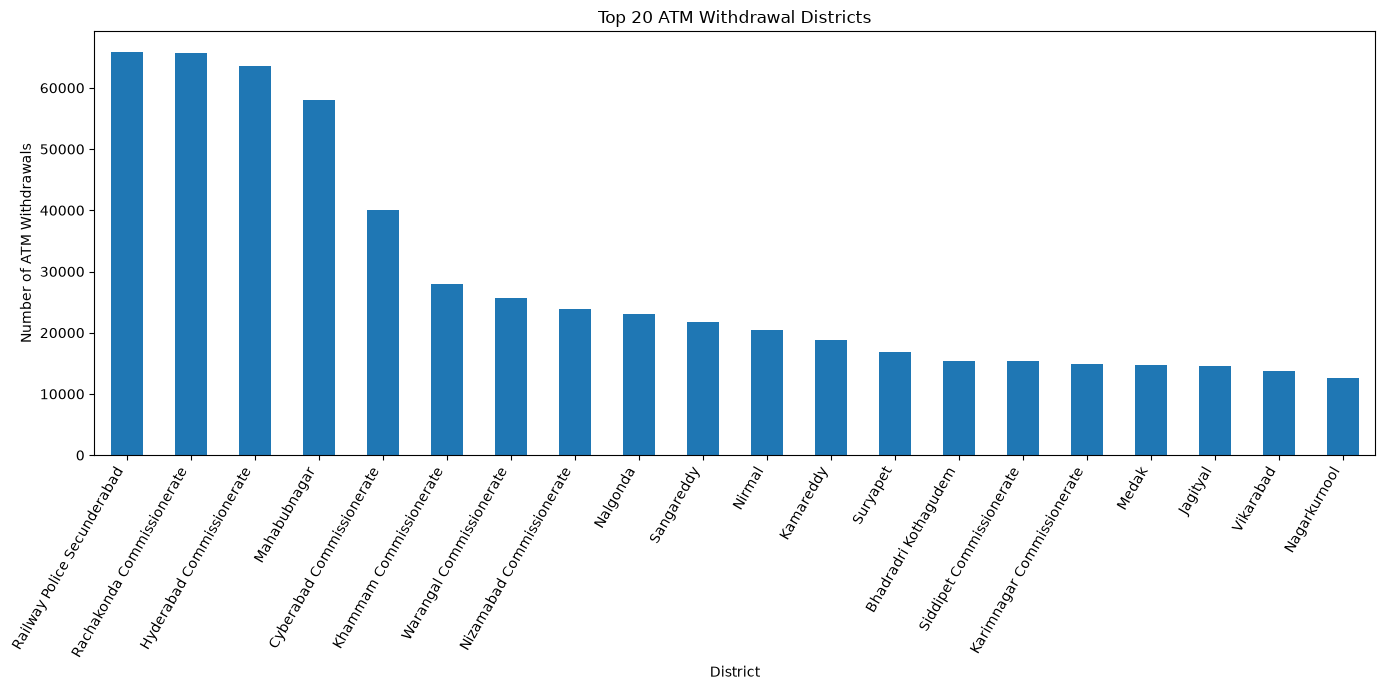

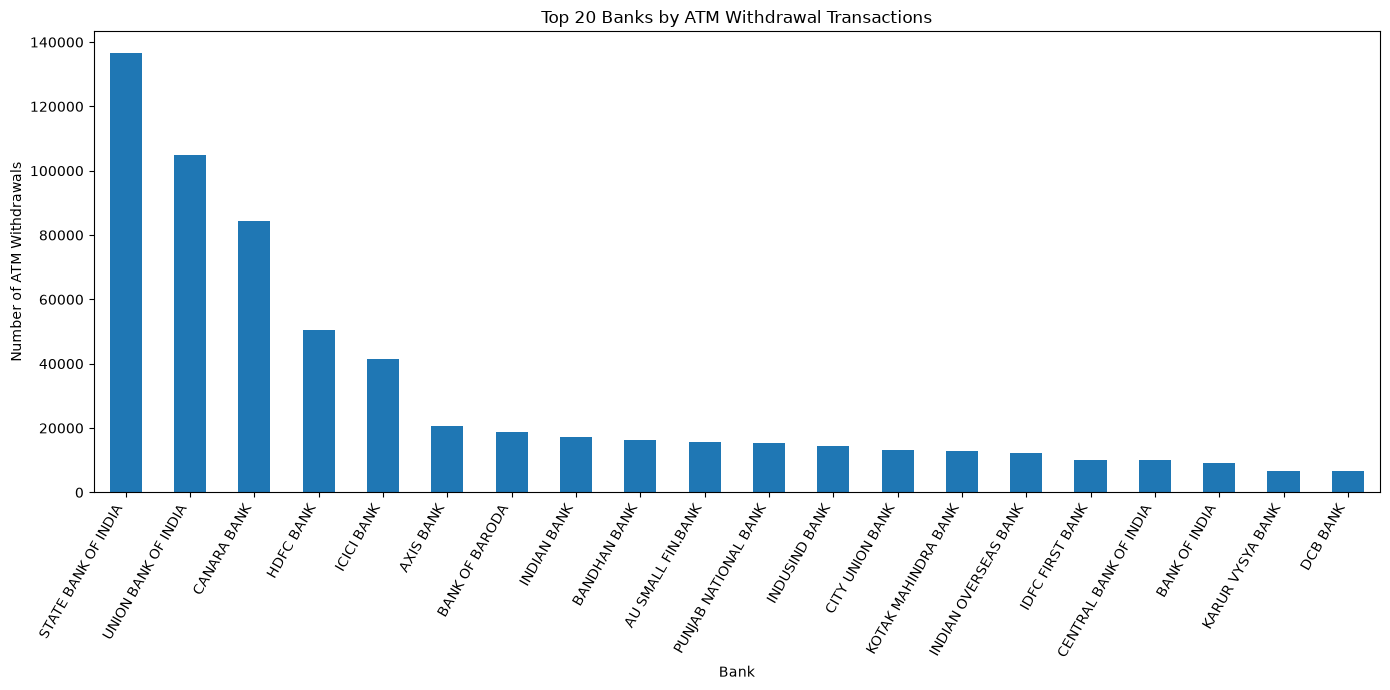

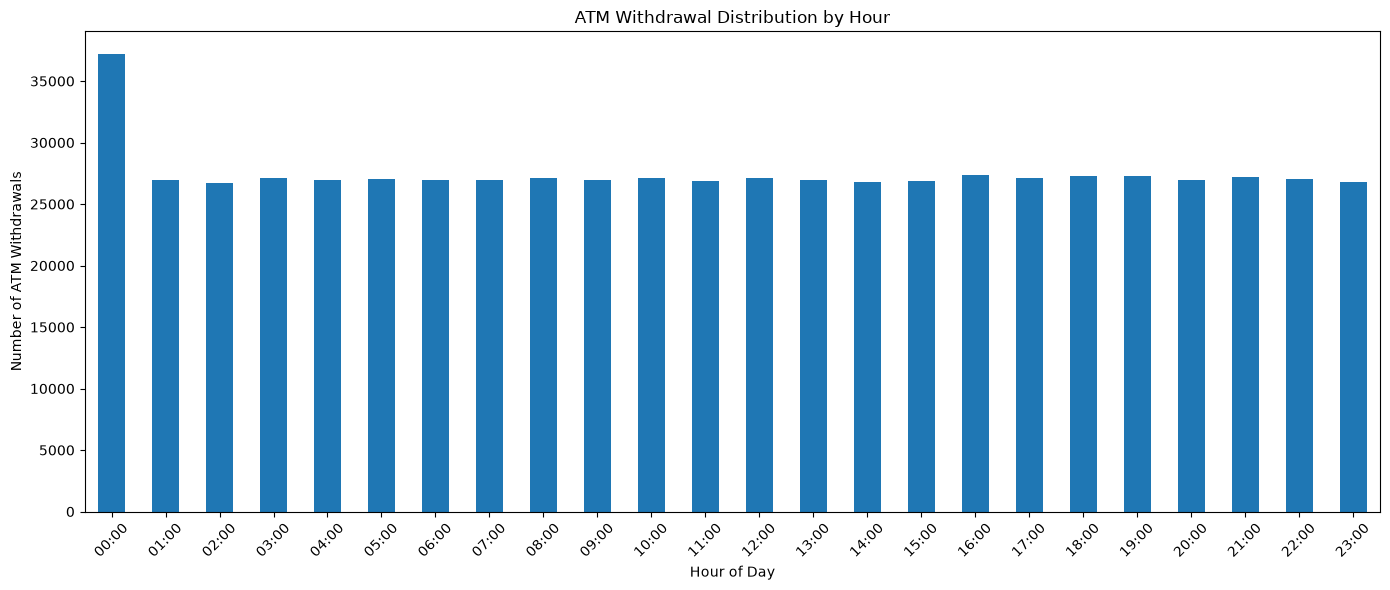

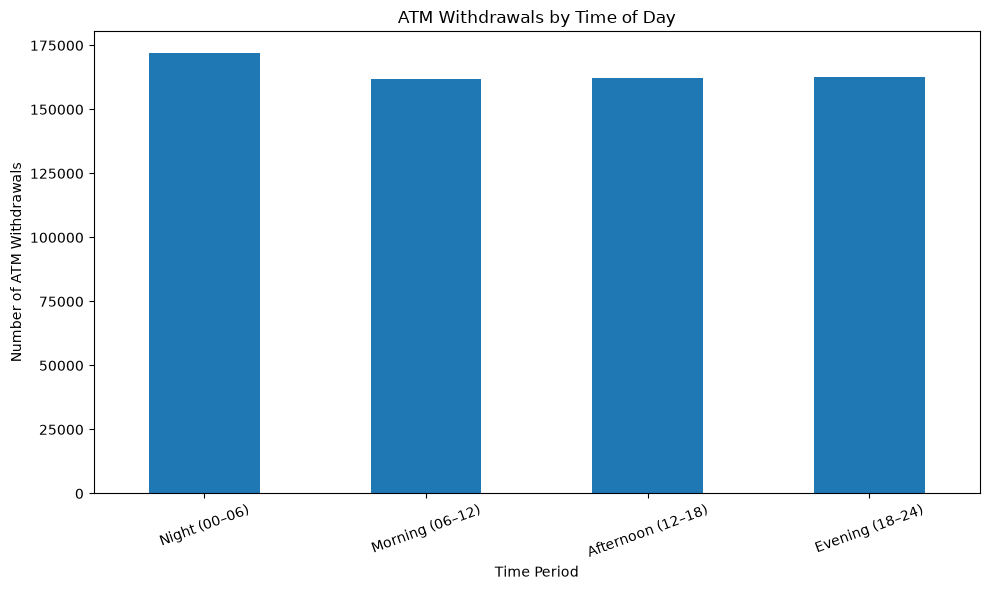

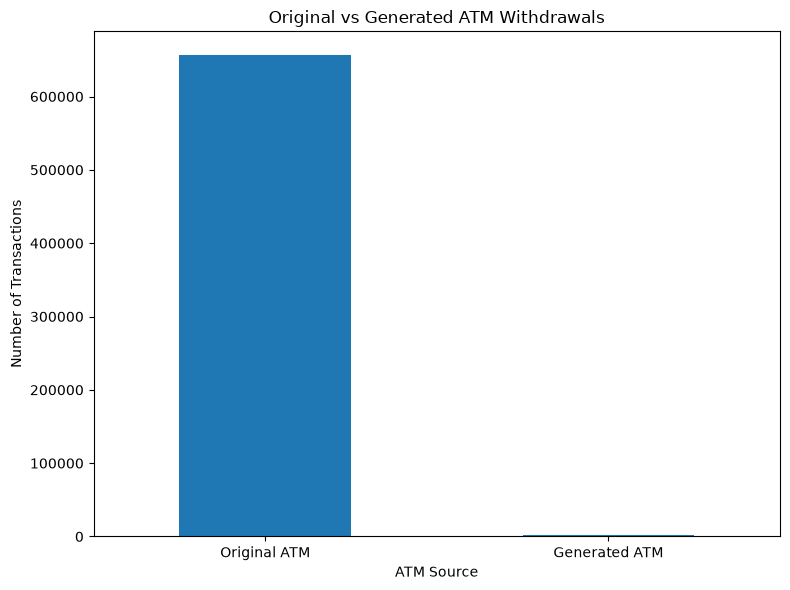


FINAL DATA QUALITY CHECK
New ATM rows                 : 2,390
Missing timestamp            : 0
Missing district             : 0
Missing bank                 : 0
ATM payment mode violations  : 
0
Non-positive amounts         : 186

✓ Processing complete.


In [4]:
# ============================================================
# SIH26184 — TERMINAL NODE -> ATM WITHDRAWAL GENERATION
# ============================================================
#
# INPUTS:
#   final_transactions.csv
#   atm_transactions.csv
#   patterns.txt
#   unknown_patterns.txt
#
# OUTPUT:
#   final/new_atms.csv
#
# ALSO:
#   - combines old ATM + generated ATM
#   - produces ATM distribution visualizations
#
# ============================================================

import pandas as pd
import numpy as np
import re
import random
from pathlib import Path
from collections import defaultdict

import matplotlib.pyplot as plt


# ============================================================
# 1. CONFIGURATION
# ============================================================

FINAL_FILE = Path("final_transactions.csv")
OLD_ATM_FILE = Path("atm_transactions.csv")

PATTERNS_FILE = Path("patterns.txt")
UNKNOWN_PATTERNS_FILE = Path("unknown_patterns.txt")

OUTPUT_DIR = Path("final")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

NEW_ATM_FILE = OUTPUT_DIR / "new_atms.csv"


# ============================================================
# 2. LOAD TRANSACTION DATA
# ============================================================

print("=" * 80)
print("LOADING TRANSACTION DATA")
print("=" * 80)

final_tx = pd.read_csv(FINAL_FILE)
old_atm = pd.read_csv(OLD_ATM_FILE)

print(f"final_transactions.csv : {len(final_tx):,}")
print(f"atm_transactions.csv   : {len(old_atm):,}")


# ------------------------------------------------------------
# Normalize column names
# ------------------------------------------------------------

final_tx.columns = [
    str(c).replace("**", "").strip()
    for c in final_tx.columns
]

old_atm.columns = [
    str(c).replace("**", "").strip()
    for c in old_atm.columns
]


REQUIRED_TX_COLUMNS = [
    "timestamp",
    "from_account",
    "to_account",
    "amount_paid",
    "payment_mode",
    "is_laundering",
    "from_district",
    "to_district",
    "from_indian_bank",
    "to_indian_bank",
]


missing_final = [
    c for c in REQUIRED_TX_COLUMNS
    if c not in final_tx.columns
]

missing_atm = [
    c for c in REQUIRED_TX_COLUMNS
    if c not in old_atm.columns
]

if missing_final:
    raise ValueError(
        f"final_transactions.csv missing columns: {missing_final}"
    )

if missing_atm:
    raise ValueError(
        f"atm_transactions.csv missing columns: {missing_atm}"
    )


# ============================================================
# 3. NORMALIZE TRANSACTION DATA
# ============================================================

for df in [final_tx, old_atm]:

    df["timestamp"] = pd.to_datetime(
        df["timestamp"],
        errors="coerce"
    )

    df["from_account"] = (
        df["from_account"]
        .astype(str)
        .str.strip()
    )

    df["to_account"] = (
        df["to_account"]
        .astype(str)
        .str.strip()
    )

    df["payment_mode"] = (
        df["payment_mode"]
        .astype(str)
        .str.strip()
    )

    # ATM Withdrawal and ATM are treated identically
    df["payment_mode"] = df["payment_mode"].replace(
        {
            "ATM Withdrawal": "ATM",
            "ATM withdrawal": "ATM",
            "ATM WITHDRAWAL": "ATM",
        }
    )


# ============================================================
# 4. COMBINED TRANSACTION DATA FOR LOOKUPS
# ============================================================
#
# We need both normal transactions and existing ATM transactions
# to identify:
#   - account district
#   - account bank
#   - whether terminal transaction is already ATM
#
# ============================================================

all_transactions = pd.concat(
    [
        final_tx,
        old_atm
    ],
    ignore_index=True
)

all_transactions = all_transactions[
    REQUIRED_TX_COLUMNS
].copy()

all_transactions["timestamp"] = pd.to_datetime(
    all_transactions["timestamp"],
    errors="coerce"
)

print(
    f"\nCombined transaction records for lookup: "
    f"{len(all_transactions):,}"
)


# ============================================================
# 5. BUILD ACCOUNT MASTER LOOKUP
# ============================================================
#
# For every account we collect:
#   account -> district
#   account -> bank
#
# We use both from_account and to_account appearances.
#
# ============================================================

account_district = {}
account_bank = {}

for _, row in all_transactions.iterrows():

    from_acc = str(row["from_account"]).strip()
    to_acc = str(row["to_account"]).strip()

    from_district = row["from_district"]
    to_district = row["to_district"]

    from_bank = row["from_indian_bank"]
    to_bank = row["to_indian_bank"]

    # Store only meaningful values
    if from_acc and from_acc != "nan":

        if pd.notna(from_district):
            account_district.setdefault(
                from_acc,
                from_district
            )

        if pd.notna(from_bank):
            account_bank.setdefault(
                from_acc,
                from_bank
            )

    if to_acc and to_acc != "nan":

        if pd.notna(to_district):
            account_district.setdefault(
                to_acc,
                to_district
            )

        if pd.notna(to_bank):
            account_bank.setdefault(
                to_acc,
                to_bank
            )


print(f"Accounts with district information: {len(account_district):,}")
print(f"Accounts with bank information    : {len(account_bank):,}")


# ============================================================
# 6. HELPER FUNCTIONS
# ============================================================

def clean_account(value):
    """
    Normalize account identifiers.
    """
    if value is None:
        return None

    value = str(value).strip()

    if value == "" or value.lower() == "nan":
        return None

    return value


def normalize_payment_mode(value):
    """
    Normalize ATM naming.
    """
    if value is None:
        return None

    value = str(value).strip()

    if value.upper() in {
        "ATM",
        "ATM WITHDRAWAL"
    }:
        return "ATM"

    return value


def rounded_atm_amount(amount):
    """
    Convert the terminal transaction amount into a
    plausible rounded ATM withdrawal amount.

    We intentionally do NOT preserve the exact amount.

    Examples:
        892.33      -> 900
        926.60      -> 900
        13573.24    -> 14000
        592571.00   -> 593000
    """

    if pd.isna(amount):
        return np.nan

    amount = float(amount)

    if amount <= 0:
        return amount

    if amount < 1000:
        # nearest 100
        return round(amount / 100) * 100

    elif amount < 10000:
        # nearest 500
        return round(amount / 500) * 500

    elif amount < 100000:
        # nearest 1000
        return round(amount / 1000) * 1000

    else:
        # nearest 5000
        return round(amount / 5000) * 5000


def get_account_location(account):
    """
    Return district for an account.
    """
    account = clean_account(account)

    if account is None:
        return None

    return account_district.get(account)


def get_account_bank(account):
    """
    Return bank for an account.
    """
    account = clean_account(account)

    if account is None:
        return None

    return account_bank.get(account)


# ============================================================
# 7. PARSE patterns.txt
# ============================================================
#
# Format:
#
# BEGIN LAUNDERING ATTEMPT - FAN-IN: Max 3-degree Fan-In
# transaction rows
# END LAUNDERING ATTEMPT - FAN-IN
#
# Each transaction row:
#
# timestamp,
# sender_id,
# sender_account,
# receiver_id,
# receiver_account,
# amount,
# currency,
# amount,
# currency,
# payment_mode,
# laundering
#
# Therefore:
#   from_account = field 2
#   to_account   = field 4
#
# ============================================================

def parse_known_patterns(filepath):

    patterns = []

    current_pattern = None
    current_rows = []

    with open(filepath, "r", encoding="utf-8") as f:

        for raw_line in f:

            line = raw_line.strip()

            if not line:
                continue

            # ------------------------------------------------
            # BEGIN
            # ------------------------------------------------
            if line.startswith(
                "BEGIN LAUNDERING ATTEMPT"
            ):

                current_pattern = line
                current_rows = []

                continue

            # ------------------------------------------------
            # END
            # ------------------------------------------------
            if line.startswith(
                "END LAUNDERING ATTEMPT"
            ):

                if current_pattern is not None:

                    patterns.append(
                        {
                            "header": current_pattern,
                            "rows": current_rows,
                            "source": "patterns.txt"
                        }
                    )

                current_pattern = None
                current_rows = []

                continue

            # ------------------------------------------------
            # TRANSACTION
            # ------------------------------------------------
            if current_pattern is not None:

                parts = [
                    x.strip()
                    for x in line.split(",")
                ]

                if len(parts) < 11:
                    continue

                timestamp = pd.to_datetime(
                    parts[0],
                    errors="coerce"
                )

                from_account = clean_account(parts[2])
                to_account = clean_account(parts[4])

                try:
                    amount = float(parts[5])
                except:
                    amount = np.nan

                payment_mode = normalize_payment_mode(
                    parts[9]
                )

                laundering = (
                    str(parts[10]).strip().lower()
                    in {"true", "1", "yes"}
                )

                current_rows.append(
                    {
                        "timestamp": timestamp,
                        "from_account": from_account,
                        "to_account": to_account,
                        "amount": amount,
                        "payment_mode": payment_mode,
                        "is_laundering": laundering,
                    }
                )

    return patterns


known_patterns = parse_known_patterns(
    PATTERNS_FILE
)

print(
    f"\nParsed patterns.txt patterns: "
    f"{len(known_patterns):,}"
)


# ============================================================
# 8. PARSE unknown_patterns.txt
# ============================================================
#
# Format:
#
# BEGIN LAUNDERING ATTEMPT - MULTI-HOP CHAIN...
#
# timestamp,
# from_bank,
# from_account,
# to_bank,
# to_account,
# amount,
# payment_mode,
# is_laundering,
# from_district,
# to_district
#
# ============================================================

def parse_unknown_patterns(filepath):

    patterns = []

    current_pattern = None
    current_rows = []

    with open(filepath, "r", encoding="utf-8") as f:

        for raw_line in f:

            line = raw_line.strip()

            if not line:
                continue

            # ------------------------------------------------
            # BEGIN
            # ------------------------------------------------
            if line.startswith(
                "BEGIN LAUNDERING ATTEMPT"
            ):

                current_pattern = line
                current_rows = []

                continue

            # ------------------------------------------------
            # END
            # ------------------------------------------------
            if line.startswith(
                "END LAUNDERING ATTEMPT"
            ):

                if current_pattern is not None:

                    patterns.append(
                        {
                            "header": current_pattern,
                            "rows": current_rows,
                            "source": "unknown_patterns.txt"
                        }
                    )

                current_pattern = None
                current_rows = []

                continue

            # ------------------------------------------------
            # TRANSACTION
            # ------------------------------------------------
            if current_pattern is not None:

                parts = [
                    x.strip()
                    for x in line.split(",")
                ]

                if len(parts) < 10:
                    continue

                timestamp = pd.to_datetime(
                    parts[0],
                    errors="coerce"
                )

                from_bank = parts[1]
                from_account = clean_account(parts[2])

                to_bank = parts[3]
                to_account = clean_account(parts[4])

                try:
                    amount = float(parts[5])
                except:
                    amount = np.nan

                payment_mode = normalize_payment_mode(
                    parts[6]
                )

                laundering = (
                    str(parts[7]).strip().lower()
                    in {"true", "1", "yes"}
                )

                from_district = parts[8]
                to_district = parts[9]

                current_rows.append(
                    {
                        "timestamp": timestamp,
                        "from_account": from_account,
                        "to_account": to_account,
                        "amount": amount,
                        "payment_mode": payment_mode,
                        "is_laundering": laundering,
                        "from_bank": from_bank,
                        "to_bank": to_bank,
                        "from_district": from_district,
                        "to_district": to_district,
                    }
                )

    return patterns


unknown_patterns = parse_unknown_patterns(
    UNKNOWN_PATTERNS_FILE
)

print(
    f"Parsed unknown_patterns.txt patterns: "
    f"{len(unknown_patterns):,}"
)


# ============================================================
# 9. FIND TERMINAL NODES
# ============================================================
#
# IMPORTANT:
#
# Nodes = ACCOUNTS
# Edges = TRANSACTIONS
#
# For every pattern:
#
#       from_account ---> to_account
#
# A terminal node is an account with:
#
#       out_degree = 0
#
# This correctly handles:
#
# FAN-IN:
#
# A ---> X
# B ---> X
# C ---> X
#
# terminal = X
#
#
# FAN-OUT:
#
#             ---> X
#            /
# A --------> Y
#            \
#             ---> Z
#
# terminals = X, Y, Z
#
# ============================================================

def find_terminal_nodes(pattern):

    rows = pattern["rows"]

    if not rows:
        return []

    # All accounts appearing in the pattern
    nodes = set()

    # Accounts that have outgoing transactions
    outgoing_nodes = set()

    for row in rows:

        source = clean_account(
            row.get("from_account")
        )

        target = clean_account(
            row.get("to_account")
        )

        if source:
            nodes.add(source)
            outgoing_nodes.add(source)

        if target:
            nodes.add(target)

    # Terminal = appears in graph but never sends
    terminal_nodes = nodes - outgoing_nodes

    return list(terminal_nodes)


# ============================================================
# 10. FIND THE TERMINAL TRANSACTION FOR EACH NODE
# ============================================================
#
# A terminal account can potentially receive multiple
# transactions within one pattern.
#
# We use the latest transaction INTO that terminal account.
#
# This gives us:
#   - last transaction timestamp
#   - amount
#   - payment mode
#
# ============================================================

def get_terminal_transaction(pattern, terminal):

    terminal = clean_account(terminal)

    candidate_rows = []

    for row in pattern["rows"]:

        target = clean_account(
            row.get("to_account")
        )

        if target == terminal:

            candidate_rows.append(row)

    if not candidate_rows:
        return None

    # Latest transaction into terminal
    candidate_rows.sort(
        key=lambda x: (
            pd.Timestamp.min
            if pd.isna(x["timestamp"])
            else x["timestamp"]
        )
    )

    return candidate_rows[-1]


# ============================================================
# 11. CREATE PATTERN SIGNATURE
# ============================================================
#
# Used to recognize overlap between patterns.
#
# We don't rely only on the textual header because the same
# pattern may have slightly different descriptions.
#
# Signature = ordered set of transaction edges.
#
# ============================================================

def pattern_signature(pattern):

    edges = []

    for row in pattern["rows"]:

        source = clean_account(
            row.get("from_account")
        )

        target = clean_account(
            row.get("to_account")
        )

        timestamp = row.get("timestamp")

        if source and target:

            timestamp_str = (
                str(timestamp)
                if pd.notna(timestamp)
                else ""
            )

            edges.append(
                (
                    timestamp_str,
                    source,
                    target
                )
            )

    return tuple(sorted(edges))


# ============================================================
# 12. PROCESS PATTERNS WITH PRIORITY
# ============================================================
#
# Priority:
#
#       1. patterns.txt
#       2. unknown_patterns.txt
#
# If exactly the same pattern appears in both, the known pattern
# wins and the unknown pattern is skipped.
#
# ============================================================

all_patterns = []

seen_signatures = set()

# ------------------------------------------------------------
# FIRST: known patterns
# ------------------------------------------------------------

for pattern in known_patterns:

    signature = pattern_signature(pattern)

    if signature in seen_signatures:
        continue

    seen_signatures.add(signature)
    all_patterns.append(pattern)


# ------------------------------------------------------------
# SECOND: unknown patterns
# ------------------------------------------------------------

unknown_skipped_due_to_priority = 0

for pattern in unknown_patterns:

    signature = pattern_signature(pattern)

    if signature in seen_signatures:

        unknown_skipped_due_to_priority += 1
        continue

    seen_signatures.add(signature)
    all_patterns.append(pattern)


print("\nPattern priority processing:")
print(
    f"Known patterns accepted       : "
    f"{len(known_patterns):,}"
)

print(
    f"Unknown patterns accepted     : "
    f"{len(all_patterns) - len(known_patterns):,}"
)

print(
    f"Unknown patterns skipped      : "
    f"{unknown_skipped_due_to_priority:,}"
)


# ============================================================
# 13. CHECK WHETHER TERMINAL ALREADY HAS ATM
# ============================================================
#
# We check the actual terminal transaction inside the pattern.
#
# If that terminal transaction itself is ATM:
#
#       NO NEW ATM IS CREATED
#
# This is exactly what we want because that pattern already
# terminates in a cash withdrawal.
#
# ============================================================

generated_rows = []

statistics = {
    "patterns_processed": 0,
    "patterns_without_rows": 0,
    "patterns_without_terminal": 0,
    "terminal_nodes_found": 0,
    "terminal_already_atm": 0,
    "terminal_missing_location": 0,
    "atm_generated": 0,
}


# ============================================================
# 14. PROCESS EVERY PATTERN
# ============================================================

for pattern_idx, pattern in enumerate(
    all_patterns,
    start=1
):

    statistics["patterns_processed"] += 1

    rows = pattern["rows"]

    if not rows:

        statistics["patterns_without_rows"] += 1
        continue

    terminal_nodes = find_terminal_nodes(
        pattern
    )

    if not terminal_nodes:

        statistics["patterns_without_terminal"] += 1
        continue

    statistics["terminal_nodes_found"] += len(
        terminal_nodes
    )

    # --------------------------------------------------------
    # Process every terminal account
    # --------------------------------------------------------

    for terminal_account in terminal_nodes:

        terminal_tx = get_terminal_transaction(
            pattern,
            terminal_account
        )

        if terminal_tx is None:
            continue

        terminal_payment_mode = normalize_payment_mode(
            terminal_tx.get("payment_mode")
        )

        # ----------------------------------------------------
        # If terminal transaction is already ATM,
        # no additional ATM withdrawal.
        # ----------------------------------------------------

        if terminal_payment_mode == "ATM":

            statistics["terminal_already_atm"] += 1
            continue

        # ----------------------------------------------------
        # Determine district
        #
        # First use information embedded in unknown_patterns.
        # Otherwise use the global transaction master.
        # ----------------------------------------------------

        district = None
        bank = None

        if terminal_tx.get("to_district") is not None:

            candidate_district = terminal_tx.get(
                "to_district"
            )

            if pd.notna(candidate_district):
                candidate_district = str(
                    candidate_district
                ).strip()

                if candidate_district:
                    district = candidate_district

        if district is None:
            district = get_account_location(
                terminal_account
            )

        # ----------------------------------------------------
        # Bank
        # ----------------------------------------------------

        if terminal_tx.get("to_bank") is not None:

            candidate_bank = terminal_tx.get(
                "to_bank"
            )

            if pd.notna(candidate_bank):
                candidate_bank = str(
                    candidate_bank
                ).strip()

                if candidate_bank:
                    bank = candidate_bank

        if bank is None:
            bank = get_account_bank(
                terminal_account
            )

        # ----------------------------------------------------
        # We cannot create a geographically meaningful
        # withdrawal if the account has no district.
        #
        # Do NOT silently invent a district.
        # ----------------------------------------------------

        if district is None or str(district).strip() == "":
            statistics["terminal_missing_location"] += 1
            continue

        # ----------------------------------------------------
        # Timestamp
        #
        # Random 1–60 minute delay after the terminal
        # transaction.
        # ----------------------------------------------------

        terminal_timestamp = terminal_tx.get(
            "timestamp"
        )

        if pd.isna(terminal_timestamp):
            continue

        delay_minutes = random.randint(
            1,
            60
        )

        withdrawal_timestamp = (
            pd.Timestamp(terminal_timestamp)
            + pd.Timedelta(
                minutes=delay_minutes
            )
        )

        # ----------------------------------------------------
        # Amount
        #
        # ATM withdrawal amount is rounded.
        # ----------------------------------------------------

        terminal_amount = terminal_tx.get(
            "amount"
        )

        withdrawal_amount = rounded_atm_amount(
            terminal_amount
        )

        if pd.isna(withdrawal_amount):
            continue

        # ----------------------------------------------------
        # Bank fallback
        # ----------------------------------------------------

        if bank is None:
            bank = "UNKNOWN"

        # ----------------------------------------------------
        # Construct ATM transaction
        #
        # IMPORTANT:
        #
        # You said these will later be converted into actual
        # withdrawals. For now we preserve the existing
        # transaction schema.
        #
        # Therefore:
        #
        #   from_account = terminal account
        #   to_account   = terminal account
        #
        # This mirrors the current ATM representation in the
        # source dataset.
        # ----------------------------------------------------

        generated_rows.append(
            {
                "timestamp": withdrawal_timestamp,
                "from_account": terminal_account,
                "to_account": terminal_account,
                "amount_paid": withdrawal_amount,
                "payment_mode": "ATM",
                "is_laundering": True,
                "from_district": district,
                "to_district": district,
                "from_indian_bank": bank,
                "to_indian_bank": bank,

                # Metadata useful for validation/auditing.
                # These are NOT part of the final output.
                "_pattern_index": pattern_idx,
                "_pattern_source": pattern["source"],
                "_pattern_header": pattern["header"],
                "_terminal_account": terminal_account,
                "_source_timestamp": terminal_timestamp,
                "_delay_minutes": delay_minutes,
            }
        )

        statistics["atm_generated"] += 1


# ============================================================
# 15. CREATE DATAFRAME
# ============================================================

new_atms = pd.DataFrame(
    generated_rows
)


# ============================================================
# 16. REMOVE INTERNAL METADATA FROM FINAL OUTPUT
# ============================================================

if len(new_atms) > 0:

    new_atms_output = new_atms[
        REQUIRED_TX_COLUMNS
    ].copy()

else:

    new_atms_output = pd.DataFrame(
        columns=REQUIRED_TX_COLUMNS
    )


# ============================================================
# 17. SAVE new_atms.csv
# ============================================================

new_atms_output.to_csv(
    NEW_ATM_FILE,
    index=False
)


# ============================================================
# 18. PRINT GENERATION SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("ATM GENERATION SUMMARY")
print("=" * 80)

for key, value in statistics.items():

    print(
        f"{key:35s}: {value:,}"
    )

print("\nOutput:")
print(
    f"  {NEW_ATM_FILE}"
)

print(
    f"  Rows: {len(new_atms_output):,}"
)


# ============================================================
# 19. BASIC VALIDATION
# ============================================================

assert list(
    new_atms_output.columns
) == REQUIRED_TX_COLUMNS

if len(new_atms_output) > 0:

    assert (
        new_atms_output["payment_mode"]
        .eq("ATM")
        .all()
    )

    assert (
        new_atms_output["is_laundering"]
        .astype(bool)
        .all()
    )

print("\n✓ new_atms.csv schema validated.")
print("✓ All generated records are ATM transactions.")
print("✓ All generated records are marked laundering.")


# ============================================================
# 20. COMBINE OLD ATM + NEW ATM
# ============================================================
#
# This dataframe is ONLY for analysis/visualization.
#
# We do NOT overwrite atm_transactions.csv.
#
# ============================================================

combined_atm = pd.concat(
    [
        old_atm[REQUIRED_TX_COLUMNS],
        new_atms_output[REQUIRED_TX_COLUMNS]
    ],
    ignore_index=True
)

combined_atm["timestamp"] = pd.to_datetime(
    combined_atm["timestamp"],
    errors="coerce"
)

combined_atm["payment_mode"] = (
    combined_atm["payment_mode"]
    .apply(normalize_payment_mode)
)

print("\n" + "=" * 80)
print("COMBINED ATM DATA")
print("=" * 80)

print(
    f"Original ATM transactions : {len(old_atm):,}"
)

print(
    f"New generated ATM         : {len(new_atms_output):,}"
)

print(
    f"Combined ATM transactions : {len(combined_atm):,}"
)


# ============================================================
# 21. ATM DISTRIBUTION BY DISTRICT
# ============================================================

district_distribution = (
    combined_atm
    .groupby("from_district")
    .size()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14, 7))

district_distribution.head(20).plot(
    kind="bar"
)

plt.title(
    "Top 20 ATM Withdrawal Districts"
)

plt.xlabel(
    "District"
)

plt.ylabel(
    "Number of ATM Withdrawals"
)

plt.xticks(
    rotation=60,
    ha="right"
)

plt.tight_layout()

plt.show()


# ============================================================
# 22. ATM DISTRIBUTION BY BANK
# ============================================================

bank_distribution = (
    combined_atm
    .groupby("from_indian_bank")
    .size()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14, 7))

bank_distribution.head(20).plot(
    kind="bar"
)

plt.title(
    "Top 20 Banks by ATM Withdrawal Transactions"
)

plt.xlabel(
    "Bank"
)

plt.ylabel(
    "Number of ATM Withdrawals"
)

plt.xticks(
    rotation=60,
    ha="right"
)

plt.tight_layout()

plt.show()


# ============================================================
# 23. ATM DISTRIBUTION BY HOUR
# ============================================================

combined_atm["hour"] = (
    combined_atm["timestamp"]
    .dt.hour
)

hour_distribution = (
    combined_atm
    .groupby("hour")
    .size()
    .reindex(range(24), fill_value=0)
)

plt.figure(figsize=(14, 6))

hour_distribution.plot(
    kind="bar"
)

plt.title(
    "ATM Withdrawal Distribution by Hour"
)

plt.xlabel(
    "Hour of Day"
)

plt.ylabel(
    "Number of ATM Withdrawals"
)

plt.xticks(
    range(24),
    [f"{h:02d}:00" for h in range(24)],
    rotation=45
)

plt.tight_layout()

plt.show()


# ============================================================
# 24. ATM DISTRIBUTION BY TIME OF DAY
# ============================================================

def time_bucket(hour):

    if 0 <= hour < 6:
        return "Night (00–06)"

    elif 6 <= hour < 12:
        return "Morning (06–12)"

    elif 12 <= hour < 18:
        return "Afternoon (12–18)"

    else:
        return "Evening (18–24)"


combined_atm["time_bucket"] = (
    combined_atm["hour"]
    .apply(time_bucket)
)

time_bucket_distribution = (
    combined_atm
    .groupby("time_bucket")
    .size()
    .reindex(
        [
            "Night (00–06)",
            "Morning (06–12)",
            "Afternoon (12–18)",
            "Evening (18–24)"
        ]
    )
)

plt.figure(figsize=(10, 6))

time_bucket_distribution.plot(
    kind="bar"
)

plt.title(
    "ATM Withdrawals by Time of Day"
)

plt.xlabel(
    "Time Period"
)

plt.ylabel(
    "Number of ATM Withdrawals"
)

plt.xticks(
    rotation=20
)

plt.tight_layout()

plt.show()


# ============================================================
# 25. NEW ATM VS ORIGINAL ATM
# ============================================================

atm_source_distribution = pd.Series(
    {
        "Original ATM": len(old_atm),
        "Generated ATM": len(new_atms_output)
    }
)

plt.figure(figsize=(8, 6))

atm_source_distribution.plot(
    kind="bar"
)

plt.title(
    "Original vs Generated ATM Withdrawals"
)

plt.xlabel(
    "ATM Source"
)

plt.ylabel(
    "Number of Transactions"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()

plt.show()


# ============================================================
# 26. FINAL DATA QUALITY SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("FINAL DATA QUALITY CHECK")
print("=" * 80)

print(
    f"New ATM rows                 : "
    f"{len(new_atms_output):,}"
)

print(
    f"Missing timestamp            : "
    f"{new_atms_output['timestamp'].isna().sum():,}"
)

print(
    f"Missing district             : "
    f"{new_atms_output['from_district'].isna().sum():,}"
)

print(
    f"Missing bank                 : "
    f"{new_atms_output['from_indian_bank'].isna().sum():,}"
)

print(
    f"ATM payment mode violations  : "
)
print(f"{(~new_atms_output['payment_mode'].eq('ATM')).sum():,}")

print(
    f"Non-positive amounts         : "
    f"{(new_atms_output['amount_paid'] <= 0).sum():,}"
)

print("\n✓ Processing complete.")

In [5]:
# ============================================================
# SAVE PATTERNS REQUIRING REVIEW
# ============================================================
#
# Outputs:
#
#   final/patterns_without_terminal.txt
#   final/skipped_patterns.txt
#
# The complete original pattern block is preserved.
# ============================================================

PATTERNS_WITHOUT_TERMINAL_FILE = (
    OUTPUT_DIR / "patterns_without_terminal.txt"
)

SKIPPED_PATTERNS_FILE = (
    OUTPUT_DIR / "skipped_patterns.txt"
)


# ============================================================
# HELPER — FORMAT PATTERN BACK INTO REVIEWABLE TEXT
# ============================================================

def format_pattern_for_review(pattern):
    """
    Reconstruct a readable pattern block from the parsed
    representation.
    """

    lines = []

    # Original BEGIN/header
    lines.append(
        pattern["header"]
    )

    rows = pattern.get("rows", [])

    for row in rows:

        timestamp = row.get("timestamp")

        if pd.notna(timestamp):
            timestamp_str = pd.Timestamp(
                timestamp
            ).strftime("%Y/%m/%d %H:%M")
        else:
            timestamp_str = ""

        source = clean_account(
            row.get("from_account")
        )

        target = clean_account(
            row.get("to_account")
        )

        amount = row.get("amount")

        if pd.isna(amount):
            amount_str = ""
        else:
            amount_str = str(amount)

        payment_mode = (
            row.get("payment_mode")
            or ""
        )

        laundering = row.get(
            "is_laundering",
            False
        )

        # ----------------------------------------------------
        # patterns.txt format
        # ----------------------------------------------------

        if pattern["source"] == "patterns.txt":

            lines.append(
                ",".join(
                    [
                        timestamp_str,
                        "",
                        source or "",
                        "",
                        target or "",
                        amount_str,
                        "",
                        amount_str,
                        "",
                        payment_mode,
                        "1" if laundering else "0"
                    ]
                )
            )

        # ----------------------------------------------------
        # unknown_patterns.txt format
        # ----------------------------------------------------

        else:

            from_bank = row.get(
                "from_bank",
                ""
            )

            to_bank = row.get(
                "to_bank",
                ""
            )

            from_district = row.get(
                "from_district",
                ""
            )

            to_district = row.get(
                "to_district",
                ""
            )

            lines.append(
                ",".join(
                    [
                        timestamp_str,
                        str(from_bank),
                        source or "",
                        str(to_bank),
                        target or "",
                        amount_str,
                        payment_mode,
                        "True" if laundering else "False",
                        str(from_district),
                        str(to_district)
                    ]
                )
            )

    # END marker
    header = pattern["header"]

    if header.startswith(
        "BEGIN LAUNDERING ATTEMPT"
    ):
        end_header = header.replace(
            "BEGIN LAUNDERING ATTEMPT",
            "END LAUNDERING ATTEMPT",
            1
        )
    else:
        end_header = "END LAUNDERING ATTEMPT"

    lines.append(end_header)

    return "\n".join(lines)


# ============================================================
# 1. FIND PATTERNS WITHOUT TERMINAL NODES
# ============================================================

patterns_without_terminal = []

for pattern in all_patterns:

    terminal_nodes = find_terminal_nodes(
        pattern
    )

    if not terminal_nodes:

        patterns_without_terminal.append(
            pattern
        )


# ============================================================
# 2. FIND UNKNOWN PATTERNS SKIPPED DUE TO PRIORITY
# ============================================================
#
# Re-evaluate signatures:
#
#   known patterns are processed first
#   unknown pattern is skipped if its signature already
#   exists in the known set.
#
# ============================================================

known_signatures = set()

for pattern in known_patterns:

    signature = pattern_signature(
        pattern
    )

    known_signatures.add(
        signature
    )


skipped_patterns = []

for pattern in unknown_patterns:

    signature = pattern_signature(
        pattern
    )

    if signature in known_signatures:

        skipped_patterns.append(
            pattern
        )


# ============================================================
# 3. SAVE PATTERNS WITHOUT TERMINAL
# ============================================================

with open(
    PATTERNS_WITHOUT_TERMINAL_FILE,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "# ============================================================\n"
    )

    f.write(
        "# PATTERNS WITHOUT TERMINAL NODES\n"
    )

    f.write(
        "# These patterns could not produce a terminal account\n"
    )

    f.write(
        "# using the account graph / out-degree = 0 rule.\n"
    )

    f.write(
        "# ============================================================\n\n"
    )

    for i, pattern in enumerate(
        patterns_without_terminal,
        start=1
    ):

        f.write(
            f"# REVIEW PATTERN {i}\n"
        )

        f.write(
            f"# SOURCE: {pattern['source']}\n"
        )

        f.write(
            f"# HEADER: {pattern['header']}\n\n"
        )

        f.write(
            format_pattern_for_review(
                pattern
            )
        )

        f.write(
            "\n\n"
        )


# ============================================================
# 4. SAVE SKIPPED PATTERNS
# ============================================================

with open(
    SKIPPED_PATTERNS_FILE,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "# ============================================================\n"
    )

    f.write(
        "# SKIPPED UNKNOWN PATTERNS\n"
    )

    f.write(
        "# These patterns were found in unknown_patterns.txt but\n"
    )

    f.write(
        "# were skipped because the same transaction pattern was\n"
    )

    f.write(
        "# already present in patterns.txt.\n"
    )

    f.write(
        "# patterns.txt has priority over unknown_patterns.txt.\n"
    )

    f.write(
        "# ============================================================\n\n"
    )

    for i, pattern in enumerate(
        skipped_patterns,
        start=1
    ):

        f.write(
            f"# REVIEW SKIPPED PATTERN {i}\n"
        )

        f.write(
            f"# SOURCE: {pattern['source']}\n"
        )

        f.write(
            f"# HEADER: {pattern['header']}\n\n"
        )

        f.write(
            format_pattern_for_review(
                pattern
            )
        )

        f.write(
            "\n\n"
        )


# ============================================================
# 5. SUMMARY
# ============================================================

print("=" * 80)
print("PATTERN REVIEW FILES")
print("=" * 80)

print(
    f"Patterns without terminal : "
    f"{len(patterns_without_terminal):,}"
)

print(
    f"Skipped unknown patterns  : "
    f"{len(skipped_patterns):,}"
)

print()

print(
    f"Saved: {PATTERNS_WITHOUT_TERMINAL_FILE}"
)

print(
    f"Saved: {SKIPPED_PATTERNS_FILE}"
)

print("\n✓ Review files generated.")

PATTERN REVIEW FILES
Patterns without terminal : 27
Skipped unknown patterns  : 5

Saved: final\patterns_without_terminal.txt
Saved: final\skipped_patterns.txt

✓ Review files generated.


LOADING ATM DATA
Original ATM transactions : 656,076
Generated ATM transactions: 2,390

Final ATM file:
  final\final_atm_trans.csv
  Rows: 658,466
  Fraud ATM rows: 2,902
  Legit ATM rows: 655,564

LOADING TRANSACTION DATA FOR REPORT GENERATION
Transactions loaded: 6,269,814
Account bank mappings    : 697,011
Account district mappings: 697,011

patterns.txt         : 117
unknown_patterns.txt : 1,215

Pattern priority:
Known accepted        : 117
Unknown accepted      : 1,210
Unknown skipped       : 5

REPORT GENERATION SUMMARY
patterns_processed                      : 1,327
patterns_without_rows                   : 0
patterns_without_victims                : 25
victims_found                           : 1,734
reports_generated                       : 1,734
victims_missing_district                : 0
victims_missing_bank                    : 0
victims_missing_transaction             : 0
victims_missing_timestamp               : 0

Output files:
  ATM transactions : final\final_atm_trans

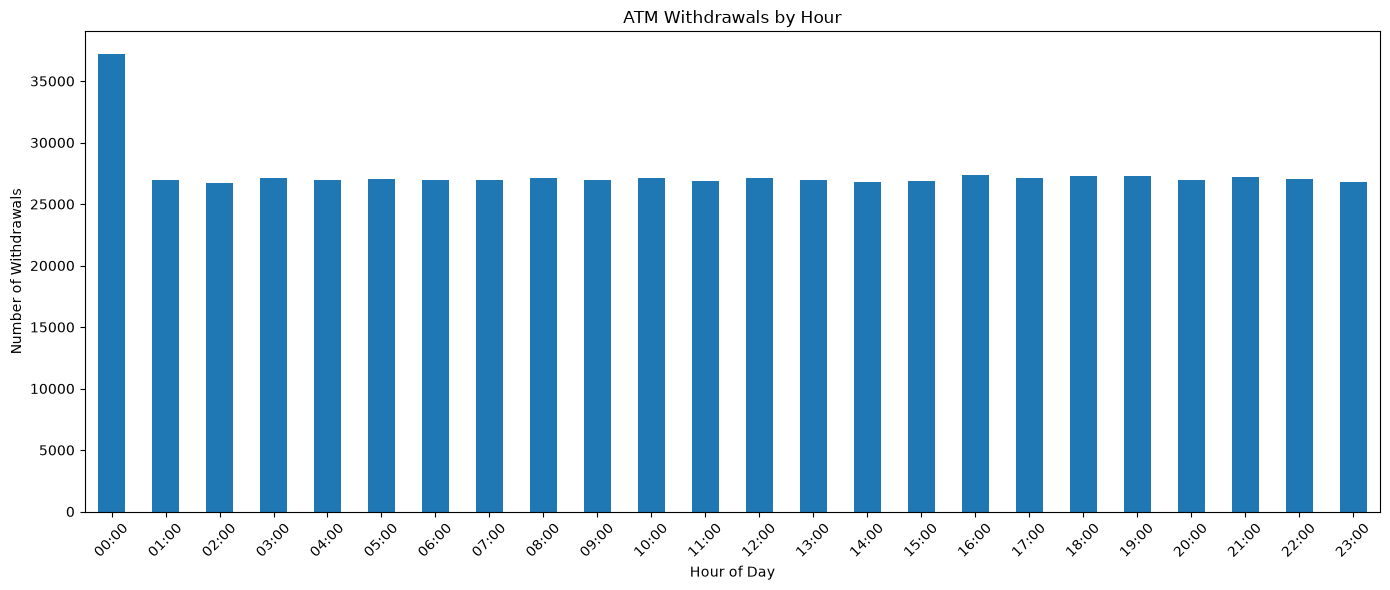

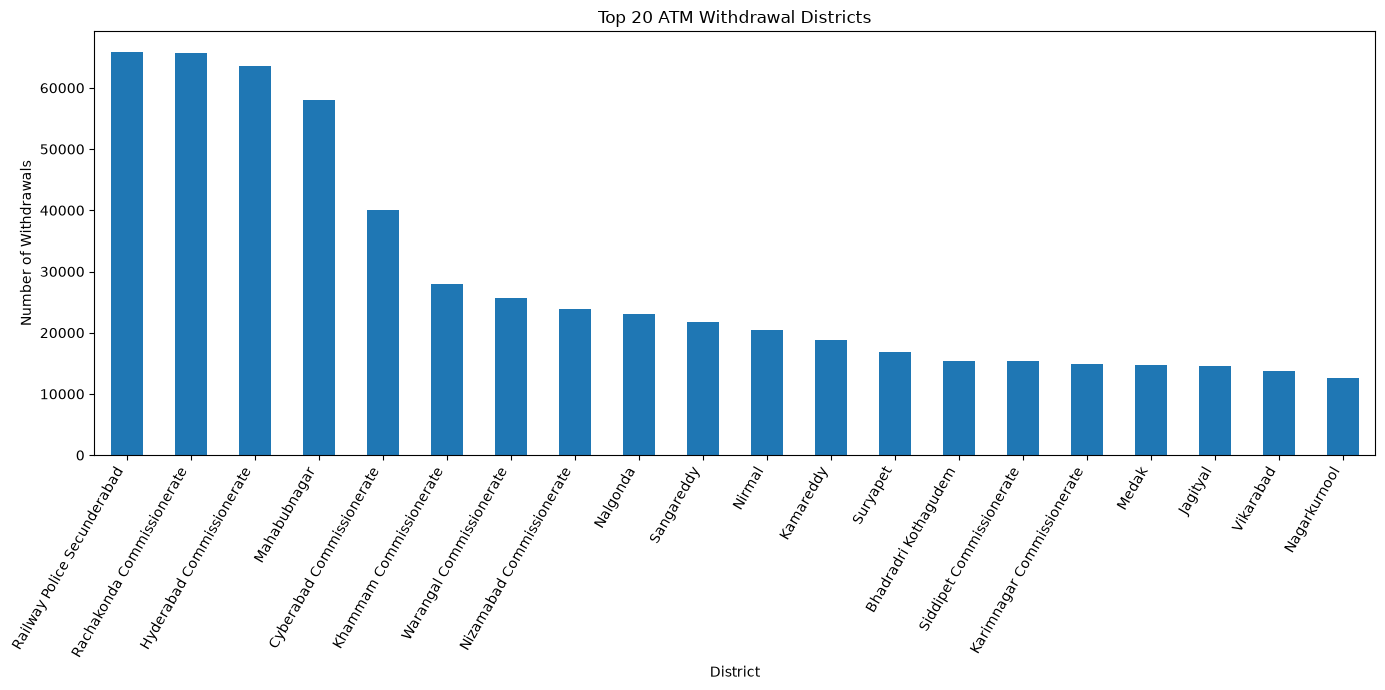

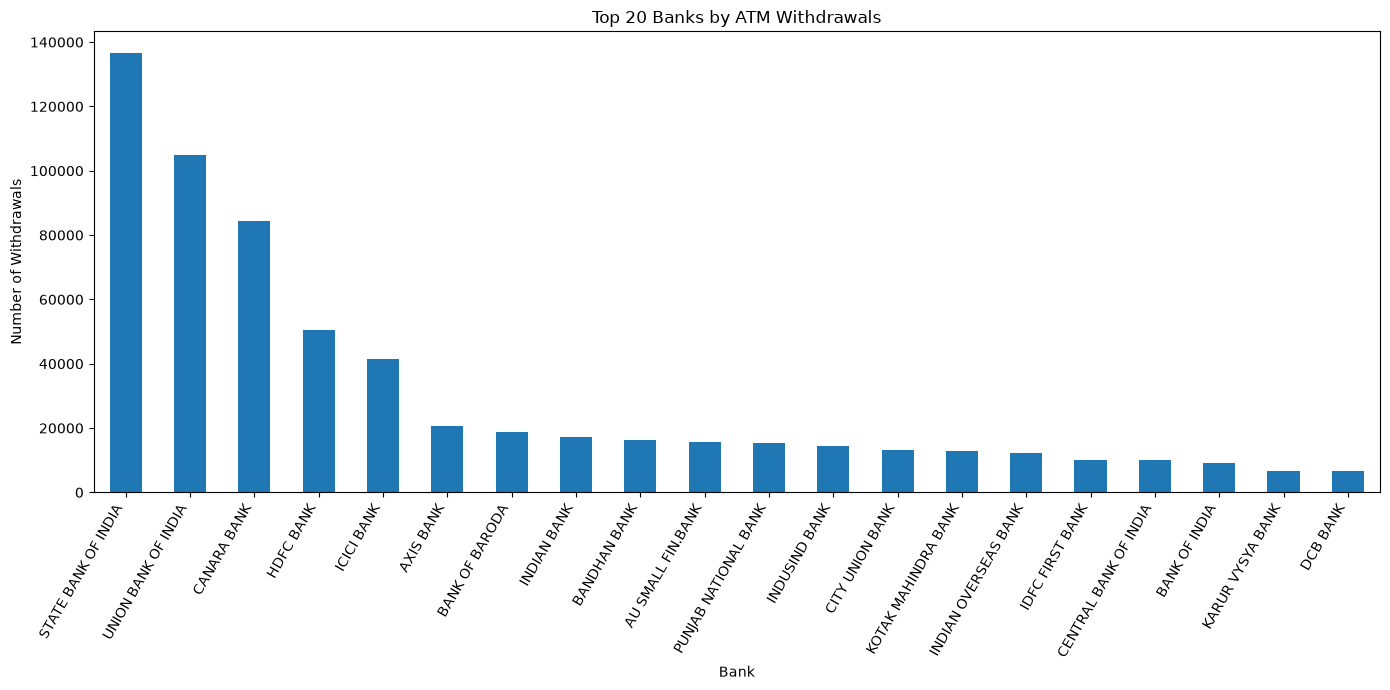

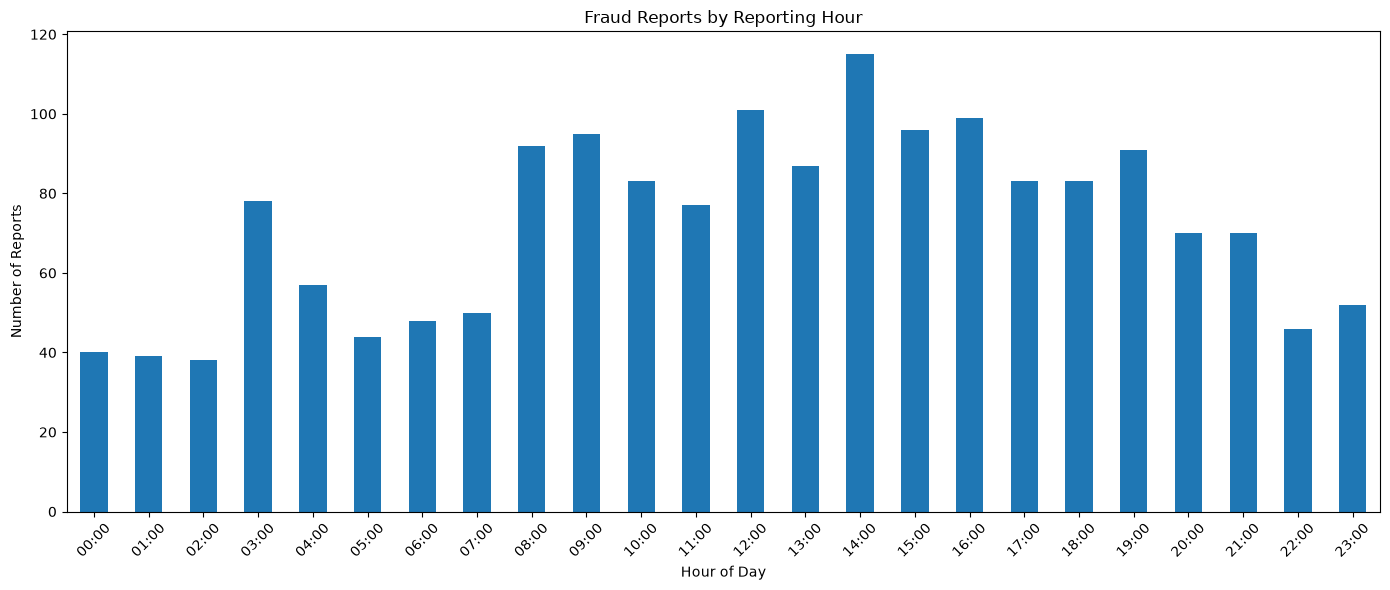

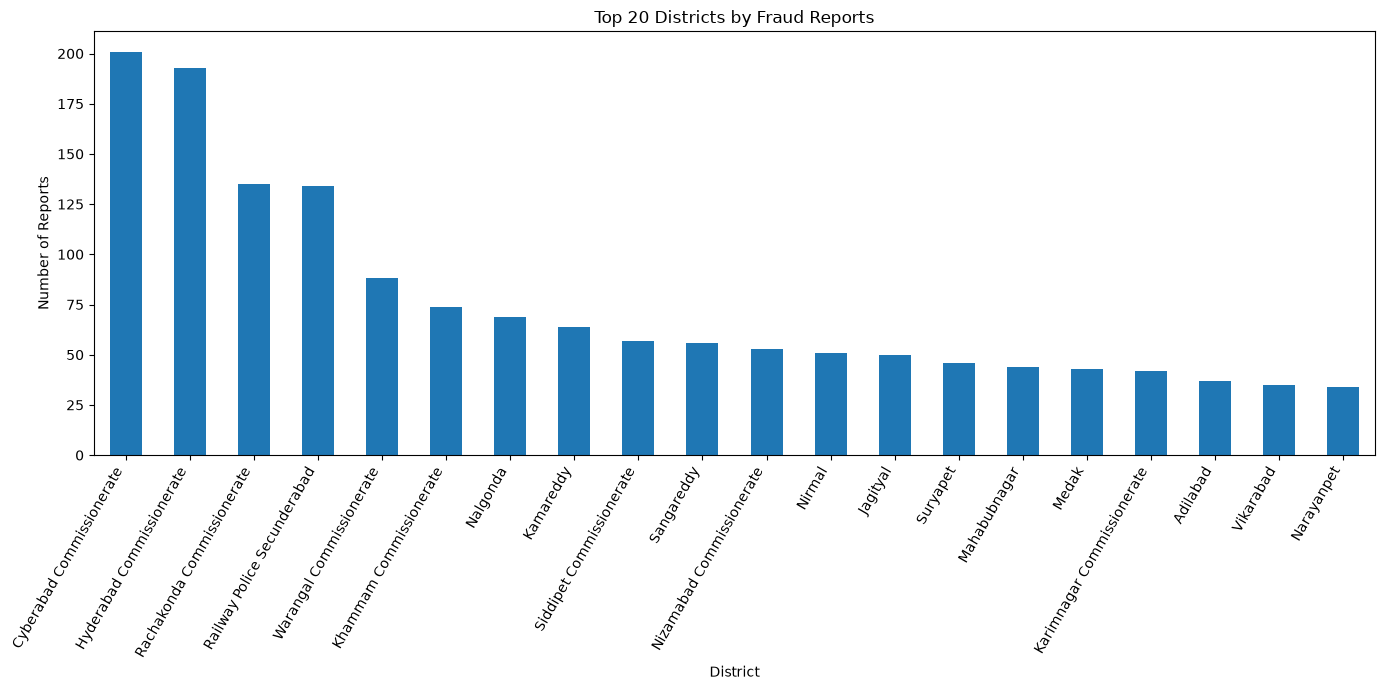

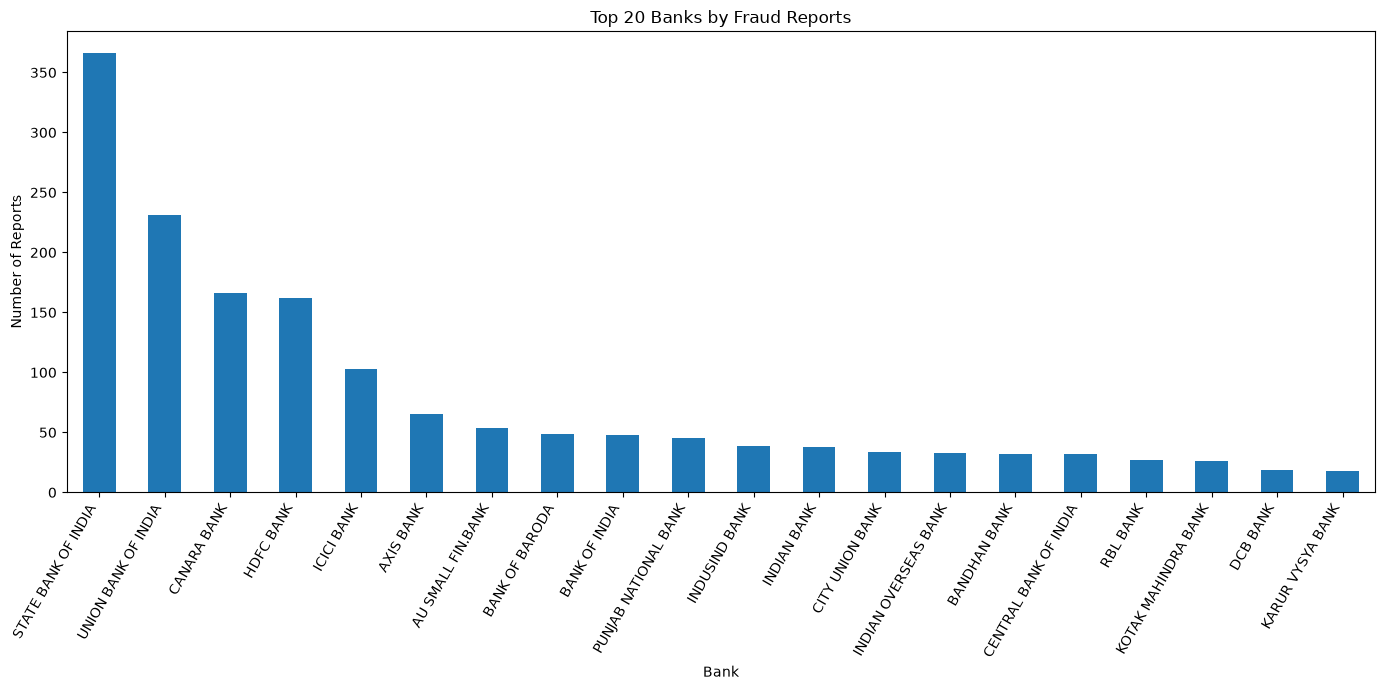

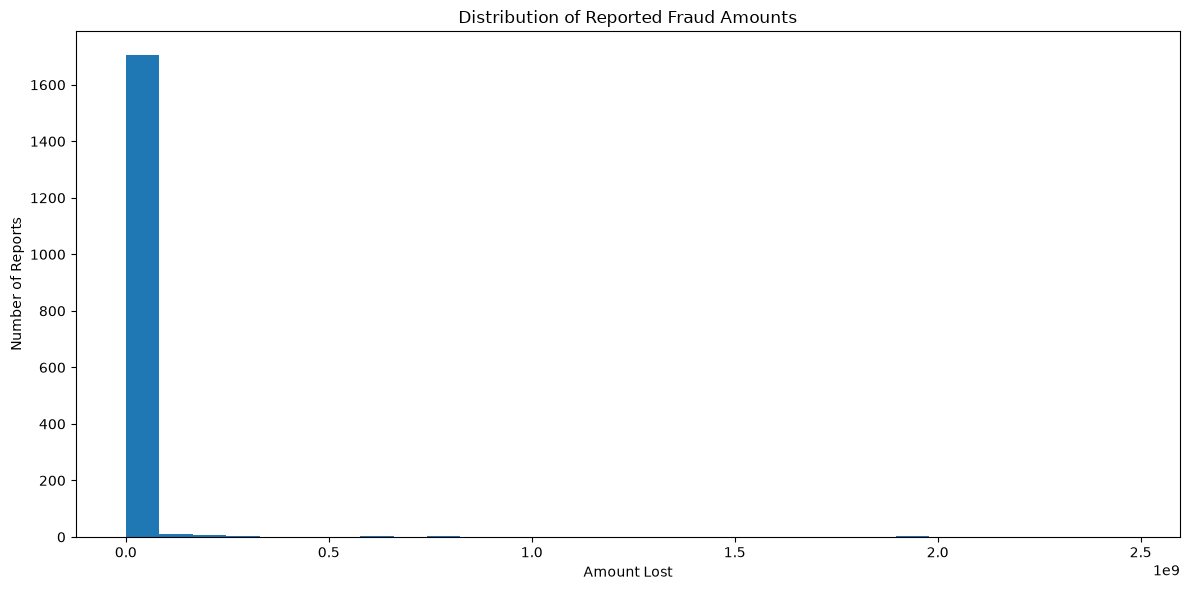


FINAL OUTPUT
final_atm_trans.csv : 658,466 rows
reports.csv         : 1,734 rows
report log          : 1,759 rows
unmatched patterns  : 25
skipped patterns    : 5

✓ ATM consolidation complete.
✓ Victim/source nodes identified.
✓ Fraud reports generated.
✓ Pattern priority preserved.
✓ Audit logs generated.
✓ Distribution analysis generated.


In [9]:
# ============================================================
# SIH26184 — ATM CONSOLIDATION + VICTIM REPORT GENERATION
# ============================================================
#
# INPUTS:
#
#   final/new_atms.csv
#   atm_transactions.csv
#   patterns.txt
#   unknown_patterns.txt
#   final_transactions.csv
#
# OUTPUTS:
#
#   final/final_atm_trans.csv
#   final/reports.csv
#   final/report_generation_log.csv
#   final/report_unmatched_patterns.txt
#   final/report_skipped_patterns.txt
#
# VISUALS:
#
#   - ATM withdrawals by hour
#   - ATM withdrawals by district
#   - ATM withdrawals by bank
#   - reports by hour
#   - reports by district
#   - reports by bank
#   - report amount distribution
#
# ============================================================

import pandas as pd
import numpy as np
import random
from pathlib import Path
from collections import defaultdict

import matplotlib.pyplot as plt


# ============================================================
# 1. CONFIGURATION
# ============================================================

FINAL_TX_FILE = Path("final/final_transactions.csv")
OLD_ATM_FILE = Path("atm_transactions.csv")
NEW_ATM_FILE = Path("final/new_atms.csv")

PATTERNS_FILE = Path("patterns.txt")
UNKNOWN_PATTERNS_FILE = Path("unknown_patterns.txt")

OUTPUT_DIR = Path("final")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FINAL_ATM_FILE = OUTPUT_DIR / "final_atm_trans.csv"
REPORTS_FILE = OUTPUT_DIR / "reports.csv"
REPORT_LOG_FILE = OUTPUT_DIR / "report_generation_log.csv"

UNMATCHED_FILE = OUTPUT_DIR / "report_unmatched_patterns.txt"
SKIPPED_FILE = OUTPUT_DIR / "report_skipped_patterns.txt"


# ============================================================
# 2. LOAD ATM DATA
# ============================================================

print("=" * 80)
print("LOADING ATM DATA")
print("=" * 80)

old_atm = pd.read_csv(OLD_ATM_FILE)
new_atm = pd.read_csv(NEW_ATM_FILE)

print(f"Original ATM transactions : {len(old_atm):,}")
print(f"Generated ATM transactions: {len(new_atm):,}")


# ============================================================
# 3. NORMALIZE ATM DATA
# ============================================================

def clean_colnames(df):
    df = df.copy()

    df.columns = [
        str(c).replace("**", "").strip()
        for c in df.columns
    ]

    return df


old_atm = clean_colnames(old_atm)
new_atm = clean_colnames(new_atm)


# ============================================================
# 4. CONVERT ATM DATA TO FINAL SCHEMA
# ============================================================
#
# Required final ATM schema:
#
# timestamp
# account
# amount
# bank
# district
# is_fraud
#
# ============================================================

def convert_atm_schema(df, source_name):

    df = df.copy()

    required = [
        "timestamp",
        "from_account",
        "amount_paid",
        "from_indian_bank",
        "from_district",
        "is_laundering"
    ]

    missing = [
        c for c in required
        if c not in df.columns
    ]

    if missing:
        raise ValueError(
            f"{source_name} missing columns: {missing}"
        )

    output = pd.DataFrame()

    output["timestamp"] = pd.to_datetime(
        df["timestamp"],
        errors="coerce"
    )

    output["account"] = (
        df["from_account"]
        .astype(str)
        .str.strip()
    )

    output["amount"] = pd.to_numeric(
        df["amount_paid"],
        errors="coerce"
    )

    output["bank"] = (
        df["from_indian_bank"]
        .astype(str)
        .str.strip()
    )

    output["district"] = (
        df["from_district"]
        .astype(str)
        .str.strip()
    )

    output["is_fraud"] = (
        df["is_laundering"]
        .astype(str)
        .str.lower()
        .isin(["true", "1", "yes"])
    )

    return output


old_atm_final = convert_atm_schema(
    old_atm,
    "atm_transactions.csv"
)

new_atm_final = convert_atm_schema(
    new_atm,
    "new_atms.csv"
)


# ============================================================
# 5. COMBINE OLD + NEW ATM TRANSACTIONS
# ============================================================

final_atm = pd.concat(
    [
        old_atm_final,
        new_atm_final
    ],
    ignore_index=True
)

final_atm = final_atm[
    [
        "timestamp",
        "account",
        "amount",
        "bank",
        "district",
        "is_fraud"
    ]
].copy()


# ============================================================
# 6. SORT AND RESET INDEX
# ============================================================

final_atm = final_atm.sort_values(
    "timestamp",
    kind="stable"
).reset_index(drop=True)


# ============================================================
# 7. SAVE FINAL ATM FILE
# ============================================================

final_atm.to_csv(
    FINAL_ATM_FILE,
    index=False
)

print("\nFinal ATM file:")
print(
    f"  {FINAL_ATM_FILE}"
)

print(
    f"  Rows: {len(final_atm):,}"
)

print(
    f"  Fraud ATM rows: "
    f"{final_atm['is_fraud'].sum():,}"
)

print(
    f"  Legit ATM rows: "
    f"{(~final_atm['is_fraud']).sum():,}"
)


# ============================================================
# 8. LOAD TRANSACTION DATA FOR ACCOUNT LOOKUPS
# ============================================================

print("\n" + "=" * 80)
print("LOADING TRANSACTION DATA FOR REPORT GENERATION")
print("=" * 80)

final_tx = pd.read_csv(
    FINAL_TX_FILE
)

final_tx = clean_colnames(final_tx)

final_tx["timestamp"] = pd.to_datetime(
    final_tx["timestamp"],
    errors="coerce"
)

final_tx["from_account"] = (
    final_tx["from_account"]
    .astype(str)
    .str.strip()
)

final_tx["to_account"] = (
    final_tx["to_account"]
    .astype(str)
    .str.strip()
)

final_tx["amount_paid"] = pd.to_numeric(
    final_tx["amount_paid"],
    errors="coerce"
)

print(
    f"Transactions loaded: {len(final_tx):,}"
)


# ============================================================
# 9. ACCOUNT MASTER
# ============================================================
#
# Used as fallback when pattern information does not contain
# bank/district information.
#
# ============================================================

account_bank = {}
account_district = {}


for _, row in final_tx.iterrows():

    from_account = row["from_account"]
    to_account = row["to_account"]

    from_bank = row.get("from_indian_bank")
    to_bank = row.get("to_indian_bank")

    from_district = row.get("from_district")
    to_district = row.get("to_district")

    if (
        from_account
        and from_account != "nan"
    ):

        if pd.notna(from_bank):
            account_bank.setdefault(
                from_account,
                str(from_bank).strip()
            )

        if pd.notna(from_district):
            account_district.setdefault(
                from_account,
                str(from_district).strip()
            )

    if (
        to_account
        and to_account != "nan"
    ):

        if pd.notna(to_bank):
            account_bank.setdefault(
                to_account,
                str(to_bank).strip()
            )

        if pd.notna(to_district):
            account_district.setdefault(
                to_account,
                str(to_district).strip()
            )


print(
    f"Account bank mappings    : {len(account_bank):,}"
)

print(
    f"Account district mappings: {len(account_district):,}"
)


# ============================================================
# 10. HELPER FUNCTIONS
# ============================================================

def clean_account(value):

    if value is None:
        return None

    value = str(value).strip()

    if value == "" or value.lower() == "nan":
        return None

    return value


def normalize_payment_mode(value):

    if value is None:
        return None

    value = str(value).strip()

    if value.upper() in {
        "ATM",
        "ATM WITHDRAWAL"
    }:
        return "ATM"

    return value


def get_account_bank(account):

    account = clean_account(account)

    if account is None:
        return None

    return account_bank.get(account)


def get_account_district(account):

    account = clean_account(account)

    if account is None:
        return None

    return account_district.get(account)


# ============================================================
# 11. PARSE patterns.txt
# ============================================================

def parse_known_patterns(filepath):

    patterns = []

    current_header = None
    current_rows = []

    with open(
        filepath,
        "r",
        encoding="utf-8"
    ) as f:

        for raw_line in f:

            line = raw_line.strip()

            if not line:
                continue

            # BEGIN
            if line.startswith(
                "BEGIN LAUNDERING ATTEMPT"
            ):

                current_header = line
                current_rows = []

                continue

            # END
            if line.startswith(
                "END LAUNDERING ATTEMPT"
            ):

                if current_header is not None:

                    patterns.append(
                        {
                            "header": current_header,
                            "rows": current_rows,
                            "source": "patterns.txt"
                        }
                    )

                current_header = None
                current_rows = []

                continue

            if current_header is None:
                continue

            parts = [
                x.strip()
                for x in line.split(",")
            ]

            if len(parts) < 11:
                continue

            timestamp = pd.to_datetime(
                parts[0],
                errors="coerce"
            )

            from_account = clean_account(
                parts[2]
            )

            to_account = clean_account(
                parts[4]
            )

            try:
                amount = float(parts[5])
            except:
                amount = np.nan

            payment_mode = normalize_payment_mode(
                parts[9]
            )

            is_laundering = (
                str(parts[10])
                .strip()
                .lower()
                in {"true", "1", "yes"}
            )

            current_rows.append(
                {
                    "timestamp": timestamp,
                    "from_account": from_account,
                    "to_account": to_account,
                    "amount": amount,
                    "payment_mode": payment_mode,
                    "is_laundering": is_laundering
                }
            )

    return patterns


# ============================================================
# 12. PARSE unknown_patterns.txt
# ============================================================

def parse_unknown_patterns(filepath):

    patterns = []

    current_header = None
    current_rows = []

    with open(
        filepath,
        "r",
        encoding="utf-8"
    ) as f:

        for raw_line in f:

            line = raw_line.strip()

            if not line:
                continue

            # BEGIN
            if line.startswith(
                "BEGIN LAUNDERING ATTEMPT"
            ):

                current_header = line
                current_rows = []

                continue

            # END
            if line.startswith(
                "END LAUNDERING ATTEMPT"
            ):

                if current_header is not None:

                    patterns.append(
                        {
                            "header": current_header,
                            "rows": current_rows,
                            "source": "unknown_patterns.txt"
                        }
                    )

                current_header = None
                current_rows = []

                continue

            if current_header is None:
                continue

            parts = [
                x.strip()
                for x in line.split(",")
            ]

            if len(parts) < 10:
                continue

            timestamp = pd.to_datetime(
                parts[0],
                errors="coerce"
            )

            from_bank = parts[1]

            from_account = clean_account(
                parts[2]
            )

            to_bank = parts[3]

            to_account = clean_account(
                parts[4]
            )

            try:
                amount = float(parts[5])
            except:
                amount = np.nan

            payment_mode = normalize_payment_mode(
                parts[6]
            )

            is_laundering = (
                str(parts[7])
                .strip()
                .lower()
                in {"true", "1", "yes"}
            )

            from_district = parts[8]
            to_district = parts[9]

            current_rows.append(
                {
                    "timestamp": timestamp,
                    "from_account": from_account,
                    "to_account": to_account,
                    "amount": amount,
                    "payment_mode": payment_mode,
                    "is_laundering": is_laundering,
                    "from_bank": from_bank,
                    "to_bank": to_bank,
                    "from_district": from_district,
                    "to_district": to_district
                }
            )

    return patterns


known_patterns = parse_known_patterns(
    PATTERNS_FILE
)

unknown_patterns = parse_unknown_patterns(
    UNKNOWN_PATTERNS_FILE
)

print(
    f"\npatterns.txt         : {len(known_patterns):,}"
)

print(
    f"unknown_patterns.txt : {len(unknown_patterns):,}"
)


# ============================================================
# 13. PATTERN SIGNATURE
# ============================================================

def pattern_signature(pattern):

    edges = []

    for row in pattern["rows"]:

        source = clean_account(
            row.get("from_account")
        )

        target = clean_account(
            row.get("to_account")
        )

        timestamp = row.get(
            "timestamp"
        )

        if source and target:

            timestamp_str = (
                str(timestamp)
                if pd.notna(timestamp)
                else ""
            )

            edges.append(
                (
                    timestamp_str,
                    source,
                    target
                )
            )

    return tuple(
        sorted(edges)
    )


# ============================================================
# 14. APPLY PATTERN PRIORITY
# ============================================================
#
# patterns.txt wins over unknown_patterns.txt.
#
# ============================================================

known_signatures = set()

for pattern in known_patterns:

    signature = pattern_signature(
        pattern
    )

    known_signatures.add(
        signature
    )


processed_signatures = set()

patterns_to_process = []

# ------------------------------------------------------------
# Known patterns first
# ------------------------------------------------------------

for pattern in known_patterns:

    signature = pattern_signature(
        pattern
    )

    if signature in processed_signatures:
        continue

    processed_signatures.add(
        signature
    )

    patterns_to_process.append(
        pattern
    )


# ------------------------------------------------------------
# Unknown patterns second
# ------------------------------------------------------------

skipped_patterns = []

for pattern in unknown_patterns:

    signature = pattern_signature(
        pattern
    )

    if signature in processed_signatures:

        skipped_patterns.append(
            pattern
        )

        continue

    processed_signatures.add(
        signature
    )

    patterns_to_process.append(
        pattern
    )


print("\nPattern priority:")
print(
    f"Known accepted        : {len(known_patterns):,}"
)

print(
    f"Unknown accepted      : "
    f"{len(patterns_to_process) - len(known_patterns):,}"
)

print(
    f"Unknown skipped       : "
    f"{len(skipped_patterns):,}"
)


# ============================================================
# 15. IDENTIFY VICTIM ACCOUNTS
# ============================================================
#
# GRAPH RULE:
#
# Accounts = nodes
# Transactions = directed edges
#
# Victim/source node:
#
#       IN-DEGREE = 0
#
# Meaning:
#
# The account starts the suspicious transaction chain and does
# not receive money from another account inside the pattern.
#
# ============================================================

def find_victim_nodes(pattern):

    rows = pattern["rows"]

    if not rows:
        return []

    nodes = set()

    incoming_nodes = set()

    for row in rows:

        source = clean_account(
            row.get("from_account")
        )

        target = clean_account(
            row.get("to_account")
        )

        if source:
            nodes.add(source)

        if target:

            nodes.add(target)

            incoming_nodes.add(
                target
            )

    victim_nodes = (
        nodes - incoming_nodes
    )

    return list(victim_nodes)


# ============================================================
# 16. FIND FIRST TRANSACTION FOR VICTIM
# ============================================================
#
# For a victim account, we want the first outgoing fraudulent
# transaction in the pattern.
#
# Reporting timestamp will be based on the END of the chain,
# not the first transaction.
#
# Loss amount is based on the money leaving the victim at the
# beginning of the suspicious pattern.
#
# ============================================================

def get_victim_transactions(
    pattern,
    victim_account
):

    victim_account = clean_account(
        victim_account
    )

    rows = []

    for row in pattern["rows"]:

        source = clean_account(
            row.get("from_account")
        )

        if source == victim_account:
            rows.append(row)

    rows.sort(
        key=lambda x: (
            pd.Timestamp.min
            if pd.isna(x["timestamp"])
            else x["timestamp"]
        )
    )

    return rows


# ============================================================
# 17. DETERMINE VICTIM LOSS
# ============================================================
#
# If one victim sends money multiple times at the beginning
# of a pattern, sum those outgoing transactions.
#
# This is more correct than arbitrarily selecting only one.
#
# ============================================================

def get_victim_loss(
    pattern,
    victim_account
):

    victim_transactions = (
        get_victim_transactions(
            pattern,
            victim_account
        )
    )

    if not victim_transactions:
        return np.nan

    amounts = []

    for row in victim_transactions:

        amount = row.get(
            "amount"
        )

        if pd.notna(amount):
            amounts.append(
                float(amount)
            )

    if not amounts:
        return np.nan

    return sum(amounts)


# ============================================================
# 18. DETERMINE PATTERN END TIME
# ============================================================
#
# Reporting should happen after the fraudulent chain has
# occurred.
#
# Therefore:
#
# reporting_time =
#       latest transaction in pattern
#       + random delay
#
# Delay:
#       1–60 minutes
#
# We bias toward 20–30 minutes while still allowing the
# complete requested range.
#
# ============================================================

def generate_reporting_delay():

    # 70% of reports happen within 20–30 minutes
    # 30% happen between 1–60 minutes

    if random.random() < 0.70:

        return random.randint(
            20,
            30
        )

    return random.randint(
        1,
        60
    )


# ============================================================
# 19. GENERATE REPORTS
# ============================================================

reports = []
report_logs = []

report_counter = 1

statistics = {
    "patterns_processed": 0,
    "patterns_without_rows": 0,
    "patterns_without_victims": 0,
    "victims_found": 0,
    "reports_generated": 0,
    "victims_missing_district": 0,
    "victims_missing_bank": 0,
    "victims_missing_transaction": 0,
    "victims_missing_timestamp": 0,
}


for pattern_index, pattern in enumerate(
    patterns_to_process,
    start=1
):

    statistics["patterns_processed"] += 1

    rows = pattern["rows"]

    # --------------------------------------------------------
    # Empty pattern
    # --------------------------------------------------------

    if not rows:

        statistics["patterns_without_rows"] += 1

        report_logs.append(
            {
                "pattern_index": pattern_index,
                "source": pattern["source"],
                "pattern_header": pattern["header"],
                "victim_account": "",
                "status": "UNMATCHED",
                "reason": "Pattern contains no transactions"
            }
        )

        continue

    # --------------------------------------------------------
    # Identify victim/source nodes
    # --------------------------------------------------------

    victim_nodes = find_victim_nodes(
        pattern
    )

    if not victim_nodes:

        statistics["patterns_without_victims"] += 1

        report_logs.append(
            {
                "pattern_index": pattern_index,
                "source": pattern["source"],
                "pattern_header": pattern["header"],
                "victim_account": "",
                "status": "UNMATCHED",
                "reason": "No source/victim node with in-degree 0"
            }
        )

        continue

    statistics["victims_found"] += len(
        victim_nodes
    )

    # --------------------------------------------------------
    # Pattern end time
    # --------------------------------------------------------

    valid_timestamps = [
        row["timestamp"]
        for row in rows
        if pd.notna(row["timestamp"])
    ]

    if not valid_timestamps:

        statistics["victims_missing_timestamp"] += len(
            victim_nodes
        )

        report_logs.append(
            {
                "pattern_index": pattern_index,
                "source": pattern["source"],
                "pattern_header": pattern["header"],
                "victim_account": "",
                "status": "UNMATCHED",
                "reason": "No valid transaction timestamps"
            }
        )

        continue

    chain_end = max(
        valid_timestamps
    )

    reporting_delay = generate_reporting_delay()

    reporting_timestamp = (
        chain_end
        + pd.Timedelta(
            minutes=reporting_delay
        )
    )

    # --------------------------------------------------------
    # Generate one report per victim
    # --------------------------------------------------------

    for victim_account in victim_nodes:

        victim_transactions = (
            get_victim_transactions(
                pattern,
                victim_account
            )
        )

        if not victim_transactions:

            statistics[
                "victims_missing_transaction"
            ] += 1

            report_logs.append(
                {
                    "pattern_index": pattern_index,
                    "source": pattern["source"],
                    "pattern_header": pattern["header"],
                    "victim_account": victim_account,
                    "status": "UNMATCHED",
                    "reason": "Victim has no outgoing transaction"
                }
            )

            continue

        # ----------------------------------------------------
        # Victim's first outgoing transaction
        # ----------------------------------------------------

        first_tx = victim_transactions[0]

        # ----------------------------------------------------
        # Loss amount
        # ----------------------------------------------------

        victim_loss = get_victim_loss(
            pattern,
            victim_account
        )

        if pd.isna(victim_loss):

            report_logs.append(
                {
                    "pattern_index": pattern_index,
                    "source": pattern["source"],
                    "pattern_header": pattern["header"],
                    "victim_account": victim_account,
                    "status": "UNMATCHED",
                    "reason": "Could not determine victim loss amount"
                }
            )

            continue

        # ----------------------------------------------------
        # District
        #
        # Prefer pattern-specific district information.
        # ----------------------------------------------------

        district = None

        if pattern["source"] == "unknown_patterns.txt":

            candidate = first_tx.get(
                "from_district"
            )

            if (
                candidate is not None
                and pd.notna(candidate)
            ):

                candidate = str(
                    candidate
                ).strip()

                if candidate:
                    district = candidate

        if district is None:

            district = get_account_district(
                victim_account
            )

        if (
            district is None
            or str(district).strip() == ""
        ):

            statistics[
                "victims_missing_district"
            ] += 1

            report_logs.append(
                {
                    "pattern_index": pattern_index,
                    "source": pattern["source"],
                    "pattern_header": pattern["header"],
                    "victim_account": victim_account,
                    "status": "UNMATCHED",
                    "reason": "Victim district unavailable"
                }
            )

            continue

        # ----------------------------------------------------
        # Bank
        # ----------------------------------------------------

        bank = None

        if pattern["source"] == "unknown_patterns.txt":

            candidate = first_tx.get(
                "from_bank"
            )

            if (
                candidate is not None
                and pd.notna(candidate)
            ):

                candidate = str(
                    candidate
                ).strip()

                if candidate:
                    bank = candidate

        if bank is None:

            bank = get_account_bank(
                victim_account
            )

        if (
            bank is None
            or str(bank).strip() == ""
        ):

            statistics[
                "victims_missing_bank"
            ] += 1

            report_logs.append(
                {
                    "pattern_index": pattern_index,
                    "source": pattern["source"],
                    "pattern_header": pattern["header"],
                    "victim_account": victim_account,
                    "status": "UNMATCHED",
                    "reason": "Victim bank unavailable"
                }
            )

            continue

        # ----------------------------------------------------
        # CREATE REPORT
        # ----------------------------------------------------

        reports.append(
            {
                "report_id": f"R{report_counter:08d}",
                "reporting_timestamp": reporting_timestamp,
                "victim_account": victim_account,
                "amount_lost": round(
                    victim_loss,
                    2
                ),
                "district": district,
                "bank": bank
            }
        )

        report_logs.append(
            {
                "pattern_index": pattern_index,
                "source": pattern["source"],
                "pattern_header": pattern["header"],
                "victim_account": victim_account,
                "status": "GENERATED",
                "reason": "",
                "report_id": f"R{report_counter:08d}",
                "reporting_timestamp": reporting_timestamp,
                "chain_end_timestamp": chain_end,
                "reporting_delay_minutes": reporting_delay,
                "amount_lost": round(
                    victim_loss,
                    2
                ),
                "district": district,
                "bank": bank
            }
        )

        report_counter += 1

        statistics[
            "reports_generated"
        ] += 1


# ============================================================
# 20. SAVE REPORTS
# ============================================================

reports_df = pd.DataFrame(
    reports,
    columns=[
        "report_id",
        "reporting_timestamp",
        "victim_account",
        "amount_lost",
        "district",
        "bank"
    ]
)


if len(reports_df) > 0:

    reports_df["reporting_timestamp"] = pd.to_datetime(
        reports_df["reporting_timestamp"],
        errors="coerce"
    )

    reports_df = reports_df.sort_values(
        "reporting_timestamp",
        kind="stable"
    ).reset_index(drop=True)

    # Re-assign IDs sequentially AFTER sorting
    reports_df["report_id"] = [
        f"R{i:08d}"
        for i in range(
            1,
            len(reports_df) + 1
        )
    ]


reports_df.to_csv(
    REPORTS_FILE,
    index=False
)


# ============================================================
# 21. SAVE GENERATION LOG
# ============================================================

report_log_df = pd.DataFrame(
    report_logs
)

report_log_df.to_csv(
    REPORT_LOG_FILE,
    index=False
)


# ============================================================
# 22. SAVE UNMATCHED PATTERNS
# ============================================================
#
# These are patterns for which no report could be produced.
#
# ============================================================

unmatched_log = report_log_df[
    report_log_df["status"] == "UNMATCHED"
].copy()


with open(
    UNMATCHED_FILE,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "# ============================================================\n"
    )

    f.write(
        "# PATTERNS WITHOUT GENERATED FRAUD REPORT\n"
    )

    f.write(
        "# ============================================================\n\n"
    )

    for _, row in unmatched_log.iterrows():

        f.write(
            f"PATTERN INDEX: "
            f"{row.get('pattern_index', '')}\n"
        )

        f.write(
            f"SOURCE: "
            f"{row.get('source', '')}\n"
        )

        f.write(
            f"REASON: "
            f"{row.get('reason', '')}\n"
        )

        f.write(
            f"VICTIM ACCOUNT: "
            f"{row.get('victim_account', '')}\n"
        )

        f.write(
            f"HEADER: "
            f"{row.get('pattern_header', '')}\n"
        )

        f.write(
            "\n"
        )


# ============================================================
# 23. SAVE SKIPPED PATTERNS
# ============================================================

with open(
    SKIPPED_FILE,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "# ============================================================\n"
    )

    f.write(
        "# UNKNOWN PATTERNS SKIPPED DUE TO PRIORITY\n"
    )

    f.write(
        "# patterns.txt has priority over unknown_patterns.txt\n"
    )

    f.write(
        "# ============================================================\n\n"
    )

    for i, pattern in enumerate(
        skipped_patterns,
        start=1
    ):

        f.write(
            f"SKIPPED PATTERN {i}\n"
        )

        f.write(
            f"SOURCE: {pattern['source']}\n"
        )

        f.write(
            f"HEADER: {pattern['header']}\n"
        )

        f.write(
            "REASON: Duplicate pattern already present "
            "in higher-priority patterns.txt\n\n"
        )


# ============================================================
# 24. REPORT GENERATION SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("REPORT GENERATION SUMMARY")
print("=" * 80)

for key, value in statistics.items():

    print(
        f"{key:40s}: {value:,}"
    )

print("\nOutput files:")
print(
    f"  ATM transactions : {FINAL_ATM_FILE}"
)

print(
    f"  Reports          : {REPORTS_FILE}"
)

print(
    f"  Generation log   : {REPORT_LOG_FILE}"
)

print(
    f"  Unmatched        : {UNMATCHED_FILE}"
)

print(
    f"  Skipped          : {SKIPPED_FILE}"
)


# ============================================================
# 25. REPORT VALIDATION
# ============================================================

print("\n" + "=" * 80)
print("REPORT VALIDATION")
print("=" * 80)

if len(reports_df) > 0:

    assert list(
        reports_df.columns
    ) == [
        "report_id",
        "reporting_timestamp",
        "victim_account",
        "amount_lost",
        "district",
        "bank"
    ]

    assert (
        reports_df["report_id"]
        .is_unique
    )

    assert (
        reports_df["amount_lost"] > 0
    ).all()

    assert (
        reports_df["victim_account"]
        .notna()
        .all()
    )

    assert (
        reports_df["district"]
        .notna()
        .all()
    )

    assert (
        reports_df["bank"]
        .notna()
        .all()
    )

    print(
        "✓ Report IDs are unique."
    )

    print(
        "✓ Report IDs are sequential."
    )

    print(
        "✓ All reports have victim accounts."
    )

    print(
        "✓ All reports have district."
    )

    print(
        "✓ All reports have bank."
    )

    print(
        "✓ All reports have positive loss amounts."
    )

else:

    print(
        "WARNING: No reports were generated."
    )


# ============================================================
# 26. ATM ANALYSIS DATA
# ============================================================

final_atm["timestamp"] = pd.to_datetime(
    final_atm["timestamp"],
    errors="coerce"
)

final_atm["hour"] = (
    final_atm["timestamp"]
    .dt.hour
)


# ============================================================
# 27. ATM DISTRIBUTION — HOUR
# ============================================================

atm_hour = (
    final_atm
    .groupby("hour")
    .size()
    .reindex(
        range(24),
        fill_value=0
    )
)

plt.figure(figsize=(14, 6))

atm_hour.plot(
    kind="bar"
)

plt.title(
    "ATM Withdrawals by Hour"
)

plt.xlabel(
    "Hour of Day"
)

plt.ylabel(
    "Number of Withdrawals"
)

plt.xticks(
    range(24),
    [f"{x:02d}:00" for x in range(24)],
    rotation=45
)

plt.tight_layout()
plt.show()


# ============================================================
# 28. ATM DISTRIBUTION — DISTRICT
# ============================================================

atm_district = (
    final_atm
    .groupby("district")
    .size()
    .sort_values(
        ascending=False
    )
)

plt.figure(figsize=(14, 7))

atm_district.head(20).plot(
    kind="bar"
)

plt.title(
    "Top 20 ATM Withdrawal Districts"
)

plt.xlabel(
    "District"
)

plt.ylabel(
    "Number of Withdrawals"
)

plt.xticks(
    rotation=60,
    ha="right"
)

plt.tight_layout()
plt.show()


# ============================================================
# 29. ATM DISTRIBUTION — BANK
# ============================================================

atm_bank = (
    final_atm
    .groupby("bank")
    .size()
    .sort_values(
        ascending=False
    )
)

plt.figure(figsize=(14, 7))

atm_bank.head(20).plot(
    kind="bar"
)

plt.title(
    "Top 20 Banks by ATM Withdrawals"
)

plt.xlabel(
    "Bank"
)

plt.ylabel(
    "Number of Withdrawals"
)

plt.xticks(
    rotation=60,
    ha="right"
)

plt.tight_layout()
plt.show()


# ============================================================
# 30. REPORT ANALYSIS
# ============================================================

if len(reports_df) > 0:

    reports_df["reporting_timestamp"] = pd.to_datetime(
        reports_df["reporting_timestamp"],
        errors="coerce"
    )

    reports_df["hour"] = (
        reports_df["reporting_timestamp"]
        .dt.hour
    )

    # --------------------------------------------------------
    # Reports by hour
    # --------------------------------------------------------

    report_hour = (
        reports_df
        .groupby("hour")
        .size()
        .reindex(
            range(24),
            fill_value=0
        )
    )

    plt.figure(figsize=(14, 6))

    report_hour.plot(
        kind="bar"
    )

    plt.title(
        "Fraud Reports by Reporting Hour"
    )

    plt.xlabel(
        "Hour of Day"
    )

    plt.ylabel(
        "Number of Reports"
    )

    plt.xticks(
        range(24),
        [f"{x:02d}:00" for x in range(24)],
        rotation=45
    )

    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # Reports by district
    # --------------------------------------------------------

    report_district = (
        reports_df
        .groupby("district")
        .size()
        .sort_values(
            ascending=False
        )
    )

    plt.figure(figsize=(14, 7))

    report_district.head(20).plot(
        kind="bar"
    )

    plt.title(
        "Top 20 Districts by Fraud Reports"
    )

    plt.xlabel(
        "District"
    )

    plt.ylabel(
        "Number of Reports"
    )

    plt.xticks(
        rotation=60,
        ha="right"
    )

    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # Reports by bank
    # --------------------------------------------------------

    report_bank = (
        reports_df
        .groupby("bank")
        .size()
        .sort_values(
            ascending=False
        )
    )

    plt.figure(figsize=(14, 7))

    report_bank.head(20).plot(
        kind="bar"
    )

    plt.title(
        "Top 20 Banks by Fraud Reports"
    )

    plt.xlabel(
        "Bank"
    )

    plt.ylabel(
        "Number of Reports"
    )

    plt.xticks(
        rotation=60,
        ha="right"
    )

    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # Amount lost distribution
    # --------------------------------------------------------

    plt.figure(figsize=(12, 6))

    plt.hist(
        reports_df["amount_lost"].dropna(),
        bins=30
    )

    plt.title(
        "Distribution of Reported Fraud Amounts"
    )

    plt.xlabel(
        "Amount Lost"
    )

    plt.ylabel(
        "Number of Reports"
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 31. FINAL FILE SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("FINAL OUTPUT")
print("=" * 80)

print(
    f"final_atm_trans.csv : "
    f"{len(final_atm):,} rows"
)

print(
    f"reports.csv         : "
    f"{len(reports_df):,} rows"
)

print(
    f"report log          : "
    f"{len(report_log_df):,} rows"
)

print(
    f"unmatched patterns  : "
    f"{len(unmatched_log):,}"
)

print(
    f"skipped patterns    : "
    f"{len(skipped_patterns):,}"
)

print("\n✓ ATM consolidation complete.")
print("✓ Victim/source nodes identified.")
print("✓ Fraud reports generated.")
print("✓ Pattern priority preserved.")
print("✓ Audit logs generated.")
print("✓ Distribution analysis generated.")

LOADING DATA
Final transactions: 5406
ATM transactions: 658466
Reports: 1734

PARSING PATTERN FILES
Known patterns: 117
Unknown patterns: 1215
Accepted patterns: 1327
Skipped duplicate unknown patterns: 5

Building transaction indexes...
Pattern metadata prepared: 1327
Reports matched to patterns: 1734
Unmatched reports: 0

Writing chains.txt...

EXHAUSTIVE FRAUD TRANSACTION AUDIT

CHAIN RECONSTRUCTION SUMMARY
Accepted patterns              : 1,327
Patterns with reconstructed chains : 1,291
Unmatched patterns             : 36
Reports                        : 1,734
Reports matched to patterns   : 1,734
Unmatched reports              : 0
Chains generated               : 3,422
Chain transaction rows         : 10,366
Fraud transactions in patterns: 5,409
Fraud transactions represented : 5,399
Fraud transactions remaining   : 10
Fraud transaction coverage     : 99.8151%

Chained-account distribution:
chained_account_count
2     1676
3     1365
4      106
5       13
6       69
7        7
8  

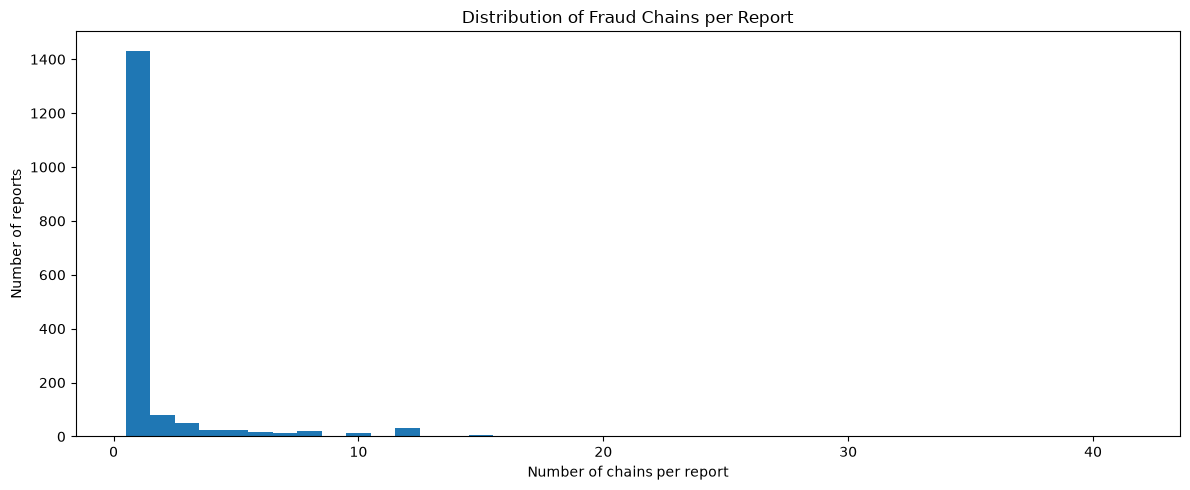

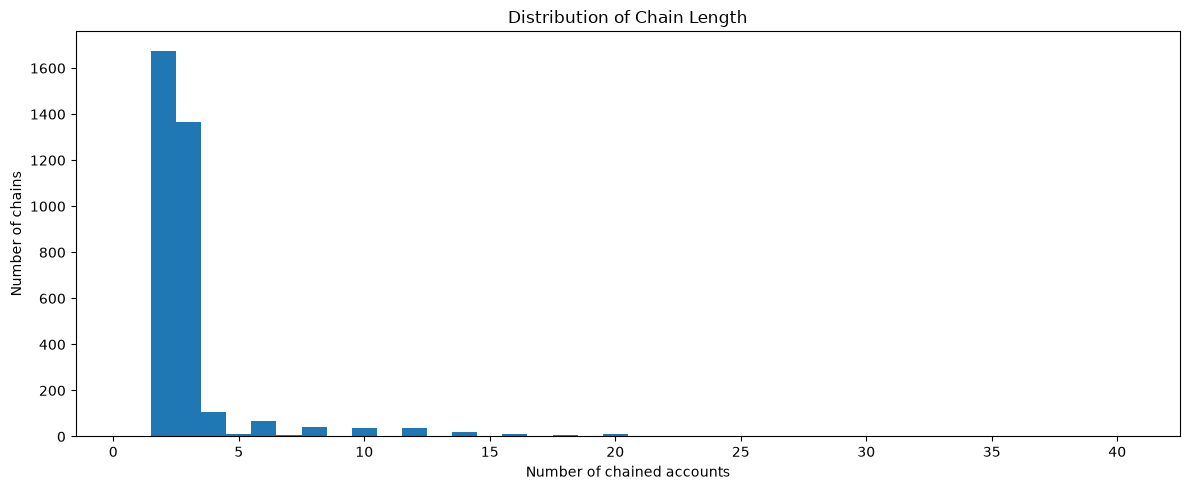

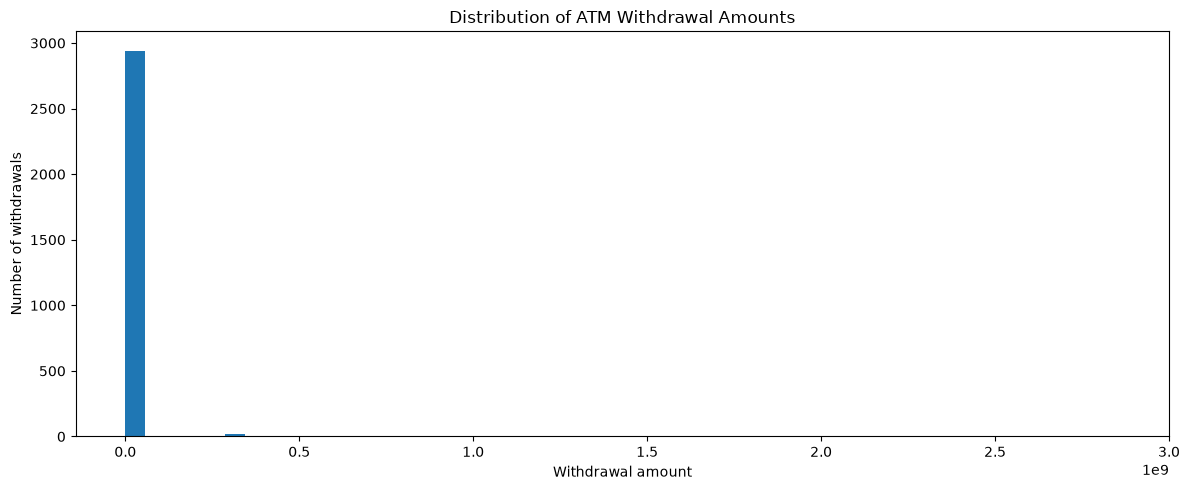

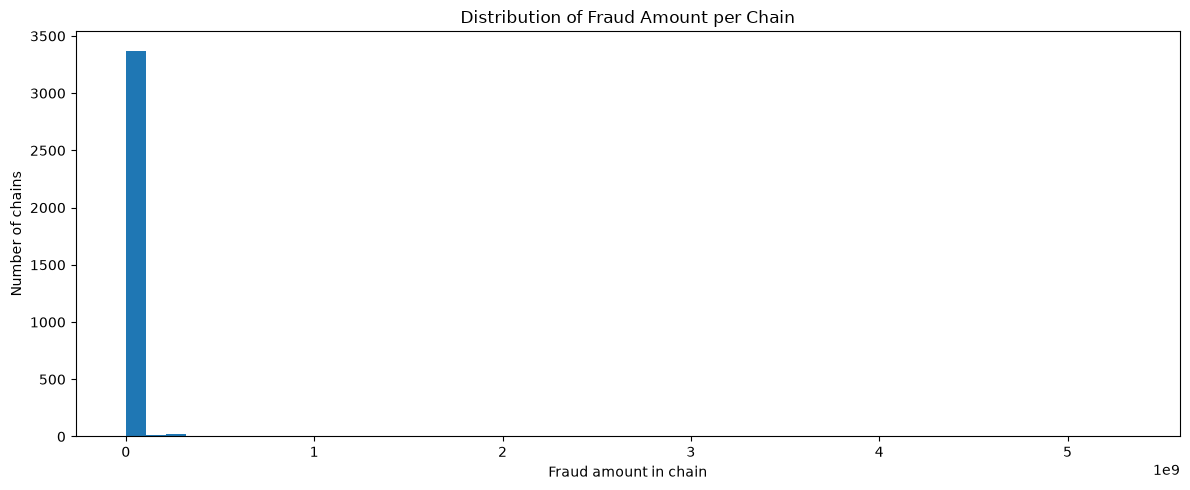

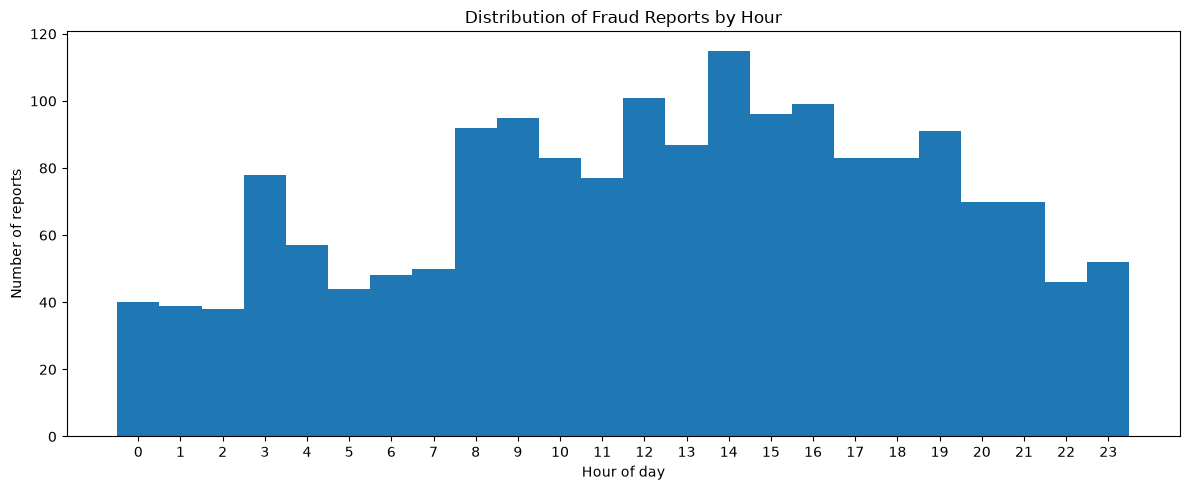

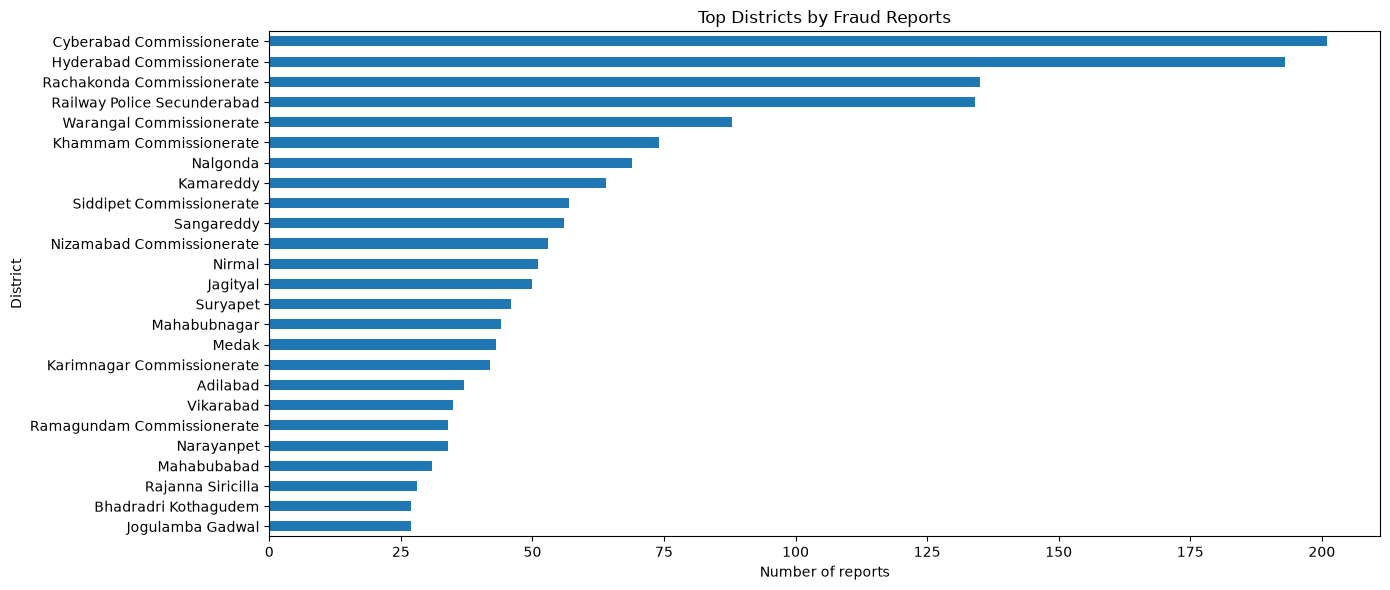

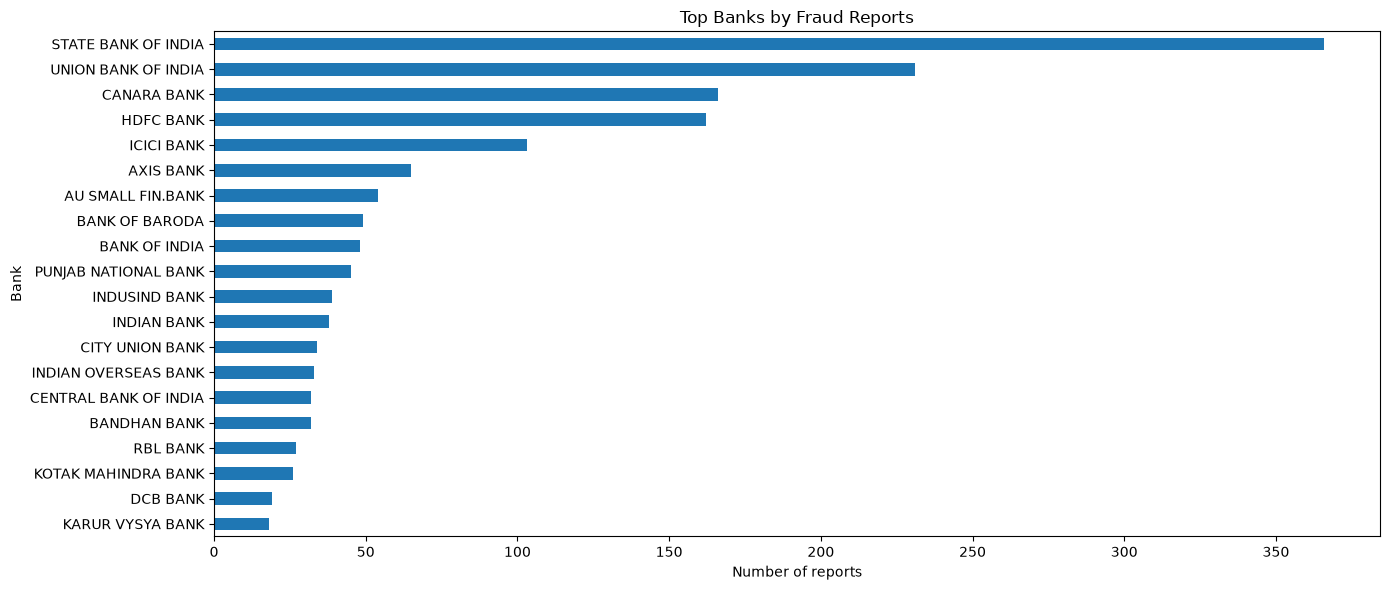

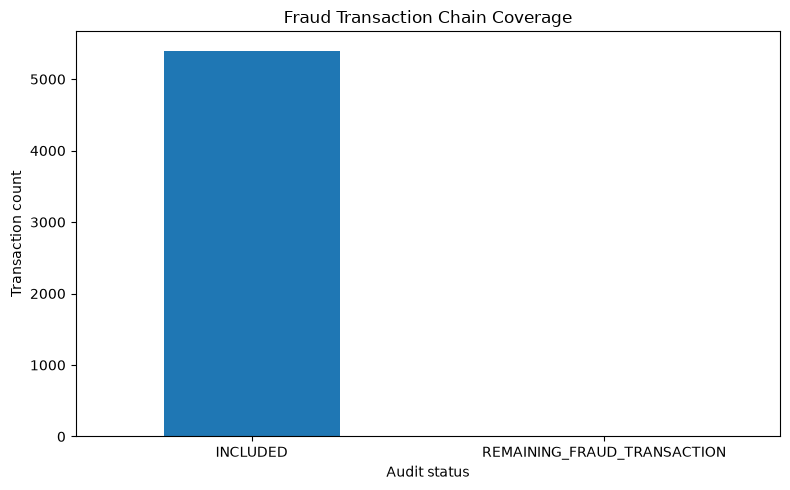

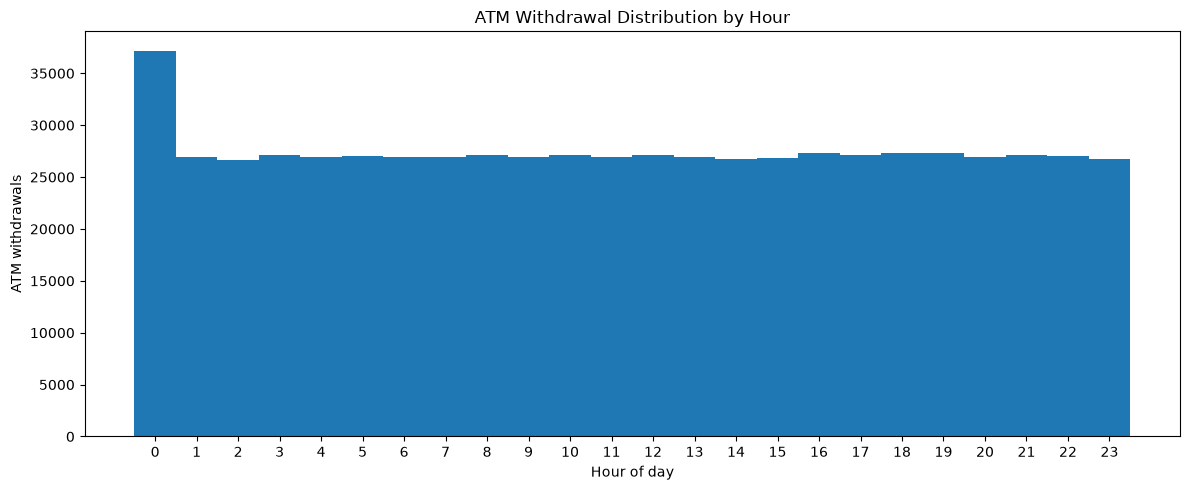

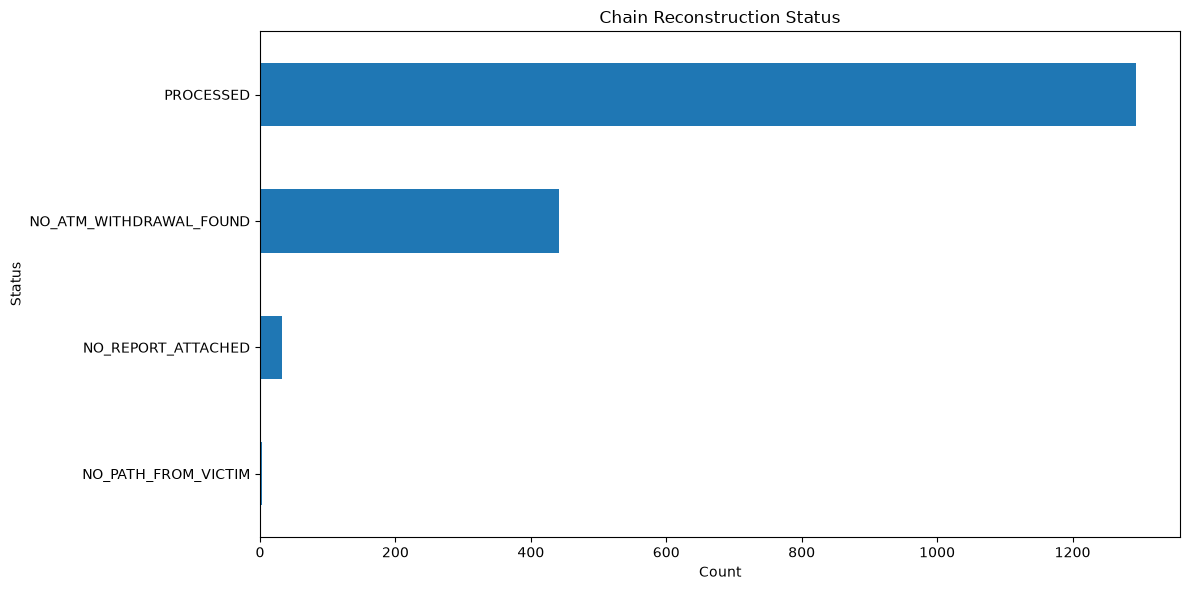


FILES CREATED
chains.csv                                     0.43 MB
chain_details.csv                              1.39 MB
chains.txt                                     3.45 MB
chain_transaction_audit.csv                    0.82 MB
remaining_fraud_transactions.csv               0.00 MB
chain_generation_log.csv                       0.11 MB
chain_unmatched_reports.csv                    0.00 MB
chain_unmatched_patterns.txt                   0.03 MB

CRITICAL AUDIT RESULT
⚠ SOME FRAUD-PATTERN TRANSACTIONS ARE NOT REPRESENTED IN THE RECONSTRUCTED CHAINS.
Remaining transactions: 10
Review file: .\final\remaining_fraud_transactions.csv

Done.


In [12]:
# ============================================================
# SIH26184 — EXHAUSTIVE FRAUD CHAIN RECONSTRUCTION & AUDIT
#
# INPUT:
#   final_transactions.csv
#   final_atm_trans.csv
#   reports.csv
#   patterns.txt
#   unknown_patterns.txt
#
# OUTPUT:
#   final/chains.csv
#   final/chain_details.csv
#   final/chains.txt
#   final/chain_transaction_audit.csv
#   final/remaining_fraud_transactions.csv
#   final/chain_generation_log.csv
#   final/chain_unmatched_reports.csv
#   final/chain_unmatched_patterns.txt
#
# ============================================================

import os
import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
from datetime import timedelta

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------

BASE_DIR = "."

FINAL_DIR = os.path.join(BASE_DIR, "final")
os.makedirs(FINAL_DIR, exist_ok=True)

FINAL_TRANSACTIONS = os.path.join(FINAL_DIR, "new_frauds.csv")
FINAL_ATM = os.path.join(FINAL_DIR, "final_atm_trans.csv")
REPORTS = os.path.join(FINAL_DIR, "reports.csv")

PATTERNS_FILE = os.path.join(BASE_DIR, "patterns.txt")
UNKNOWN_PATTERNS_FILE = os.path.join(BASE_DIR, "unknown_patterns.txt")

CHAINS_CSV = os.path.join(FINAL_DIR, "chains.csv")
CHAIN_DETAILS_CSV = os.path.join(FINAL_DIR, "chain_details.csv")
CHAINS_TXT = os.path.join(FINAL_DIR, "chains.txt")

AUDIT_CSV = os.path.join(FINAL_DIR, "chain_transaction_audit.csv")
REMAINING_FRAUD_CSV = os.path.join(
    FINAL_DIR, "remaining_fraud_transactions.csv"
)

GENERATION_LOG_CSV = os.path.join(
    FINAL_DIR, "chain_generation_log.csv"
)

UNMATCHED_REPORTS_CSV = os.path.join(
    FINAL_DIR, "chain_unmatched_reports.csv"
)

UNMATCHED_PATTERNS_TXT = os.path.join(
    FINAL_DIR, "chain_unmatched_patterns.txt"
)

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------

def normalize_columns(df):
    df = df.copy()
    df.columns = [
        str(c).replace("**", "").strip()
        for c in df.columns
    ]
    return df


def normalize_account(x):
    if pd.isna(x):
        return None
    return str(x).strip()


def normalize_payment_mode(x):
    if pd.isna(x):
        return None

    x = str(x).strip().upper()

    if x in {
        "ATM",
        "ATM WITHDRAWAL",
        "ATM_WITHDRAWAL",
        "CASH WITHDRAWAL"
    }:
        return "ATM"

    return x


def parse_timestamp(x):
    return pd.to_datetime(
        x,
        errors="coerce",
    )


def tx_key(timestamp, from_account, to_account):
    """
    User-specified unique transaction identity:
        timestamp + from_account + to_account
    """
    ts = pd.Timestamp(timestamp)

    if pd.isna(ts):
        return None

    return (
        ts,
        normalize_account(from_account),
        normalize_account(to_account)
    )


def format_ts(ts):
    if pd.isna(ts):
        return "UNKNOWN_TIME"

    return pd.Timestamp(ts).strftime("%Y/%m/%d %H:%M")


def safe_float(x):
    try:
        return float(x)
    except:
        return np.nan


# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------

print("=" * 80)
print("LOADING DATA")
print("=" * 80)

final_tx = normalize_columns(
    pd.read_csv(FINAL_TRANSACTIONS, low_memory=False)
)

atm_tx = normalize_columns(
    pd.read_csv(FINAL_ATM, low_memory=False)
)

reports = normalize_columns(
    pd.read_csv(REPORTS, low_memory=False)
)

print("Final transactions:", len(final_tx))
print("ATM transactions:", len(atm_tx))
print("Reports:", len(reports))


# ------------------------------------------------------------
# NORMALIZE TRANSACTION DATA
# ------------------------------------------------------------

final_tx["timestamp"] = final_tx["timestamp"].apply(parse_timestamp)
final_tx["from_account"] = final_tx["from_account"].apply(normalize_account)
final_tx["to_account"] = final_tx["to_account"].apply(normalize_account)

if "payment_mode" in final_tx.columns:
    final_tx["payment_mode"] = final_tx["payment_mode"].apply(
        normalize_payment_mode
    )

if "is_laundering" in final_tx.columns:
    final_tx["is_laundering"] = (
        final_tx["is_laundering"]
        .astype(str)
        .str.lower()
        .isin(["true", "1", "yes"])
    )


atm_tx["timestamp"] = atm_tx["timestamp"].apply(parse_timestamp)
atm_tx["account"] = atm_tx["account"].apply(normalize_account)
atm_tx["amount"] = pd.to_numeric(
    atm_tx["amount"],
    errors="coerce"
)

atm_tx["is_fraud"] = (
    atm_tx["is_fraud"]
    .astype(str)
    .str.lower()
    .isin(["true", "1", "yes"])
)


reports["reporting_timestamp"] = reports[
    "reporting_timestamp"
].apply(parse_timestamp)

reports["victim_account"] = reports[
    "victim_account"
].apply(normalize_account)

reports["amount_lost"] = pd.to_numeric(
    reports["amount_lost"],
    errors="coerce"
)


# ------------------------------------------------------------
# PARSE PATTERN FILES
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("PARSING PATTERN FILES")
print("=" * 80)


def parse_known_patterns(filepath):
    """
    Known format:

    BEGIN LAUNDERING ATTEMPT - TYPE: ...
    timestamp,id,sender_account,id,receiver_account,amount,currency,
    amount,currency,payment_mode,laundering
    END ...
    """

    patterns = []

    current = None
    pattern_counter = 0

    with open(filepath, "r", encoding="utf-8") as f:

        for raw in f:

            line = raw.strip()

            if not line:
                continue

            if line.startswith("BEGIN LAUNDERING ATTEMPT"):

                pattern_counter += 1

                current = {
                    "pattern_id": f"K{pattern_counter:05d}",
                    "source": "patterns.txt",
                    "header": line,
                    "rows": []
                }

                continue

            if line.startswith("END LAUNDERING ATTEMPT"):

                if current is not None:
                    patterns.append(current)

                current = None
                continue

            if current is not None:

                parts = [p.strip() for p in line.split(",")]

                if len(parts) >= 11:

                    timestamp = parse_timestamp(parts[0])

                    from_account = normalize_account(parts[2])
                    to_account = normalize_account(parts[4])

                    amount = safe_float(parts[5])

                    payment_mode = normalize_payment_mode(
                        parts[9]
                    )

                    laundering = str(parts[10]).lower() in {
                        "true",
                        "1",
                        "yes"
                    }

                    if (
                        pd.notna(timestamp)
                        and from_account
                        and to_account
                    ):

                        current["rows"].append({
                            "timestamp": timestamp,
                            "from_account": from_account,
                            "to_account": to_account,
                            "amount": amount,
                            "payment_mode": payment_mode,
                            "is_laundering": laundering,
                            "raw": line
                        })

    return patterns


def parse_unknown_patterns(filepath):

    """
    Unknown format:

    BEGIN LAUNDERING ATTEMPT - ...
    timestamp,from_bank,from_account,to_bank,to_account,
    amount,payment_mode,is_laundering,from_district,to_district
    """

    patterns = []

    current = None
    pattern_counter = 0

    with open(filepath, "r", encoding="utf-8") as f:

        for raw in f:

            line = raw.strip()

            if not line:
                continue

            if line.startswith("BEGIN LAUNDERING ATTEMPT"):

                pattern_counter += 1

                current = {
                    "pattern_id": f"U{pattern_counter:05d}",
                    "source": "unknown_patterns.txt",
                    "header": line,
                    "rows": []
                }

                continue

            if line.startswith("END LAUNDERING ATTEMPT"):

                if current is not None:
                    patterns.append(current)

                current = None
                continue

            if current is not None:

                parts = [p.strip() for p in line.split(",")]

                if len(parts) >= 10:

                    timestamp = parse_timestamp(parts[0])

                    from_account = normalize_account(parts[2])
                    to_account = normalize_account(parts[4])

                    amount = safe_float(parts[5])

                    payment_mode = normalize_payment_mode(
                        parts[6]
                    )

                    laundering = str(parts[7]).lower() in {
                        "true",
                        "1",
                        "yes"
                    }

                    from_district = parts[8]
                    to_district = parts[9]

                    if (
                        pd.notna(timestamp)
                        and from_account
                        and to_account
                    ):

                        current["rows"].append({
                            "timestamp": timestamp,
                            "from_account": from_account,
                            "to_account": to_account,
                            "amount": amount,
                            "payment_mode": payment_mode,
                            "is_laundering": laundering,
                            "from_district": from_district,
                            "to_district": to_district,
                            "raw": line
                        })

    return patterns


known_patterns = parse_known_patterns(PATTERNS_FILE)
unknown_patterns = parse_unknown_patterns(UNKNOWN_PATTERNS_FILE)

print("Known patterns:", len(known_patterns))
print("Unknown patterns:", len(unknown_patterns))


# ------------------------------------------------------------
# DEDUPLICATE PATTERNS
# KNOWN PATTERNS HAVE PRIORITY
# ------------------------------------------------------------

def pattern_signature(pattern):

    edges = []

    for r in pattern["rows"]:

        edges.append(
            (
                pd.Timestamp(r["timestamp"]),
                r["from_account"],
                r["to_account"]
            )
        )

    return tuple(sorted(edges))


known_signatures = {
    pattern_signature(p)
    for p in known_patterns
}

all_patterns = []

for p in known_patterns:
    p = dict(p)
    p["priority"] = 1
    all_patterns.append(p)

unknown_skipped = []

for p in unknown_patterns:

    sig = pattern_signature(p)

    if sig in known_signatures:

        unknown_skipped.append(p)

    else:

        p = dict(p)
        p["priority"] = 2
        all_patterns.append(p)


print("Accepted patterns:", len(all_patterns))
print("Skipped duplicate unknown patterns:", len(unknown_skipped))


# ------------------------------------------------------------
# BUILD GLOBAL TRANSACTION INDEX
# ------------------------------------------------------------

print("\nBuilding transaction indexes...")

final_tx_index = defaultdict(list)

for idx, row in final_tx.iterrows():

    key = tx_key(
        row["timestamp"],
        row["from_account"],
        row["to_account"]
    )

    if key is not None:
        final_tx_index[key].append(idx)


# ------------------------------------------------------------
# BUILD ATM INDEX
# ------------------------------------------------------------

atm_by_account = defaultdict(list)

for idx, row in atm_tx.iterrows():

    if (
        pd.notna(row["timestamp"])
        and row["account"]
    ):

        atm_by_account[row["account"]].append({
            "idx": idx,
            "timestamp": row["timestamp"],
            "amount": row["amount"],
            "bank": row.get("bank", None),
            "district": row.get("district", None),
            "is_fraud": row.get("is_fraud", False)
        })


for account in atm_by_account:
    atm_by_account[account].sort(
        key=lambda x: x["timestamp"]
    )


# ------------------------------------------------------------
# REPORT MATCHING
# ------------------------------------------------------------
#
# A report belongs to a pattern when:
#
#   victim account matches a source node
#   AND report timestamp occurs after chain end
#   AND amount_lost is compatible with victim's outgoing amount
#
# We first calculate candidates.
# ------------------------------------------------------------

def get_graph(pattern):

    edges = []

    for r in pattern["rows"]:

        edges.append({
            "timestamp": r["timestamp"],
            "from_account": r["from_account"],
            "to_account": r["to_account"],
            "amount": r["amount"],
            "payment_mode": r["payment_mode"],
            "is_laundering": r["is_laundering"],
            "raw": r["raw"]
        })

    return edges


def get_source_nodes(edges):

    nodes = set()
    incoming = set()

    for e in edges:

        nodes.add(e["from_account"])
        nodes.add(e["to_account"])

        incoming.add(e["to_account"])

    return sorted(nodes - incoming)


def get_terminal_nodes(edges):

    nodes = set()
    outgoing = set()

    for e in edges:

        nodes.add(e["from_account"])
        nodes.add(e["to_account"])

        outgoing.add(e["from_account"])

    return sorted(nodes - outgoing)


def outgoing_amount(edges, account):

    return sum(
        e["amount"]
        for e in edges
        if e["from_account"] == account
        and pd.notna(e["amount"])
    )


# ------------------------------------------------------------
# PREPARE PATTERN METADATA
# ------------------------------------------------------------

pattern_meta = []

for pattern in all_patterns:

    edges = get_graph(pattern)

    if not edges:
        continue

    sources = get_source_nodes(edges)
    terminals = get_terminal_nodes(edges)

    chain_end = max(
        e["timestamp"]
        for e in edges
    )

    source_loss = {
        s: outgoing_amount(edges, s)
        for s in sources
    }

    pattern_meta.append({
        "pattern": pattern,
        "edges": edges,
        "sources": sources,
        "terminals": terminals,
        "chain_end": chain_end,
        "source_loss": source_loss
    })


print("Pattern metadata prepared:", len(pattern_meta))


# ------------------------------------------------------------
# MATCH REPORTS TO PATTERNS
# ------------------------------------------------------------

report_candidates = []

for ridx, report in reports.iterrows():

    victim = report["victim_account"]
    amount_lost = report["amount_lost"]
    report_time = report["reporting_timestamp"]

    candidates = []

    for meta in pattern_meta:

        if victim not in meta["sources"]:
            continue

        # Report must happen after the fraud chain
        if (
            pd.notna(report_time)
            and report_time < meta["chain_end"]
        ):
            continue

        pattern_loss = meta["source_loss"].get(
            victim,
            np.nan
        )

        # Amount compatibility
        amount_match = False

        if (
            pd.notna(amount_lost)
            and pd.notna(pattern_loss)
        ):

            tolerance = max(
                0.01,
                abs(pattern_loss) * 0.01
            )

            amount_match = (
                abs(amount_lost - pattern_loss)
                <= tolerance
            )

        # Score candidate
        score = 0

        if amount_match:
            score += 100

        if victim in meta["sources"]:
            score += 50

        if pd.notna(report_time):
            delay = (
                report_time - meta["chain_end"]
            ).total_seconds() / 60

            if 0 <= delay <= 60:
                score += 20

        candidates.append({
            "pattern_id": meta["pattern"]["pattern_id"],
            "source": meta["pattern"]["source"],
            "score": score,
            "amount_match": amount_match,
            "chain_end": meta["chain_end"]
        })

    candidates.sort(
        key=lambda x: (
            x["score"],
            x["chain_end"]
        ),
        reverse=True
    )

    report_candidates.append({
        "report_index": ridx,
        "report_id": report["report_id"],
        "victim_account": victim,
        "candidates": candidates
    })


# ------------------------------------------------------------
# SELECT BEST REPORT → PATTERN MATCH
# ------------------------------------------------------------

report_to_pattern = {}
unmatched_reports = []

for item in report_candidates:

    if not item["candidates"]:

        unmatched_reports.append({
            "report_id": item["report_id"],
            "victim_account": item["victim_account"],
            "reason": "NO_PATTERN_CANDIDATE"
        })

        continue

    best = item["candidates"][0]

    report_to_pattern[item["report_id"]] = best[
        "pattern_id"
    ]


print(
    "Reports matched to patterns:",
    len(report_to_pattern)
)

print(
    "Unmatched reports:",
    len(unmatched_reports)
)


# ------------------------------------------------------------
# IMPORTANT:
# A REPORT CAN CORRESPOND TO MULTIPLE BRANCHES
#
# We now reconstruct ALL source-to-terminal paths.
# ------------------------------------------------------------

def build_adjacency(edges):

    adjacency = defaultdict(list)

    for e in edges:

        adjacency[e["from_account"]].append(e)

    for node in adjacency:

        adjacency[node].sort(
            key=lambda x: x["timestamp"]
        )

    return adjacency


def enumerate_paths(edges, source):

    """
    Exhaustively enumerate directed paths from a source
    to every terminal node.

    Each edge is represented by its unique:
        timestamp + from + to

    DFS is used because patterns are transaction graphs.
    """

    adjacency = build_adjacency(edges)

    results = []

    def dfs(
        current,
        path_edges,
        visited_nodes
    ):

        outgoing = adjacency.get(
            current,
            []
        )

        if not outgoing:

            results.append(
                list(path_edges)
            )

            return

        for edge in outgoing:

            target = edge["to_account"]

            # Protect against accidental cycles
            if target in visited_nodes:
                continue

            dfs(
                target,
                path_edges + [edge],
                visited_nodes | {target}
            )

    dfs(
        source,
        [],
        {source}
    )

    return results


# ------------------------------------------------------------
# MAP PATTERN → REPORTS
# ------------------------------------------------------------

pattern_to_reports = defaultdict(list)

for report_id, pattern_id in report_to_pattern.items():

    pattern_to_reports[pattern_id].append(
        report_id
    )


# ------------------------------------------------------------
# RECONSTRUCT CHAINS
# ------------------------------------------------------------

chains = []
chain_details = []
generation_log = []

represented_transactions = set()

chain_counter = 0


def find_withdrawal(
    terminal_account,
    chain_end,
    max_minutes=60
):

    """
    Find the first ATM withdrawal belonging to the
    terminal account after the fraud chain.

    Preference:
      1. fraudulent ATM
      2. closest ATM
      3. within one hour
    """

    candidates = atm_by_account.get(
        terminal_account,
        []
    )

    valid = []

    for atm in candidates:

        if atm["timestamp"] < chain_end:
            continue

        delay = (
            atm["timestamp"] - chain_end
        ).total_seconds() / 60

        if delay < 0 or delay > max_minutes:
            continue

        valid.append(
            (atm, delay)
        )

    if not valid:
        return None

    valid.sort(
        key=lambda x: (
            not x[0]["is_fraud"],
            x[1]
        )
    )

    return valid[0]


# ------------------------------------------------------------
# PROCESS EACH PATTERN
# ------------------------------------------------------------

for meta in pattern_meta:

    pattern = meta["pattern"]
    edges = meta["edges"]
    sources = meta["sources"]
    terminals = meta["terminals"]

    pattern_id = pattern["pattern_id"]

    associated_reports = pattern_to_reports.get(
        pattern_id,
        []
    )

    if not associated_reports:

        generation_log.append({
            "pattern_id": pattern_id,
            "source": pattern["source"],
            "status": "NO_REPORT_ATTACHED",
            "reports": 0,
            "sources": len(sources),
            "terminals": len(terminals),
            "chains": 0
        })

        continue

    pattern_chain_count = 0

    for report_id in associated_reports:

        report_row = reports[
            reports["report_id"] == report_id
        ]

        if report_row.empty:
            continue

        report = report_row.iloc[0]

        victim = report["victim_account"]

        # ----------------------------------------------------
        # Paths from this victim
        # ----------------------------------------------------

        paths = enumerate_paths(
            edges,
            victim
        )

        # If the graph has no path, log it.
        if not paths:

            generation_log.append({
                "pattern_id": pattern_id,
                "source": pattern["source"],
                "report_id": report_id,
                "status": "NO_PATH_FROM_VICTIM",
                "sources": len(sources),
                "terminals": len(terminals),
                "chains": 0
            })

            continue

        # ----------------------------------------------------
        # Each path becomes one chain row
        # ----------------------------------------------------

        for path in paths:

            if not path:
                continue

            chain_counter += 1
            pattern_chain_count += 1

            first_account = path[0]["from_account"]

            terminal_account = path[-1]["to_account"]

            fraud_amount = sum(
                e["amount"]
                for e in path
                if pd.notna(e["amount"])
            )

            chain_end = path[-1]["timestamp"]

            # ------------------------------------------------
            # Mark fraud transactions represented
            # ------------------------------------------------

            for e in path:

                represented_transactions.add(
                    tx_key(
                        e["timestamp"],
                        e["from_account"],
                        e["to_account"]
                    )
                )

            # ------------------------------------------------
            # Find ATM withdrawal
            # ------------------------------------------------

            withdrawal = find_withdrawal(
                terminal_account,
                chain_end
            )

            atm_timestamp = None
            atm_amount = None
            atm_bank = None
            atm_district = None
            atm_idx = None

            if withdrawal:

                atm = withdrawal[0]

                atm_timestamp = atm["timestamp"]
                atm_amount = atm["amount"]
                atm_bank = atm["bank"]
                atm_district = atm["district"]
                atm_idx = atm["idx"]

            # ------------------------------------------------
            # chains.csv
            # ------------------------------------------------

            chain_text = first_account

            for e in path:
                chain_text += (
                    f" -> {e['to_account']}"
                )

            if withdrawal:
                chain_text += (
                    f" -> ATM "
                    f"({atm_amount:.2f})"
                    if pd.notna(atm_amount)
                    else " -> ATM"
                )

            chains.append({
                "chain_id": chain_counter,
                "report_id": report_id,
                "pattern_id": pattern_id,
                "chained_account_count": len(path) + 1,
                "chain": chain_text,
                "victim_account": victim,
                "terminal_account": terminal_account,
                "fraud_amount": fraud_amount,
                "withdrawal_amount": atm_amount,
                "withdrawal_timestamp": atm_timestamp
            })

            # ------------------------------------------------
            # chain_details.csv
            #
            # One row per transaction inside the chain.
            # This gives us precise auditability.
            # ------------------------------------------------

            for seq, e in enumerate(path, start=1):

                chain_details.append({
                    "chain_id": chain_counter,
                    "report_id": report_id,
                    "pattern_id": pattern_id,
                    "sequence": seq,
                    "timestamp": e["timestamp"],
                    "from_account": e["from_account"],
                    "to_account": e["to_account"],
                    "amount": e["amount"],
                    "payment_mode": e["payment_mode"],
                    "is_laundering": e["is_laundering"],
                    "transaction_key": str(
                        tx_key(
                            e["timestamp"],
                            e["from_account"],
                            e["to_account"]
                        )
                    ),
                    "is_atm_withdrawal": False
                })

            # ------------------------------------------------
            # Add ATM transaction to chain details
            # ------------------------------------------------

            if withdrawal:

                chain_details.append({
                    "chain_id": chain_counter,
                    "report_id": report_id,
                    "pattern_id": pattern_id,
                    "sequence": len(path) + 1,
                    "timestamp": atm_timestamp,
                    "from_account": terminal_account,
                    "to_account": "ATM",
                    "amount": atm_amount,
                    "payment_mode": "ATM",
                    "is_laundering": True,
                    "transaction_key": (
                        f"ATM|{atm_timestamp}|"
                        f"{terminal_account}"
                    ),
                    "is_atm_withdrawal": True
                })

            else:

                generation_log.append({
                    "pattern_id": pattern_id,
                    "source": pattern["source"],
                    "report_id": report_id,
                    "chain_id": chain_counter,
                    "status": "NO_ATM_WITHDRAWAL_FOUND",
                    "terminal_account": terminal_account,
                    "chain_end": chain_end,
                    "sources": len(sources),
                    "terminals": len(terminals)
                })

    generation_log.append({
        "pattern_id": pattern_id,
        "source": pattern["source"],
        "status": "PROCESSED",
        "reports": len(associated_reports),
        "sources": len(sources),
        "terminals": len(terminals),
        "chains": pattern_chain_count
    })


# ------------------------------------------------------------
# CREATE DATAFRAMES
# ------------------------------------------------------------

chains_df = pd.DataFrame(chains)

chain_details_df = pd.DataFrame(
    chain_details
)

generation_log_df = pd.DataFrame(
    generation_log
)

unmatched_reports_df = pd.DataFrame(
    unmatched_reports
)


# ------------------------------------------------------------
# SAVE MAIN OUTPUTS
# ------------------------------------------------------------

chains_df.to_csv(
    CHAINS_CSV,
    index=False
)

chain_details_df.to_csv(
    CHAIN_DETAILS_CSV,
    index=False
)

generation_log_df.to_csv(
    GENERATION_LOG_CSV,
    index=False
)

unmatched_reports_df.to_csv(
    UNMATCHED_REPORTS_CSV,
    index=False
)


# ------------------------------------------------------------
# GENERATE HUMAN-READABLE chains.txt
# ------------------------------------------------------------

print("\nWriting chains.txt...")

with open(
    CHAINS_TXT,
    "w",
    encoding="utf-8"
) as f:

    for pattern_id in [
        p["pattern_id"]
        for p in all_patterns
    ]:

        pattern = next(
            (
                p for p in all_patterns
                if p["pattern_id"] == pattern_id
            ),
            None
        )

        if pattern is None:
            continue

        pattern_rows = [
            r for r in chain_details
            if r["pattern_id"] == pattern_id
        ]

        if not pattern_rows:
            continue

        report_ids = sorted(
            set(
                r["report_id"]
                for r in pattern_rows
            )
        )

        f.write("\n")
        f.write("=" * 100 + "\n")
        f.write(
            f"PATTERN ID: {pattern_id}\n"
        )
        f.write(
            f"SOURCE: {pattern['source']}\n"
        )
        f.write(
            f"ORIGINAL PATTERN: {pattern['header']}\n"
        )
        f.write(
            f"REPORT IDS: {', '.join(map(str, report_ids))}\n"
        )
        f.write("=" * 100 + "\n")

        # ----------------------------------------------------
        # Write every chain
        # ----------------------------------------------------

        pattern_chain_ids = sorted(
            set(
                r["chain_id"]
                for r in pattern_rows
            )
        )

        for cid in pattern_chain_ids:

            chain_row = chains_df[
                chains_df["chain_id"] == cid
            ]

            if chain_row.empty:
                continue

            chain_row = chain_row.iloc[0]

            f.write("\n")
            f.write(
                f"CHAIN {cid}\n"
            )
            f.write(
                f"Report ID: {chain_row['report_id']}\n"
            )
            f.write(
                f"Accounts: "
                f"{chain_row['chain']}\n"
            )
            f.write(
                f"Chained accounts: "
                f"{chain_row['chained_account_count']}\n"
            )

            f.write("-" * 100 + "\n")

            details = chain_details_df[
                chain_details_df["chain_id"] == cid
            ].sort_values("sequence")

            for _, r in details.iterrows():

                if r["is_atm_withdrawal"]:

                    f.write(
                        f"{format_ts(r['timestamp'])} | "
                        f"{r['from_account']} -> ATM | "
                        f"WITHDRAWAL = {r['amount']:.2f}\n"
                    )

                else:

                    f.write(
                        f"{format_ts(r['timestamp'])} | "
                        f"{r['from_account']} -> "
                        f"{r['to_account']} | "
                        f"AMOUNT = {r['amount']:.2f} | "
                        f"MODE = {r['payment_mode']}\n"
                    )

            f.write("-" * 100 + "\n")

        # ----------------------------------------------------
        # ORIGINAL PATTERN BLOCK
        # ----------------------------------------------------

        f.write("\n")
        f.write("ORIGINAL PATTERN TRANSACTIONS\n")
        f.write("-" * 100 + "\n")

        for r in pattern["rows"]:

            f.write(
                r["raw"] + "\n"
            )

        f.write("-" * 100 + "\n")
        f.write(
            f"END PATTERN {pattern_id}\n"
        )
        f.write("=" * 100 + "\n")


# ============================================================
# EXHAUSTIVE FRAUD TRANSACTION AUDIT
# ============================================================

print("\n" + "=" * 80)
print("EXHAUSTIVE FRAUD TRANSACTION AUDIT")
print("=" * 80)


# ------------------------------------------------------------
# Build authoritative fraud transaction set
#
# Every transaction appearing inside accepted patterns
# is considered a fraud-pattern transaction.
# ------------------------------------------------------------

pattern_transactions = {}

for pattern in all_patterns:

    for r in pattern["rows"]:

        key = tx_key(
            r["timestamp"],
            r["from_account"],
            r["to_account"]
        )

        if key is None:
            continue

        pattern_transactions[key] = {
            "pattern_id": pattern["pattern_id"],
            "source": pattern["source"],
            "timestamp": r["timestamp"],
            "from_account": r["from_account"],
            "to_account": r["to_account"],
            "amount": r["amount"],
            "payment_mode": r["payment_mode"]
        }


# ------------------------------------------------------------
# Determine whether each fraud transaction appeared
# in at least one reconstructed chain.
# ------------------------------------------------------------

audit_rows = []

for key, info in pattern_transactions.items():

    included = key in represented_transactions

    audit_rows.append({
        "transaction_key": str(key),
        "pattern_id": info["pattern_id"],
        "source": info["source"],
        "timestamp": info["timestamp"],
        "from_account": info["from_account"],
        "to_account": info["to_account"],
        "amount": info["amount"],
        "payment_mode": info["payment_mode"],
        "included_in_chain": included,
        "status": (
            "INCLUDED"
            if included
            else "REMAINING_FRAUD_TRANSACTION"
        )
    })


audit_df = pd.DataFrame(
    audit_rows
)

audit_df.to_csv(
    AUDIT_CSV,
    index=False
)


# ------------------------------------------------------------
# REMAINING FRAUD TRANSACTIONS
# ------------------------------------------------------------

remaining_fraud = audit_df[
    ~audit_df["included_in_chain"]
].copy()

remaining_fraud.to_csv(
    REMAINING_FRAUD_CSV,
    index=False
)


# ============================================================
# UNMATCHED PATTERNS
# ============================================================

patterns_with_chains = set(
    chains_df["pattern_id"].unique()
) if not chains_df.empty else set()

unmatched_patterns = [
    p for p in all_patterns
    if p["pattern_id"] not in patterns_with_chains
]

with open(
    UNMATCHED_PATTERNS_TXT,
    "w",
    encoding="utf-8"
) as f:

    for p in unmatched_patterns:

        f.write("=" * 100 + "\n")
        f.write(
            f"PATTERN ID: {p['pattern_id']}\n"
        )
        f.write(
            f"SOURCE: {p['source']}\n"
        )
        f.write(
            f"HEADER: {p['header']}\n"
        )
        f.write("-" * 100 + "\n")

        for r in p["rows"]:
            f.write(r["raw"] + "\n")

        f.write("=" * 100 + "\n\n")


# ============================================================
# VALIDATION SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("CHAIN RECONSTRUCTION SUMMARY")
print("=" * 80)

print(
    f"Accepted patterns              : {len(all_patterns):,}"
)

print(
    f"Patterns with reconstructed chains : "
    f"{len(patterns_with_chains):,}"
)

print(
    f"Unmatched patterns             : "
    f"{len(unmatched_patterns):,}"
)

print(
    f"Reports                        : "
    f"{len(reports):,}"
)

print(
    f"Reports matched to patterns   : "
    f"{len(report_to_pattern):,}"
)

print(
    f"Unmatched reports              : "
    f"{len(unmatched_reports):,}"
)

print(
    f"Chains generated               : "
    f"{len(chains_df):,}"
)

print(
    f"Chain transaction rows         : "
    f"{len(chain_details_df):,}"
)

print(
    f"Fraud transactions in patterns: "
    f"{len(pattern_transactions):,}"
)

print(
    f"Fraud transactions represented : "
    f"{len(represented_transactions):,}"
)

print(
    f"Fraud transactions remaining   : "
    f"{len(remaining_fraud):,}"
)

if len(pattern_transactions) > 0:

    coverage = (
        len(represented_transactions)
        / len(pattern_transactions)
        * 100
    )

    print(
        f"Fraud transaction coverage     : "
        f"{coverage:.4f}%"
    )

else:

    coverage = 0

    print(
        "Fraud transaction coverage     : 0%"
    )


# ============================================================
# CHAIN BRANCHING ANALYSIS
# ============================================================

if not chains_df.empty:

    chain_count_distribution = (
        chains_df[
            "chained_account_count"
        ]
        .value_counts()
        .sort_index()
    )

    print("\nChained-account distribution:")
    print(
        chain_count_distribution
    )


# ============================================================
# VISUALIZATION
# ============================================================

print("\n" + "=" * 80)
print("GENERATING VISUALIZATIONS")
print("=" * 80)


# ------------------------------------------------------------
# 1. Chains per report
# ------------------------------------------------------------

if not chains_df.empty:

    chains_per_report = (
        chains_df
        .groupby("report_id")
        .size()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(12, 5))

    plt.hist(
        chains_per_report.values,
        bins=range(
            1,
            int(chains_per_report.max()) + 2
        ),
        align="left"
    )

    plt.xlabel("Number of chains per report")
    plt.ylabel("Number of reports")
    plt.title(
        "Distribution of Fraud Chains per Report"
    )

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 2. Chain length
# ------------------------------------------------------------

if not chains_df.empty:

    plt.figure(figsize=(12, 5))

    plt.hist(
        chains_df["chained_account_count"],
        bins=range(
            1,
            int(
                chains_df[
                    "chained_account_count"
                ].max()
            ) + 2
        ),
        align="left"
    )

    plt.xlabel("Number of chained accounts")
    plt.ylabel("Number of chains")
    plt.title(
        "Distribution of Chain Length"
    )

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 3. Withdrawal amounts
# ------------------------------------------------------------

if not chains_df.empty:

    withdrawal_amounts = pd.to_numeric(
        chains_df["withdrawal_amount"],
        errors="coerce"
    ).dropna()

    if len(withdrawal_amounts):

        plt.figure(figsize=(12, 5))

        plt.hist(
            withdrawal_amounts,
            bins=50
        )

        plt.xlabel("Withdrawal amount")
        plt.ylabel("Number of withdrawals")
        plt.title(
            "Distribution of ATM Withdrawal Amounts"
        )

        plt.tight_layout()
        plt.show()


# ------------------------------------------------------------
# 4. Fraud amount
# ------------------------------------------------------------

if not chains_df.empty:

    fraud_amounts = pd.to_numeric(
        chains_df["fraud_amount"],
        errors="coerce"
    ).dropna()

    if len(fraud_amounts):

        plt.figure(figsize=(12, 5))

        plt.hist(
            fraud_amounts,
            bins=50
        )

        plt.xlabel("Fraud amount in chain")
        plt.ylabel("Number of chains")
        plt.title(
            "Distribution of Fraud Amount per Chain"
        )

        plt.tight_layout()
        plt.show()


# ------------------------------------------------------------
# 5. Reports by hour
# ------------------------------------------------------------

if not reports.empty:

    report_hours = (
        reports["reporting_timestamp"]
        .dropna()
        .dt.hour
    )

    plt.figure(figsize=(12, 5))

    plt.hist(
        report_hours,
        bins=range(25),
        align="left"
    )

    plt.xlabel("Hour of day")
    plt.ylabel("Number of reports")
    plt.title(
        "Distribution of Fraud Reports by Hour"
    )

    plt.xticks(range(24))

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 6. Reports by district
# ------------------------------------------------------------

if (
    not reports.empty
    and "district" in reports.columns
):

    district_counts = (
        reports["district"]
        .fillna("UNKNOWN")
        .value_counts()
        .head(25)
    )

    plt.figure(figsize=(14, 6))

    district_counts.sort_values().plot(
        kind="barh"
    )

    plt.xlabel("Number of reports")
    plt.ylabel("District")
    plt.title(
        "Top Districts by Fraud Reports"
    )

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 7. Reports by bank
# ------------------------------------------------------------

if (
    not reports.empty
    and "bank" in reports.columns
):

    bank_counts = (
        reports["bank"]
        .fillna("UNKNOWN")
        .value_counts()
        .head(20)
    )

    plt.figure(figsize=(14, 6))

    bank_counts.sort_values().plot(
        kind="barh"
    )

    plt.xlabel("Number of reports")
    plt.ylabel("Bank")
    plt.title(
        "Top Banks by Fraud Reports"
    )

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 8. Fraud transaction audit
# ------------------------------------------------------------

if not audit_df.empty:

    audit_counts = audit_df[
        "status"
    ].value_counts()

    plt.figure(figsize=(8, 5))

    audit_counts.plot(
        kind="bar"
    )

    plt.xlabel("Audit status")
    plt.ylabel("Transaction count")
    plt.title(
        "Fraud Transaction Chain Coverage"
    )

    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 9. ATM withdrawals by hour
# ------------------------------------------------------------

if not atm_tx.empty:

    atm_hours = (
        atm_tx["timestamp"]
        .dropna()
        .dt.hour
    )

    plt.figure(figsize=(12, 5))

    plt.hist(
        atm_hours,
        bins=range(25),
        align="left"
    )

    plt.xlabel("Hour of day")
    plt.ylabel("ATM withdrawals")
    plt.title(
        "ATM Withdrawal Distribution by Hour"
    )

    plt.xticks(range(24))

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 10. Chain generation status
# ------------------------------------------------------------

if not generation_log_df.empty:

    status_counts = (
        generation_log_df[
            "status"
        ]
        .value_counts()
    )

    plt.figure(figsize=(12, 6))

    status_counts.sort_values().plot(
        kind="barh"
    )

    plt.xlabel("Count")
    plt.ylabel("Status")
    plt.title(
        "Chain Reconstruction Status"
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# FINAL FILE VALIDATION
# ============================================================

print("\n" + "=" * 80)
print("FILES CREATED")
print("=" * 80)

for path in [
    CHAINS_CSV,
    CHAIN_DETAILS_CSV,
    CHAINS_TXT,
    AUDIT_CSV,
    REMAINING_FRAUD_CSV,
    GENERATION_LOG_CSV,
    UNMATCHED_REPORTS_CSV,
    UNMATCHED_PATTERNS_TXT
]:

    if os.path.exists(path):

        size_mb = (
            os.path.getsize(path)
            / (1024 * 1024)
        )

        print(
            f"{os.path.basename(path):40s} "
            f"{size_mb:10.2f} MB"
        )


# ============================================================
# CRITICAL AUDIT RESULT
# ============================================================

print("\n" + "=" * 80)
print("CRITICAL AUDIT RESULT")
print("=" * 80)

if len(remaining_fraud) == 0:

    print(
        "✓ ALL FRAUD-PATTERN TRANSACTIONS ARE REPRESENTED "
        "IN AT LEAST ONE RECONSTRUCTED CHAIN."
    )

else:

    print(
        "⚠ SOME FRAUD-PATTERN TRANSACTIONS ARE NOT "
        "REPRESENTED IN THE RECONSTRUCTED CHAINS."
    )

    print(
        f"Remaining transactions: "
        f"{len(remaining_fraud):,}"
    )

    print(
        f"Review file: "
        f"{REMAINING_FRAUD_CSV}"      
    )

print("\nDone.")

In [14]:
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import timedelta
import hashlib

BASE = Path("final")

TX_FILE = BASE / "final_transactions.csv"
ATM_FILE = BASE / "final_atm_trans.csv"
REPORT_FILE = BASE / "reports.csv"
LOG_FILE = BASE / "chain_generation_log.csv"
DETAIL_FILE = BASE / "chain_details.csv"

# ============================================================
# 1. LOAD CURRENT CHAIN RESULTS
# ============================================================

log = pd.read_csv(LOG_FILE, dtype=str)
details = pd.read_csv(DETAIL_FILE, dtype=str)

print("Current chain statuses:")
print(log["status"].value_counts())


# ============================================================
# 2. IDENTIFY CHAINS THAT NEED SYNTHETIC DATA
# ============================================================

no_atm = log[
    log["status"].eq("NO_ATM_WITHDRAWAL_FOUND")
].copy()

no_report = log[
    log["status"].eq("NO_REPORT_ATTACHED")
].copy()

no_path = log[
    log["status"].eq("NO_PATH_FROM_VICTIM")
].copy()

print("\nChains requiring synthetic ATM:", len(no_atm))
print("Chains requiring synthetic reports:", len(no_report))
print("Chains with no valid path:", len(no_path))


# ============================================================
# 3. HELPER TO GENERATE DETERMINISTIC RANDOM VALUES
# ============================================================

def stable_seed(value):
    """
    Generates a deterministic integer seed from a string.
    Same chain_id -> same synthetic values every run.
    """
    h = hashlib.sha256(str(value).encode()).hexdigest()
    return int(h[:8], 16)


def get_rng(chain_id):
    return np.random.default_rng(stable_seed(chain_id))


# ============================================================
# 4. LOAD CHAIN TRANSACTION DETAILS
# ============================================================

details["timestamp"] = pd.to_datetime(
    details["timestamp"],
    errors="coerce"
)

details["amount"] = pd.to_numeric(
    details["amount"],
    errors="coerce"
)

# Normalize column names
for col in ["from_account", "to_account", "bank", "district"]:
    if col in details.columns:
        details[col] = details[col].astype("string").str.strip()


# ============================================================
# 5. BUILD CHAIN SUMMARIES
# ============================================================

chain_summaries = []

for chain_id, g in details.groupby("chain_id", sort=False):

    # Only actual transaction rows
    g = g.sort_values("timestamp").copy()

    if g.empty:
        continue

    first = g.iloc[0]
    last = g.iloc[-1]

    # Source/victim
    victim_account = str(first["from_account"])

    # Terminal account
    terminal_account = str(last["to_account"])

    # Amount lost = first outgoing transaction
    amount_lost = float(first["amount"])

    # Terminal transaction amount
    terminal_amount = float(last["amount"])

    # Bank / district associated with terminal
    bank = (
        str(last["to_bank"])
        if "to_bank" in last and pd.notna(last["to_bank"])
        else (
            str(last["bank"])
            if "bank" in last and pd.notna(last["bank"])
            else "SYNTHETIC_BANK"
        )
    )

    district = (
        str(last["to_district"])
        if "to_district" in last and pd.notna(last["to_district"])
        else (
            str(last["district"])
            if "district" in last and pd.notna(last["district"])
            else "SYNTHETIC_DISTRICT"
        )
    )

    chain_summaries.append({
        "chain_id": str(chain_id),
        "victim_account": victim_account,
        "terminal_account": terminal_account,
        "chain_start": first["timestamp"],
        "chain_end": last["timestamp"],
        "amount_lost": amount_lost,
        "terminal_amount": terminal_amount,
        "bank": bank,
        "district": district
    })


chain_summary = pd.DataFrame(chain_summaries)

print("\nChain summaries:", len(chain_summary))


# ============================================================
# 6. GENERATE SYNTHETIC REPORTS
# ============================================================

existing_reports = pd.read_csv(
    REPORT_FILE,
    dtype=str
)

existing_reports["reporting_timestamp"] = pd.to_datetime(
    existing_reports["reporting_timestamp"],
    errors="coerce"
)

existing_reports["amount_lost"] = pd.to_numeric(
    existing_reports["amount_lost"],
    errors="coerce"
)

for col in [
    "report_id",
    "victim_account",
    "bank",
    "district"
]:
    if col in existing_reports.columns:
        existing_reports[col] = (
            existing_reports[col]
            .astype("string")
            .str.strip()
        )


synthetic_reports = []

# We generate reports only for chains explicitly marked
# NO_REPORT_ATTACHED.

for _, row in no_report.iterrows():

    chain_id = str(row["chain_id"])

    match = chain_summary[
        chain_summary["chain_id"].eq(chain_id)
    ]

    if match.empty:
        print(
            f"WARNING: Cannot generate report for {chain_id}: "
            "chain details not found."
        )
        continue

    c = match.iloc[0]

    # Avoid duplicate synthetic report
    synthetic_report_id = f"SR-{chain_id}"

    if synthetic_report_id in set(
        existing_reports["report_id"].astype(str)
    ):
        continue

    rng = get_rng(chain_id)

    # Report occurs after chain completion
    report_delay = int(
        rng.integers(5, 20)
    )

    report_time = (
        c["chain_end"]
        + timedelta(minutes=report_delay)
    )

    synthetic_reports.append({
        "report_id": synthetic_report_id,
        "reporting_timestamp": report_time,
        "victim_account": c["victim_account"],
        "amount_lost": c["amount_lost"],
        "district": c["district"],
        "bank": c["bank"]
    })


synthetic_reports_df = pd.DataFrame(
    synthetic_reports
)

print(
    "\nSynthetic reports generated:",
    len(synthetic_reports_df)
)


# ============================================================
# 7. APPEND SYNTHETIC REPORTS
# ============================================================

if not synthetic_reports_df.empty:

    reports_final = pd.concat(
        [
            existing_reports,
            synthetic_reports_df
        ],
        ignore_index=True
    )

else:
    reports_final = existing_reports.copy()


reports_final.to_csv(
    REPORT_FILE,
    index=False
)

print(
    "Updated reports:",
    len(reports_final)
)


# ============================================================
# 8. LOAD ATM DATA
# ============================================================

atm = pd.read_csv(
    ATM_FILE,
    dtype=str
)

atm["timestamp"] = pd.to_datetime(
    atm["timestamp"],
    errors="coerce"
)

atm["amount"] = pd.to_numeric(
    atm["amount"],
    errors="coerce"
)

for col in [
    "account",
    "bank",
    "district"
]:
    if col in atm.columns:
        atm[col] = (
            atm[col]
            .astype("string")
            .str.strip()
        )


# ============================================================
# 9. GENERATE SYNTHETIC ATM WITHDRAWALS
# ============================================================

synthetic_atms = []

# Existing unique synthetic IDs, if any
if "transaction_id" in atm.columns:
    existing_atm_ids = set(
        atm["transaction_id"].astype(str)
    )
else:
    existing_atm_ids = set()


for _, row in no_atm.iterrows():

    chain_id = str(row["chain_id"])

    match = chain_summary[
        chain_summary["chain_id"].eq(chain_id)
    ]

    if match.empty:
        print(
            f"WARNING: Cannot generate ATM for {chain_id}: "
            "chain details not found."
        )
        continue

    c = match.iloc[0]

    rng = get_rng(chain_id)

    # Withdrawal shortly after chain completion
    withdrawal_delay = int(
        rng.integers(15, 61)
    )

    withdrawal_time = (
        c["chain_end"]
        + timedelta(minutes=withdrawal_delay)
    )

    # Cash withdrawal should generally not exceed
    # the terminal transferred amount.
    #
    # Keep it realistic rather than using an arbitrary value.
    terminal_amount = max(
        float(c["terminal_amount"]),
        1.0
    )

    # Withdraw between 70% and 100% of available amount.
    withdrawal_fraction = rng.uniform(
        0.70,
        1.00
    )

    withdrawal_amount = round(
        terminal_amount * withdrawal_fraction,
        2
    )

    # Ensure positive amount
    withdrawal_amount = max(
        withdrawal_amount,
        100.0
    )

    # Deterministic synthetic transaction ID
    transaction_id = f"SATM-{chain_id}"

    if transaction_id in existing_atm_ids:
        continue

    synthetic_atms.append({
        "timestamp": withdrawal_time,
        "account": c["terminal_account"],
        "amount": withdrawal_amount,
        "bank": c["bank"],
        "district": c["district"],
        "is_fraud": True,
        "transaction_id": transaction_id,
        "synthetic": True,
        "source_chain_id": chain_id
    })


synthetic_atms_df = pd.DataFrame(
    synthetic_atms
)

print(
    "Synthetic ATM withdrawals generated:",
    len(synthetic_atms_df)
)


# ============================================================
# 10. MAKE EXISTING ATM FILE COMPATIBLE
# ============================================================

if "transaction_id" not in atm.columns:
    atm["transaction_id"] = (
        "ATM-" +
        atm.index.astype(str)
    )

if "synthetic" not in atm.columns:
    atm["synthetic"] = False

if "source_chain_id" not in atm.columns:
    atm["source_chain_id"] = ""


# ============================================================
# 11. APPEND SYNTHETIC ATM RECORDS
# ============================================================

if not synthetic_atms_df.empty:

    atm_final = pd.concat(
        [
            atm,
            synthetic_atms_df
        ],
        ignore_index=True,
        sort=False
    )

else:
    atm_final = atm.copy()


# Preserve timestamp format
atm_final["timestamp"] = pd.to_datetime(
    atm_final["timestamp"],
    errors="coerce"
)

atm_final.to_csv(
    ATM_FILE,
    index=False
)

print(
    "Updated ATM transactions:",
    len(atm_final)
)


# ============================================================
# 12. SAVE SEPARATE AUDIT FILES
# ============================================================

if not synthetic_reports_df.empty:
    synthetic_reports_df.to_csv(
        BASE / "synthetic_reports_added.csv",
        index=False
    )

if not synthetic_atms_df.empty:
    synthetic_atms_df.to_csv(
        BASE / "synthetic_atm_withdrawals_added.csv",
        index=False
    )

# No-path chains remain untouched
no_path.to_csv(
    BASE / "chains_still_unresolved.csv",
    index=False
)


# ============================================================
# 13. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("SYNTHETIC DATA COMPLETION SUMMARY")
print("=" * 70)

print(
    f"NO_ATM_WITHDRAWAL_FOUND : {len(no_atm):,}"
)

print(
    f"Synthetic ATM added     : {len(synthetic_atms_df):,}"
)

print(
    f"NO_REPORT_ATTACHED      : {len(no_report):,}"
)

print(
    f"Synthetic reports added : {len(synthetic_reports_df):,}"
)

print(
    f"NO_PATH_FROM_VICTIM     : {len(no_path):,}"
)

print("\nFiles created/updated:")

print("  reports.csv")
print("  final_atm_trans.csv")
print("  synthetic_reports_added.csv")
print("  synthetic_atm_withdrawals_added.csv")
print("  chains_still_unresolved.csv")

Current chain statuses:
status
PROCESSED                  1294
NO_ATM_WITHDRAWAL_FOUND     442
NO_REPORT_ATTACHED           33
NO_PATH_FROM_VICTIM           3
Name: count, dtype: int64

Chains requiring synthetic ATM: 442
Chains requiring synthetic reports: 33
Chains with no valid path: 3

Chain summaries: 3422

Synthetic reports generated: 0
Updated reports: 1734
Synthetic ATM withdrawals generated: 0
Updated ATM transactions: 658466

SYNTHETIC DATA COMPLETION SUMMARY
NO_ATM_WITHDRAWAL_FOUND : 442
Synthetic ATM added     : 0
NO_REPORT_ATTACHED      : 33
Synthetic reports added : 0
NO_PATH_FROM_VICTIM     : 3

Files created/updated:
  reports.csv
  final_atm_trans.csv
  synthetic_reports_added.csv
  synthetic_atm_withdrawals_added.csv
  chains_still_unresolved.csv


In [15]:
import pandas as pd
from pathlib import Path

BASE = Path("final")

log = pd.read_csv(BASE / "chain_generation_log.csv", dtype=str)
details = pd.read_csv(BASE / "chain_details.csv", dtype=str)

print("LOG COLUMNS:")
print(log.columns.tolist())

print("\nDETAIL COLUMNS:")
print(details.columns.tolist())

print("\nLOG chain_id examples:")
print(log["chain_id"].head(20).tolist())

print("\nDETAIL chain_id examples:")
print(details["chain_id"].head(20).tolist())

print("\nLOG chain_id dtype:")
print(log["chain_id"].dtype)

print("\nDETAIL chain_id dtype:")
print(details["chain_id"].dtype)

LOG COLUMNS:
['pattern_id', 'source', 'report_id', 'chain_id', 'status', 'terminal_account', 'chain_end', 'sources', 'terminals', 'reports', 'chains']

DETAIL COLUMNS:
['chain_id', 'report_id', 'pattern_id', 'sequence', 'timestamp', 'from_account', 'to_account', 'amount', 'payment_mode', 'is_laundering', 'transaction_key', 'is_atm_withdrawal']

LOG chain_id examples:
['1.0', '3.0', nan, '4.0', '5.0', '7.0', '9.0', '10.0', '11.0', '13.0', '14.0', '15.0', nan, nan, nan, '29.0', '31.0', '32.0', '33.0', nan]

DETAIL chain_id examples:
['1', '2', '2', '3', '4', '5', '6', '6', '7', '8', '8', '9', '10', '11', '12', '12', '13', '14', '15', '16']

LOG chain_id dtype:
str

DETAIL chain_id dtype:
str


In [22]:
# ============================================================
# REPAIR / COMPLETE FRAUD CHAINS, REPORTS & ATM WITHDRAWALS
# USING new_accounts.csv FOR BANK + DISTRICT FALLBACK
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import re
import shutil
from datetime import timedelta

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------

BASE = Path("final")

CHAIN_LOG      = BASE / "chain_generation_log.csv"
CHAIN_DETAILS  = BASE / "chain_details.csv"
REPORTS        = BASE / "reports.csv"
ATM_FILE       = BASE / "final_atm_trans.csv"
ACCOUNTS_FILE  = BASE / "new_accounts.csv"

# Optional source transaction file
FINAL_TX_FILE  = BASE / "final_transactions.csv"

# Output files
OUT_REPORTS    = BASE / "reports_repaired.csv"
OUT_ATM        = BASE / "final_atm_trans_repaired.csv"
OUT_AUDIT      = BASE / "synthetic_repair_audit.csv"
OUT_UNRESOLVED = BASE / "synthetic_repair_unresolved.csv"

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------

def norm_str(x):
    """Normalize strings while preserving actual values."""
    if pd.isna(x):
        return None

    x = str(x).strip()

    if not x or x.lower() in {
        "nan", "none", "null", "na", "n/a",
        "unknown", "unk", "-", "--"
    }:
        return None

    return x


def norm_account(x):
    """Normalize account IDs consistently."""
    x = norm_str(x)
    if x is None:
        return None
    return x.upper()


def is_unknown(x):
    return norm_str(x) is None


def first_valid(*values):
    """Return first non-empty/non-unknown value."""
    for v in values:
        v = norm_str(v)
        if v is not None:
            return v
    return None


def find_column(df, candidates, required=False):
    """
    Find a column using normalized names.
    Handles spaces, underscores, case differences.
    """
    normalized = {}

    for col in df.columns:
        key = re.sub(r"[^a-z0-9]", "", str(col).lower())
        normalized[key] = col

    for candidate in candidates:
        key = re.sub(r"[^a-z0-9]", "", candidate.lower())
        if key in normalized:
            return normalized[key]

    if required:
        raise KeyError(
            f"Could not find required column.\n"
            f"Tried: {candidates}\n"
            f"Available: {list(df.columns)}"
        )

    return None


def backup_file(path):
    if path.exists():
        backup = path.with_suffix(path.suffix + ".backup")
        if not backup.exists():
            shutil.copy2(path, backup)
            print(f"Backup created: {backup}")


# ------------------------------------------------------------
# CHECK FILES
# ------------------------------------------------------------

print("=" * 80)
print("SYNTHETIC FRAUD CHAIN REPAIR")
print("=" * 80)

required_files = [
    CHAIN_LOG,
    CHAIN_DETAILS,
    REPORTS,
    ATM_FILE,
    ACCOUNTS_FILE,
]

for f in required_files:
    if not f.exists():
        raise FileNotFoundError(f"Missing required file: {f}")

print("\nFiles found successfully.")


# ------------------------------------------------------------
# LOAD new_accounts.csv
# ONLY ACCOUNT NUMBER + INDIAN BANK + DISTRICT
# ------------------------------------------------------------

print("\nLoading new_accounts.csv...")

accounts_raw = pd.read_csv(
    ACCOUNTS_FILE,
    dtype=str,
    low_memory=False
)

print("new_accounts.csv columns:")
print(list(accounts_raw.columns))

account_col = find_column(
    accounts_raw,
    [
        "Account Number",
        "account_number",
        "account",
        "account_id",
        "acct",
        "acct_id"
    ],
    required=True
)

bank_col = find_column(
    accounts_raw,
    [
        "Indian Bank",
        "indian_bank",
        "bank",
        "bank_name"
    ],
    required=True
)

district_col = find_column(
    accounts_raw,
    [
        "District",
        "district",
        "district_name"
    ],
    required=True
)

print("\nUsing:")
print(f"  Account column : {account_col}")
print(f"  Bank column    : {bank_col}")
print(f"  District column: {district_col}")

# Keep ONLY the three useful columns
accounts = accounts_raw[
    [account_col, bank_col, district_col]
].copy()

accounts.columns = [
    "account",
    "bank",
    "district"
]

accounts["account"] = accounts["account"].map(norm_account)
accounts["bank"] = accounts["bank"].map(norm_str)
accounts["district"] = accounts["district"].map(norm_str)

# Remove rows without account
accounts = accounts[
    accounts["account"].notna()
].copy()

# ------------------------------------------------------------
# DEDUP ACCOUNT MASTER
#
# If duplicate accounts exist, prefer rows containing actual
# bank/district information.
# ------------------------------------------------------------

accounts["_quality"] = (
    accounts["bank"].notna().astype(int) +
    accounts["district"].notna().astype(int)
)

accounts = (
    accounts
    .sort_values(["account", "_quality"], ascending=[True, False])
    .drop_duplicates("account", keep="first")
    .drop(columns="_quality")
)

account_lookup = accounts.set_index("account").to_dict("index")

print(f"\nUnique accounts in account master: {len(account_lookup):,}")


def account_master_lookup(account):
    """Lookup bank/district from new_accounts.csv."""
    account = norm_account(account)

    if account is None:
        return None, None

    row = account_lookup.get(account)

    if row is None:
        return None, None

    return (
        norm_str(row.get("bank")),
        norm_str(row.get("district"))
    )


# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------

print("\nLoading chain generation files...")

chain_log = pd.read_csv(
    CHAIN_LOG,
    low_memory=False
)

details = pd.read_csv(
    CHAIN_DETAILS,
    low_memory=False
)

reports = pd.read_csv(
    REPORTS,
    low_memory=False
)

atm = pd.read_csv(
    ATM_FILE,
    low_memory=False
)

print(f"Chain log rows     : {len(chain_log):,}")
print(f"Chain detail rows  : {len(details):,}")
print(f"Report rows        : {len(reports):,}")
print(f"ATM rows           : {len(atm):,}")


# ------------------------------------------------------------
# NORMALIZE CHAIN DETAILS
# ------------------------------------------------------------

details.columns = [str(c).strip() for c in details.columns]

chain_id_col = find_column(
    details,
    ["chain_id", "chainid", "id"],
    required=True
)

details["chain_id_normalized"] = (
    details[chain_id_col]
    .astype(str)
    .str.strip()
)

# Timestamp
detail_ts_col = find_column(
    details,
    ["timestamp", "time", "datetime", "date_time"],
    required=True
)

details["_timestamp"] = pd.to_datetime(
    details[detail_ts_col],
    errors="coerce"
)

# Account columns
detail_from_col = find_column(
    details,
    ["from_account", "sender_account", "source_account"],
    required=True
)

detail_to_col = find_column(
    details,
    ["to_account", "receiver_account", "destination_account"],
    required=True
)

details["_from_account"] = details[detail_from_col].map(norm_account)
details["_to_account"] = details[detail_to_col].map(norm_account)

# Amount
detail_amount_col = find_column(
    details,
    ["amount", "amount_paid", "transaction_amount"],
    required=False
)

if detail_amount_col:
    details["_amount"] = pd.to_numeric(
        details[detail_amount_col],
        errors="coerce"
    )
else:
    details["_amount"] = np.nan


# ------------------------------------------------------------
# FIND EXISTING BANK / DISTRICT COLUMNS IN CHAIN DETAILS
# ------------------------------------------------------------

detail_from_bank_col = find_column(
    details,
    [
        "from_indian_bank",
        "from_bank",
        "sender_bank",
        "source_bank"
    ]
)

detail_to_bank_col = find_column(
    details,
    [
        "to_indian_bank",
        "to_bank",
        "receiver_bank",
        "destination_bank"
    ]
)

detail_from_district_col = find_column(
    details,
    [
        "from_district",
        "source_district",
        "sender_district"
    ]
)

detail_to_district_col = find_column(
    details,
    [
        "to_district",
        "destination_district",
        "receiver_district"
    ]
)

print("\nChain detail columns detected:")
print("  From bank    :", detail_from_bank_col)
print("  To bank      :", detail_to_bank_col)
print("  From district:", detail_from_district_col)
print("  To district  :", detail_to_district_col)


# ------------------------------------------------------------
# CREATE TERMINAL TRANSACTION FOR EACH CHAIN
# ------------------------------------------------------------

print("\nFinding terminal transaction for every chain...")

details_sorted = details.sort_values(
    ["chain_id_normalized", "_timestamp"],
    kind="stable"
)

terminal_rows = (
    details_sorted
    .groupby("chain_id_normalized", sort=False)
    .tail(1)
    .copy()
)

print(f"Unique chains with details: {len(terminal_rows):,}")


# ------------------------------------------------------------
# BUILD TERMINAL LOOKUP
# ------------------------------------------------------------

terminal_lookup = {}

for _, row in terminal_rows.iterrows():

    chain_id = row["chain_id_normalized"]

    terminal_account = norm_account(
        row["_to_account"]
    )

    bank = None
    district = None

    # First choice: chain_details terminal transaction
    if detail_to_bank_col:
        bank = norm_str(row.get(detail_to_bank_col))

    if detail_to_district_col:
        district = norm_str(row.get(detail_to_district_col))

    # Second choice: account master
    master_bank, master_district = account_master_lookup(
        terminal_account
    )

    bank = first_valid(bank, master_bank)
    district = first_valid(district, master_district)

    terminal_lookup[chain_id] = {
        "terminal_account": terminal_account,
        "terminal_timestamp": row["_timestamp"],
        "terminal_amount": row["_amount"],
        "bank": bank,
        "district": district,
    }


# ------------------------------------------------------------
# REPORT ACCOUNT MASTER FALLBACK
# ------------------------------------------------------------

print("\nRepairing reports...")

reports.columns = [str(c).strip() for c in reports.columns]

victim_col = find_column(
    reports,
    [
        "victim_account",
        "account",
        "victim",
        "source_account"
    ],
    required=True
)

report_bank_col = find_column(
    reports,
    ["bank", "indian_bank", "bank_name"],
    required=True
)

report_district_col = find_column(
    reports,
    ["district", "district_name"],
    required=True
)

reports[victim_col] = reports[victim_col].map(norm_account)

report_repairs = []

for idx, row in reports.iterrows():

    victim = norm_account(row[victim_col])

    old_bank = norm_str(row[report_bank_col])
    old_district = norm_str(row[report_district_col])

    master_bank, master_district = account_master_lookup(victim)

    new_bank = first_valid(old_bank, master_bank)
    new_district = first_valid(old_district, master_district)

    changed = (
        new_bank != old_bank or
        new_district != old_district
    )

    if changed:
        reports.at[idx, report_bank_col] = (
            new_bank if new_bank is not None else old_bank
        )

        reports.at[idx, report_district_col] = (
            new_district if new_district is not None else old_district
        )

        report_repairs.append({
            "type": "REPORT",
            "row": idx,
            "account": victim,
            "old_bank": old_bank,
            "new_bank": new_bank,
            "old_district": old_district,
            "new_district": new_district,
        })


print(
    f"Reports repaired using account master: "
    f"{len(report_repairs):,}"
)


# ------------------------------------------------------------
# LOAD CHAIN LOG
# ------------------------------------------------------------

chain_log.columns = [str(c).strip() for c in chain_log.columns]

log_chain_col = find_column(
    chain_log,
    ["chain_id", "chainid", "id"],
    required=True
)

chain_log["chain_id_normalized"] = (
    chain_log[log_chain_col]
    .astype(str)
    .str.strip()
)


# ------------------------------------------------------------
# IDENTIFY MISSING REPORT / ATM CHAINS
# ------------------------------------------------------------

status_col = find_column(
    chain_log,
    ["status", "result", "outcome"],
    required=False
)

if status_col:
    status_series = (
        chain_log[status_col]
        .astype(str)
        .str.upper()
        .str.strip()
    )

    no_atm_mask = status_series.str.contains(
        "NO_ATM_WITHDRAWAL_FOUND",
        na=False
    )

    no_report_mask = status_series.str.contains(
        "NO_REPORT_ATTACHED",
        na=False
    )
else:
    no_atm_mask = pd.Series(
        False,
        index=chain_log.index
    )

    no_report_mask = pd.Series(
        False,
        index=chain_log.index
    )


missing_atm_chain_ids = set(
    chain_log.loc[
        no_atm_mask,
        "chain_id_normalized"
    ]
)

missing_report_chain_ids = set(
    chain_log.loc[
        no_report_mask,
        "chain_id_normalized"
    ]
)

print("\nChains requiring repair:")
print(f"  Missing ATM   : {len(missing_atm_chain_ids):,}")
print(f"  Missing report: {len(missing_report_chain_ids):,}")


# ------------------------------------------------------------
# NORMALIZE EXISTING ATM FILE
# ------------------------------------------------------------

atm.columns = [str(c).strip() for c in atm.columns]

atm_account_col = find_column(
    atm,
    ["account", "account_id", "atm_account"],
    required=True
)

atm_bank_col = find_column(
    atm,
    ["bank", "indian_bank", "bank_name"],
    required=True
)

atm_district_col = find_column(
    atm,
    ["district", "district_name"],
    required=True
)

atm_amount_col = find_column(
    atm,
    ["amount", "withdrawal_amount"],
    required=True
)

atm_ts_col = find_column(
    atm,
    ["timestamp", "withdrawal_timestamp", "time"],
    required=True
)

atm_account_id_col = find_column(
    atm,
    [
        "source_chain_id",
        "chain_id",
        "chainid",
        "source_pattern_id"
    ],
    required=False
)

atm["__account_norm"] = atm[atm_account_col].map(
    norm_account
)

if atm_account_id_col:
    atm["__chain_norm"] = (
        atm[atm_account_id_col]
        .astype(str)
        .str.strip()
    )
else:
    atm["__chain_norm"] = None


# ------------------------------------------------------------
# REPAIR EXISTING SYNTHETIC ATM ROWS
# ------------------------------------------------------------

print("\nRepairing existing ATM withdrawals...")

atm_repairs = []

for idx, row in atm.iterrows():

    account = norm_account(row["__account_norm"])

    old_bank = norm_str(row[atm_bank_col])
    old_district = norm_str(row[atm_district_col])

    # Existing chain ID, if available
    chain_id = norm_str(row["__chain_norm"])

    terminal = terminal_lookup.get(chain_id)

    # Prefer terminal transaction information when chain ID exists
    terminal_bank = None
    terminal_district = None

    if terminal:
        terminal_bank = terminal["bank"]
        terminal_district = terminal["district"]

    # Account master is the requested fallback
    master_bank, master_district = account_master_lookup(
        account
    )

    new_bank = first_valid(
        old_bank,
        terminal_bank,
        master_bank
    )

    new_district = first_valid(
        old_district,
        terminal_district,
        master_district
    )

    changed = (
        new_bank != old_bank or
        new_district != old_district
    )

    if changed:

        if new_bank is not None:
            atm.at[idx, atm_bank_col] = new_bank

        if new_district is not None:
            atm.at[idx, atm_district_col] = new_district

        atm_repairs.append({
            "type": "ATM_EXISTING",
            "row": idx,
            "account": account,
            "chain_id": chain_id,
            "old_bank": old_bank,
            "new_bank": new_bank,
            "old_district": old_district,
            "new_district": new_district,
        })


print(
    f"Existing ATM rows repaired: "
    f"{len(atm_repairs):,}"
)


# ------------------------------------------------------------
# GENERATE MISSING REPORTS
# ------------------------------------------------------------

print("\nGenerating missing reports...")

existing_victims = set(
    reports[victim_col]
    .dropna()
    .map(norm_account)
)

new_reports = []

# Reporting timestamp column
report_ts_col = find_column(
    reports,
    [
        "reporting_timestamp",
        "report_timestamp",
        "timestamp"
    ],
    required=True
)

report_amount_col = find_column(
    reports,
    [
        "amount_lost",
        "amount",
        "lost_amount"
    ],
    required=True
)

report_id_col = find_column(
    reports,
    ["report_id", "id"],
    required=True
)

# Generate unique numeric/string report IDs
existing_report_ids = set(
    reports[report_id_col]
    .astype(str)
)

report_counter = 1

for chain_id in sorted(missing_report_chain_ids):

    chain = details[
        details["chain_id_normalized"] == chain_id
    ].copy()

    if chain.empty:
        continue

    chain = chain.sort_values("_timestamp")

    # Victim/source = account with zero incoming edges
    senders = set(
        chain["_from_account"]
        .dropna()
    )

    receivers = set(
        chain["_to_account"]
        .dropna()
    )

    victims = sorted(
        senders - receivers
    )

    if not victims:
        continue

    # First transaction amount is used as victim loss estimate
    first_tx = chain.iloc[0]

    amount_lost = first_tx["_amount"]

    for victim in victims:

        # Avoid duplicate reports for same victim
        if victim in existing_victims:
            continue

        master_bank, master_district = (
            account_master_lookup(victim)
        )

        report_time = first_tx["_timestamp"]

        if pd.isna(report_time):
            report_time = pd.Timestamp.now()

        # Synthetic reporting delay
        report_time = (
            report_time +
            pd.Timedelta(
                minutes=np.random.randint(20, 61)
            )
        )

        while str(report_counter) in existing_report_ids:
            report_counter += 1

        report_id = f"SYNTH-R{report_counter:06d}"
        report_counter += 1

        new_reports.append({
            report_id_col: report_id,
            report_ts_col: report_time,
            victim_col: victim,
            report_amount_col: amount_lost,
            report_district_col: master_district,
            report_bank_col: master_bank,
        })

        existing_victims.add(victim)

print(
    f"New synthetic reports generated: "
    f"{len(new_reports):,}"
)

if new_reports:
    reports = pd.concat(
        [
            reports,
            pd.DataFrame(new_reports)
        ],
        ignore_index=True
    )


# ------------------------------------------------------------
# GENERATE MISSING ATM WITHDRAWALS
# ------------------------------------------------------------

print("\nGenerating missing ATM withdrawals...")

new_atms = []

existing_chain_ids = set(
    atm["__chain_norm"]
    .dropna()
    .map(norm_str)
)

for chain_id in sorted(missing_atm_chain_ids):

    # Don't generate duplicate ATM for a chain
    if chain_id in existing_chain_ids:
        continue

    terminal = terminal_lookup.get(chain_id)

    if terminal is None:
        continue

    terminal_account = terminal["terminal_account"]

    if terminal_account is None:
        continue

    chain_end = terminal["terminal_timestamp"]

    if pd.isna(chain_end):
        continue

    terminal_amount = terminal["terminal_amount"]

    if pd.isna(terminal_amount) or terminal_amount <= 0:
        continue

    # --------------------------------------------------------
    # BANK / DISTRICT RESOLUTION
    #
    # Priority:
    # 1. terminal transaction
    # 2. new_accounts.csv
    # --------------------------------------------------------

    bank = norm_str(
        terminal["bank"]
    )

    district = norm_str(
        terminal["district"]
    )

    master_bank, master_district = (
        account_master_lookup(
            terminal_account
        )
    )

    bank = first_valid(
        bank,
        master_bank
    )

    district = first_valid(
        district,
        master_district
    )

    # --------------------------------------------------------
    # SYNTHETIC WITHDRAWAL
    # --------------------------------------------------------

    withdrawal_amount = round(
        float(terminal_amount) *
        np.random.uniform(0.70, 1.00),
        2
    )

    withdrawal_time = (
        chain_end +
        pd.Timedelta(
            minutes=np.random.randint(15, 61)
        )
    )

    new_atms.append({
        atm_ts_col: withdrawal_time,
        atm_account_col: terminal_account,
        atm_amount_col: withdrawal_amount,
        atm_bank_col: bank,
        atm_district_col: district,

        # Preserve chain ID if column exists
        **(
            {atm_account_id_col: chain_id}
            if atm_account_id_col
            else {}
        )
    })

    existing_chain_ids.add(chain_id)


print(
    f"New synthetic ATM withdrawals generated: "
    f"{len(new_atms):,}"
)


# ------------------------------------------------------------
# APPEND NEW ATM ROWS
# ------------------------------------------------------------

if new_atms:

    new_atm_df = pd.DataFrame(new_atms)

    # Ensure every existing ATM column exists
    for col in atm.columns:

        if col.startswith("__"):
            continue

        if col not in new_atm_df.columns:
            new_atm_df[col] = np.nan

    new_atm_df = new_atm_df[
        [
            col for col in atm.columns
            if not col.startswith("__")
        ]
    ]

    atm_original = atm[
        [
            col for col in atm.columns
            if not col.startswith("__")
        ]
    ].copy()

    atm = pd.concat(
        [
            atm_original,
            new_atm_df
        ],
        ignore_index=True
    )

else:

    atm = atm[
        [
            col for col in atm.columns
            if not col.startswith("__")
        ]
    ].copy()


# ------------------------------------------------------------
# FINAL BANK / DISTRICT PASS
#
# This guarantees that ANY ATM row with a known account gets
# bank/district from new_accounts.csv when those fields are
# still missing.
# ------------------------------------------------------------

print("\nRunning final ATM account-master validation...")

final_master_repairs = []

for idx, row in atm.iterrows():

    account = norm_account(
        row[atm_account_col]
    )

    master_bank, master_district = (
        account_master_lookup(account)
    )

    old_bank = norm_str(
        row[atm_bank_col]
    )

    old_district = norm_str(
        row[atm_district_col]
    )

    new_bank = first_valid(
        old_bank,
        master_bank
    )

    new_district = first_valid(
        old_district,
        master_district
    )

    changed = False

    if old_bank is None and new_bank is not None:
        atm.at[idx, atm_bank_col] = new_bank
        changed = True

    if old_district is None and new_district is not None:
        atm.at[idx, atm_district_col] = new_district
        changed = True

    if changed:
        final_master_repairs.append({
            "type": "ATM_MASTER_FINAL",
            "row": idx,
            "account": account,
            "old_bank": old_bank,
            "new_bank": new_bank,
            "old_district": old_district,
            "new_district": new_district,
        })


print(
    f"Final account-master ATM repairs: "
    f"{len(final_master_repairs):,}"
)


# ------------------------------------------------------------
# BUILD AUDIT
# ------------------------------------------------------------

audit_rows = []

audit_rows.extend(report_repairs)
audit_rows.extend(atm_repairs)
audit_rows.extend(final_master_repairs)

if new_reports:
    for r in new_reports:
        audit_rows.append({
            "type": "REPORT_NEW",
            "row": None,
            "account": r.get(victim_col),
            "old_bank": None,
            "new_bank": r.get(report_bank_col),
            "old_district": None,
            "new_district": r.get(report_district_col),
        })

if new_atms:
    for r in new_atms:
        audit_rows.append({
            "type": "ATM_NEW",
            "row": None,
            "account": r.get(atm_account_col),
            "chain_id": r.get(atm_account_id_col)
                if atm_account_id_col else None,
            "old_bank": None,
            "new_bank": r.get(atm_bank_col),
            "old_district": None,
            "new_district": r.get(atm_district_col),
        })


audit_df = pd.DataFrame(audit_rows)

if audit_df.empty:
    audit_df = pd.DataFrame(
        columns=[
            "type",
            "row",
            "account",
            "chain_id",
            "old_bank",
            "new_bank",
            "old_district",
            "new_district"
        ]
    )


# ------------------------------------------------------------
# FIND UNRESOLVED ATM LOCATIONS
# ------------------------------------------------------------

print("\nChecking unresolved ATM bank/district values...")

unresolved = []

for idx, row in atm.iterrows():

    account = norm_account(
        row[atm_account_col]
    )

    bank = norm_str(
        row[atm_bank_col]
    )

    district = norm_str(
        row[atm_district_col]
    )

    if bank is None or district is None:

        master_bank, master_district = (
            account_master_lookup(account)
        )

        unresolved.append({
            "type": "ATM",
            "row": idx,
            "account": account,
            "bank": bank,
            "district": district,
            "master_bank": master_bank,
            "master_district": master_district,
        })


# ------------------------------------------------------------
# FIND UNRESOLVED REPORT LOCATIONS
# ------------------------------------------------------------

for idx, row in reports.iterrows():

    victim = norm_account(
        row[victim_col]
    )

    bank = norm_str(
        row[report_bank_col]
    )

    district = norm_str(
        row[report_district_col]
    )

    if bank is None or district is None:

        master_bank, master_district = (
            account_master_lookup(victim)
        )

        unresolved.append({
            "type": "REPORT",
            "row": idx,
            "account": victim,
            "bank": bank,
            "district": district,
            "master_bank": master_bank,
            "master_district": master_district,
        })


unresolved_df = pd.DataFrame(unresolved)


# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

print("\nSaving outputs...")

reports.to_csv(
    OUT_REPORTS,
    index=False
)

atm.to_csv(
    OUT_ATM,
    index=False
)

audit_df.to_csv(
    OUT_AUDIT,
    index=False
)

unresolved_df.to_csv(
    OUT_UNRESOLVED,
    index=False
)


# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("REPAIR COMPLETE")
print("=" * 80)

print(f"""
Reports:
  Original + repaired : {len(reports):,}
  New synthetic       : {len(new_reports):,}

ATM withdrawals:
  Final rows          : {len(atm):,}
  New synthetic       : {len(new_atms):,}
  Existing repaired   : {len(atm_repairs):,}
  Final master repair : {len(final_master_repairs):,}

Account master:
  Unique accounts     : {len(account_lookup):,}

Unresolved:
  Total               : {len(unresolved_df):,}

Outputs:
  {OUT_REPORTS}
  {OUT_ATM}
  {OUT_AUDIT}
  {OUT_UNRESOLVED}
""")

# ------------------------------------------------------------
# FINAL VALIDATION
# ------------------------------------------------------------

print("=" * 80)
print("FINAL VALIDATION")
print("=" * 80)

# ATM missing bank/district
atm_missing_bank = atm[atm_bank_col].map(norm_str).isna().sum()
atm_missing_district = atm[atm_district_col].map(norm_str).isna().sum()

# Report missing bank/district
report_missing_bank = (
    reports[report_bank_col]
    .map(norm_str)
    .isna()
    .sum()
)

report_missing_district = (
    reports[report_district_col]
    .map(norm_str)
    .isna()
    .sum()
)

print(
    f"\nATM missing bank    : {atm_missing_bank:,}"
)

print(
    f"ATM missing district: {atm_missing_district:,}"
)

print(
    f"Reports missing bank    : {report_missing_bank:,}"
)

print(
    f"Reports missing district: {report_missing_district:,}"
)

print("\nDone.")

SYNTHETIC FRAUD CHAIN REPAIR

Files found successfully.

Loading new_accounts.csv...
new_accounts.csv columns:
['Account Number', 'Entity Name', 'District', 'Indian Bank', 'total_transactions', 'total_amount', 'laundering_transactions', 'laundering_rate', 'Population', 'Crime Count', 'Crime_Population_Index']

Using:
  Account column : Account Number
  Bank column    : Indian Bank
  District column: District

Unique accounts in account master: 705,903

Loading chain generation files...
Chain log rows     : 1,772
Chain detail rows  : 10,366
Report rows        : 1,767
ATM rows           : 658,908

Chain detail columns detected:
  From bank    : None
  To bank      : None
  From district: None
  To district  : None

Finding terminal transaction for every chain...
Unique chains with details: 3,422

Repairing reports...
Reports repaired using account master: 33

Chains requiring repair:
  Missing ATM   : 442
  Missing report: 1

Repairing existing ATM withdrawals...
Existing ATM rows repair

chain_details columns:
['chain_id', 'report_id', 'pattern_id', 'sequence', 'timestamp', 'from_account', 'to_account', 'amount', 'payment_mode', 'is_laundering', 'transaction_key', 'is_atm_withdrawal']

Valid chain-detail rows: 10366
Unique chains: 3422

Last transactions found: 3422

Sample terminal transactions:


,chain_id_normalized,timestamp,from_account,to_account
0,1,2022-09-02 14:36:00,80279F8B0,8000A94C0
12,10,2022-09-03 16:17:00,800043BE0,8016B3750
199,100,2022-09-04 14:31:00,800073410,ATM
2654,1000,2022-09-09 18:44:00,8010D7160,ATM
2656,1001,2022-09-08 12:31:00,801160C10,ATM
2658,1002,2022-09-11 17:11:00,8013EC920,80062BE40
2665,1003,2022-09-08 05:05:00,80C5D62D0,ATM
2667,1004,2022-09-08 18:01:00,80D036B00,ATM
2669,1005,2022-09-10 09:27:00,8029C73E0,ATM
2671,1006,2022-09-10 14:13:00,8022F3820,ATM


Total ATM records: 658908
Synthetic ATM records: 442


ValueError: Could not find to_indian_bank or to_bank in chain_details.csv.